#### Student Name: Ron Dagani, Adi Dereviani

#### Student ID: 318170917, 305674731

# Overview
### Due Jan 25th

### GAN, chroma (MIDI) and pix2pix

Instructions:

* This notebook is an interactive assignment; please read and follow the instructions in each cell.

* Cells that require your input (in the form of code or written response) will have 'Question #' above.

* After completing the assignment, please submit this notebook and printout as a PDF.


In [ ]:
# If you're collaboraing with a classmate, please fill in the following:

collaboration = {
    "318170917" : "305674731"
}

In this notebook we explore a style transfer application that tries to change the musical texture of a piece while maintaining the harmonic structure. In order to do so we train a pix2pix type of model that learns the relations between chroma and the musical texture (distribution of notes). For this purpose we extract chroma from MIDI data and learn a generator that complements the notes from a given texture. You can think about this as something similar to pix2pix that learns completion of image textures from a sketch. In the image GAN the contours for training are generated using an edge detection on a complete image. You can read more about the history of Midi formats at https://cecm.indiana.edu/361/midi.html#:~:text=MIDI%20is%20an%20acronym%20that,each%20other%2C%20using%20MIDI%20messages.

# 1. Imports and Loading Data
Before running, please download the files from https://drive.google.com/drive/folders/1B3WpC9hRH4W6yzh7gahFAZodw1lP4aaM?usp=share_link make sure to upload the following to your python directory
- reverse_pianoroll.py
- convert.py
- Classical_Music_Midi.zip and unzip it

In [ ]:
# !unzip /content/chordgan-20250113T151922Z-001

In [ ]:
!unzip /content/Classical_Music_Midi.zip -d /content/Classical_Music_Midi/

Archive:  /content/Classical_Music_Midi.zip
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp1.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp2.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp3.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp4.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp5.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_esp6.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se1.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se2.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se3.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se4.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se5.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se6.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se7.mid  
  inflating: /content/Classical_Music_Midi/albeniz/alb_se8.mid  
  inflating: /content/Classical_Music_Mi

In [ ]:
!sudo apt install -y fluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [ ]:
!pip install --upgrade pyfluidsynth

In [ ]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 67.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.1 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.10-py3-none-any.whl size=5592287 sha256=dfc9315b33523ccfaa2d42d7044e90e9b61b281989cdf007bf0a9553f993db38
  Stored in directory: /root/.cache/pip/wheels/e6/95/ac/15ceaeb2823b04d8e638fd1495357adb8d26c00ccac9d7782e
Successfully built pretty_midi


In [ ]:
import pretty_midi
import reverse_pianoroll
import convert
import librosa

In [ ]:
import numpy as np
import sys
import random

In [ ]:
#all necessary imports: use pip install [library name] to add to environment

import tensorflow.compat.v1 as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from os import listdir
import glob

In [ ]:
#add songs to data
def get_songs(path):
    files = glob.glob('{}/*.mid*'.format(path))
    songs = {}
    for f in files:
        try:
            data = pretty_midi.PrettyMIDI(f)
            song = data.get_piano_roll(fs=16)
            song = convert.forward(song)
            # song = np.transpose(song) #if your code matrices aren't working, try uncommenting this. the convert.py file might not be updated
            songs[f] = {
                'original_midi': data,
                'song': song
            }
        except Exception as e:
            raise e
    return songs

In [ ]:
#custom function to extract chroma features from song
def add_chromas(songs):
    chromas = []
    for song in songs:
        chroma = np.zeros(shape=(np.shape(songs[song]['song'])[0], 12))
        for i in np.arange(np.shape(songs[song]['song'])[0]):
            for j in np.arange(78):
                if songs[song]['song'][i][j] > 0:
                    chroma[i][np.mod(j,12)] += 1
        songs[song]['chroma'] = chroma

    return songs

In [ ]:
from IPython import display
import fluidsynth

_SAMPLING_RATE = 16000
def display_audio(pm: pretty_midi.PrettyMIDI, seconds=30):
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  # Take a sample of the generated waveform to mitigate kernel resets
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  return display.Audio(waveform_short, rate=_SAMPLING_RATE)

In [ ]:
songs = get_songs('./Classical_Music_Midi/mozart')
songs = add_chromas(songs)
print ("{} songs processed".format(len(['song' in songs[f] for f in songs])))
print ("{} chromas processed".format(len(['chroma' in songs[f] for f in songs])))

21 songs processed
21 chromas processed


#### Exploring the song and chroma representations

Looking at a random song segment

In [ ]:
cur_song = list(songs.keys())[0]
song = songs[cur_song]['song']
chroma = songs[cur_song]['chroma']
np.shape(song), np.shape(chroma)

((4302, 156), (4302, 12))

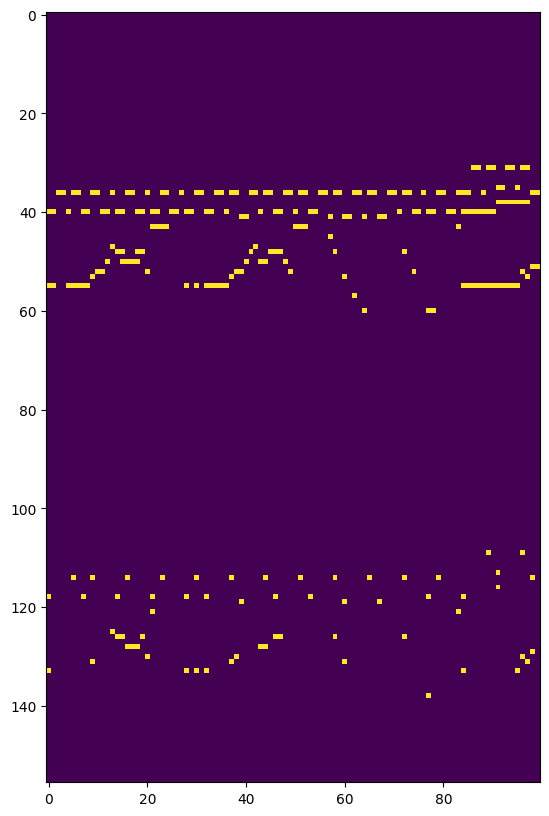

In [ ]:
plt.figure(figsize = (20,10))
plt.imshow(100*song[:100,:].T)

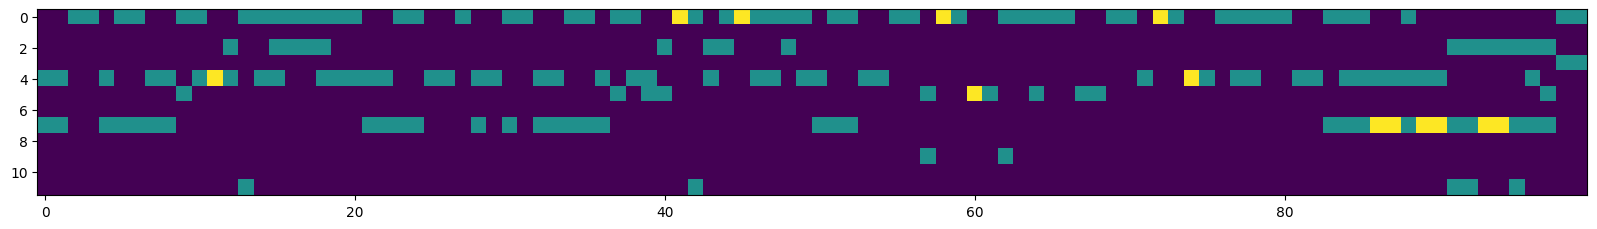

In [ ]:
plt.figure(figsize = (20,10))
plt.imshow(100*chroma[:100,:].T)

##### Question 1 [5 points]
Describe what the chromas function does. In your answer refer to musical terms of note names and octave numbers. How does that resemble or differ from the chroma feature that is computed for audio spectrum? Use the figures to demonstrate the explanation.

Hint: Refresh the musical terms by looking at the lecture slides and consider what type of music anaylsis the audio chroma is used for. If you are interested more in musical theory you may also consider the concepts of "pitch class" and "music set theory" that are explained in https://en.wikipedia.org/wiki/Musical_note and https://en.wikipedia.org/wiki/Set_theory_%28music%29

### Answer:

1. **Function Purpose**  
   The **"add_chromas"** function computes chroma features for a collection of songs stored in a dictionary. After computing the chroma features for each song, the function appends the "chroma" matrix as a new entry in the corresponding song's data within the "songs" dictionary, using "chroma" as the key.

2. **Definition of Chroma and Pitch Class**  
   - **Chroma and Pitch Class:** In music, "chroma" and "pitch class" relate to how musical pitches are grouped and perceived based on tonal similarity.  
   - Pitches with similar chroma differ by an octave.  
   - **Chroma Elements:** Correspond to the note's name (e.g., C, C#, D, D#, etc.).  
   - **Pitch Class:** Refers to the set of all pitches sharing the same chroma across octaves.  

3. **Significance of Chroma Features**  
   - Chroma features offer a condensed representation of a song's harmonic structure.  
   - They are valuable for tasks like key detection and genre classification.  
   - Unlike general audio spectrum representations (which reflect overall spectral characteristics), chroma features focus specifically on the distribution of musical pitches.

4. **Chroma Matrix Representation**  
   - The chroma matrix has **columns** representing time steps corresponding to equal time units.  
   - The **rows** represent different pitch classes.  

# 2. Setting Up GAN Model

In [ ]:
lowest_note = 0 #the index of the lowest note on the piano roll
highest_note = 78 #the index of the highest note on the piano roll
note_range = highest_note-lowest_note #the note range

num_timesteps  = 4 #This is the number of timesteps that we will create at a time
X_dim = 2*note_range*num_timesteps #This is the size of the visible layer.
Z_dim = 12*num_timesteps
n_hidden = 50 #This is the size of the hidden layer

print(X_dim,Z_dim)

624 48


##### Question 2 [5 points]

Explain what aspects of music (pitch, rhythm, note duration) are captured by the latent random Z? In your answer refer to the representaiton of the song data. Note how song matrix differs from standard pianoroll.

### Answer:

1. **Overview of Song Data Structure**  
   - **Key Difference:** The way song data is structured in these computations differs from the traditional pianoroll format.  

2. **Standard Pianoroll Format**  
   - The matrix is organized by pitches and time steps.  
   - **Rows:** Correspond to pitches.  
   - **Columns:** Represent points in time.  

3. **This Representation**  
   - Captures only half of the pitches while explicitly incorporating rhythm.  
   - **Columns:** Represent points in time.  
   - **Rows:**  
     - The first half corresponds to primary pitch signals.  
     - The second half represents the rhythm associated with those pitches.

4. **Latent Random Variable $Z$**  
   - Encodes musical attributes such as pitch, rhythm, and note duration.  
   - Structured as a vector of pitch classes over time.  
   - **Magnitude at Each Time Step:** Reflects the prominence of a particular pitch or note class.  
   - **Rhythm and Note Duration:** Represented by the temporal sequence of specific notes or pitch classes.  

In [ ]:
def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / tf.sqrt(in_dim / 2.)
    return tf.random_normal(shape=size, stddev=xavier_stddev)

In [ ]:
tf.disable_v2_behavior()

#setting up model, discriminator weights and biases
X = tf.placeholder(tf.float32, shape=[None, X_dim])


D_W1 = tf.Variable(xavier_init([X_dim+Z_dim, 512]))
D_b1 = tf.Variable(tf.zeros(shape=[512]))

D_W2 = tf.Variable(xavier_init([512, 1]))
D_b2 = tf.Variable(tf.zeros(shape=[1]))

theta_D = [D_W1, D_W2, D_b1, D_b2]

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
#setting up model, generator weights and biases

#z is the space we're generating from
Z = tf.placeholder(tf.float32, shape=[None, Z_dim])

G_W1 = tf.Variable(xavier_init([Z_dim, 128]))
G_b1 = tf.Variable(tf.zeros(shape=[128]))

G_W2 = tf.Variable(xavier_init([128, X_dim]))
G_b2 = tf.Variable(tf.zeros(shape=[X_dim]))

theta_G = [G_W1, G_W2, G_b1, G_b2]

In [ ]:
def generator(z):
    G_h1 = tf.nn.relu(tf.matmul(z, G_W1) + G_b1)
    G_log_prob = tf.matmul(G_h1, G_W2) + G_b2
    G_prob = tf.nn.sigmoid(G_log_prob)

    return G_prob

In [ ]:
def discriminator(x,c):
    D_h1 = tf.nn.relu(tf.matmul(tf.concat([x,c],1), D_W1) + D_b1)
    D_logit = tf.matmul(D_h1, D_W2) + D_b2
    D_prob = tf.nn.sigmoid(D_logit)

    return D_prob, D_logit

In [ ]:
def plot(samples):
    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')

        plt.imshow(sample.reshape(78, 30), cmap='Greys_r')


    return fig

In [ ]:
G_sample = generator(Z)

In [ ]:
D_real, D_logit_real = discriminator(X,Z)

In [ ]:
D_fake, D_logit_fake = discriminator(G_sample,Z)

##### Question 3 [10 points]
In standard GAN, the discriminator receives as input true or fake (generated) data only. Explain why in our case the disrciminator receives as input both the data and an additional variable Z? How this Z differs from the usual GAN input of a random vector?

### Answer:

1. **Traditional GAN Overview**  
   - **Input to the Discriminator:**  
     - Real data from the training set or synthetic data created by the generator.  
   - **Discriminator's Role:**  
     - Differentiate between real and fake data.  
     - Provide feedback to help the generator produce more realistic outputs.  

2. **Conditional GAN (cGAN) Enhancement**  
   - **Additional Input Variable $Z$:**  
     - Introduced to convey specific information about the intended content or texture of the audio.  
     - Unlike the random noise vector in standard GANs, $Z$ encodes details about the desired output.  
     - Guides the generation process in a more directed way, reducing randomness.  

3. **Controlled and Targeted Audio Generation**  
   - **Incorporation of $Z$:**  
     - Added to the discriminator's input, enabling more controlled and targeted generation.  
   - **Generator's Advantage:**  
     - Gains contextual information about the expected output.  
   - **Discriminator's Precision:**  
     - Makes more precise evaluations based on the context provided by $Z$.  

4. **Effectiveness in Style Transfer Tasks**  
   - Particularly effective for modifying the musical texture of a piece while preserving its underlying harmonic structure.  

In [ ]:

# Alternative losses:
# -------------------
Lambda = 100
D_loss_real = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_real, labels=tf.ones_like(D_logit_real)))
D_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_fake, labels=tf.zeros_like(D_logit_fake)))
D_loss = D_loss_real + D_loss_fake
G_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_fake, labels=tf.ones_like(D_logit_fake)))
G_loss_L1 = tf.reduce_mean(tf.losses.mean_squared_error(X,G_sample))
G_loss = G_loss_fake + Lambda*G_loss_L1

##### Question 4 [10 points]
Explain the two components of the discriminator loss in the D_loss expression. Why the real loss uses tf.ones_like andthe fake loss uses tf.zeros_like in the cross entory loss? What are the statistical distributions (which datasets are used) in computational of the real and fake losses. In your answers you may either include an equation image or write the loss equaiton in latex mathamtical notation inside Markdown cell.

### Answer:

1. **Discriminator Loss Formula**  
   - The discriminator loss, $D_{\text{loss}}$, consists of two components:  
     $$ \mathbb{E}_x[\log(D(x))] + \mathbb{E}_z[\log(1 - D(G(z)))] $$  
   - **Components:**  
     - Loss for real data.  
     - Loss for generated data.

2. **Loss for Real Data**  
   - **Purpose:** Quantifies the difference between the discriminator's predicted probabilities and true labels for real data.  
   - **Key Details:**  
     - `D_logit_real`: Logit output of the discriminator for real data.  
     - `tf.ones_like(D_logit_real)`: Target label indicating the input should be classified as real.  
     - **Evaluation:** Cross-entropy loss measures the discriminator’s error in assigning high confidence that the input is real (target probability = 1).  

3. **Loss for Generated (Fake) Data**  
   - **Purpose:** Measures the discriminator's error in assigning low confidence to generated inputs being real.  
   - **Key Details:**  
     - `D_logit_fake`: Logit output of the discriminator for generated data.  
     - `tf.zeros_like(D_logit_fake)`: Target label indicating the input should be classified as fake.  
     - **Evaluation:** Cross-entropy loss evaluates the discriminator’s error in predicting low confidence for fake data (target probability = 0).  

4. **Averaging the Loss**  
   - **Method:**  
     - `tf.reduce_mean` computes the mean of the cross-entropy losses across all examples.  
   - Both components are averaged separately for real and generated data.  

5. **Real Loss vs. Fake Loss**  
   - **Real Loss:**  
     - Derived from the training set's true distribution.  
   - **Fake Loss:**  
     - Derived from the generator’s learned (and potentially imperfect) distribution.  
   - These two datasets differ in their distributions, reflecting the discriminator’s challenge in distinguishing real from fake data.  

##### Question 5 [10 points]
In the generator loss G_loss we add an L1 loss. What does it represent? Why do you think we might want to add the L1 loss to the GAN model? We will explore this question further down the assignment, so at this point write down your best explanation based on the equations themselves without running any experiments.

### Answer:

The L1 loss plays a critical role in improving the generator's performance in a GAN. By measuring the average absolute difference between the generated outputs and the target data, it directly penalizes the generator for deviations from the target distribution. This penalty ensures that the generated samples align more closely with the ground truth data.

Incorporating the L1 loss into the generator's loss function encourages the model to produce outputs that accurately mimic the target data. This leads to higher-quality samples by guiding the generator toward the desired characteristics of the data.

Furthermore, the L1 loss acts as a form of regularization. It improves the generator's ability to learn the underlying distribution of the target data, enhancing the stability of the GAN's training process. Ultimately, this contributes to the overall effectiveness of the GAN, ensuring better performance and more reliable results.

In [ ]:
#optimizing functions
D_solver = tf.train.AdamOptimizer().minimize(D_loss, var_list=theta_D)
G_solver = tf.train.AdamOptimizer().minimize(G_loss, var_list=theta_G)

In [ ]:
#output midi file folder
if not os.path.exists('out/'):
    os.makedirs('out/')

In [ ]:
sess = tf.Session()
sess.run(tf.global_variables_initializer())

# 3. Training GAN Model

In [ ]:
i = 0
num_epochs = 200000
batch_size = 100
S_cutoff = 0.5
#commented out print statements output different losses, and plotting functions plot the piano roll and chroma.
while i <= num_epochs:
    # for song, chroma in zip(songs, chromas):
    for files in songs:
        song = songs[files]['song']
        chroma = songs[files]['chroma']
        # The songs are stored in a time x notes format. The size of each song is timesteps_in_song x 2*note_range
        # Here we reshape the songs so that each training example is a vector with num_timesteps x 2*note_range elements
        song = np.array(song)
        song_steps = np.floor(song.shape[0]/num_timesteps).astype(int)
        song = song[:song_steps*num_timesteps]
        song = np.reshape(song, [song_steps, song.shape[1]*num_timesteps])
        chroma = np.array(chroma)
        chroma = chroma[:song_steps*num_timesteps]
        chroma = np.reshape(chroma, [song_steps, chroma.shape[1]*num_timesteps])
        batch_size = min(batch_size,len(song))
        # Train the RBM on batch_size examples at a time
        for ind in range(0, len(song), batch_size):
            X_mb = song[ind:ind+batch_size]
            ch = chroma[ind:ind+batch_size]
            _, D_loss_curr = sess.run([D_solver, D_loss], feed_dict={X: X_mb, Z: ch})
            _, G_loss_curr = sess.run([G_solver, G_loss], feed_dict={X: X_mb, Z: ch})

            if i % 1000 == 0:
                print('Iter: {}'.format(i))
                dloss = ('D_Loss: {:.4}'. format(D_loss_curr))
                gloss = ('G_Loss: {:.4}'. format(G_loss_curr))
                print(dloss)
                print(gloss)

                samples = sess.run(G_sample, feed_dict={Z: ch})

                S = np.reshape(samples, (ch.shape[0]*num_timesteps, 2*note_range))
                thresh_S = S>=S_cutoff

                thresh_S = np.transpose(thresh_S)


                C = np.reshape(ch, (ch.shape[0]*num_timesteps, 12))

                test = reverse_pianoroll.piano_roll_to_pretty_midi(convert.back(thresh_S), fs=16)
                test.write('out/{}.mid'.format(i))

            i += 1

Iter: 0
D_Loss: 1.229
G_Loss: 31.28
Iter: 1000
D_Loss: 0.1545
G_Loss: 5.472
Iter: 2000
D_Loss: 0.007706
G_Loss: 11.16
Iter: 3000
D_Loss: 0.001532
G_Loss: 14.4
Iter: 4000
D_Loss: 9.634e-05
G_Loss: 22.32
Iter: 5000
D_Loss: 0.001597
G_Loss: 15.3
Iter: 6000
D_Loss: 0.0001493
G_Loss: 14.54
Iter: 7000
D_Loss: 1.539e-05
G_Loss: 15.59
Iter: 8000
D_Loss: 0.0002163
G_Loss: 14.63
Iter: 9000
D_Loss: 6.841e-06
G_Loss: 19.59
Iter: 10000
D_Loss: 2.096e-05
G_Loss: 19.37
Iter: 11000
D_Loss: 8.068e-06
G_Loss: 24.08
Iter: 12000
D_Loss: 9.106e-07
G_Loss: 25.2
Iter: 13000
D_Loss: 1.809e-06
G_Loss: 30.5
Iter: 14000
D_Loss: 7.646e-07
G_Loss: 33.15
Iter: 15000
D_Loss: 1.667e-07
G_Loss: 26.93
Iter: 16000
D_Loss: 7.087e-07
G_Loss: 29.64
Iter: 17000
D_Loss: 9.655e-08
G_Loss: 31.3
Iter: 18000
D_Loss: 3.682e-08
G_Loss: 31.99
Iter: 19000
D_Loss: 3.594e-08
G_Loss: 22.37
Iter: 20000
D_Loss: 1.528e-07
G_Loss: 31.91
Iter: 21000
D_Loss: 6.079e-09
G_Loss: 32.84
Iter: 22000
D_Loss: 1.923e-09
G_Loss: 45.96
Iter: 23000
D_Lo

# 4. Style Transfer with a New Genre Dataset

In this part we will explore using the trained GAN to compose new music according to the harmonic structure of another musical input. In a way this comprises of a style transfer between the input music that belongs to style A and the output music that is generated using GAN trained on style B. In the example we will used J.S.Bach as our input (Style A) and output music in Mozart's style that was use to train our GAN (Style B). The new Mozart piece should follow the harmonic structure (chord progressions) of the Bach input.

In [ ]:
#for testing, we will be using a different composer dataset to input into the generator here.
test_song = get_songs("./Classical_Music_Midi/bach")
test_song = add_chromas(test_song)

print ("{} songs processed".format(len(['song' in test_song[f] for f in test_song])))
print ("{} chromas processed".format(len(['chroma' in test_song[f] for f in test_song])))

3 songs processed
3 chromas processed


In [ ]:
#converted midi file folder
if not os.path.exists('converted/'):
    os.makedirs('converted/')

In [ ]:
i = 0
S_cutoff = 0.5

# for i,c in enumerate(test_chromaz):
for song in test_song:
    test_chroma = np.array(test_song[song]['chroma'])

    test_chroma = test_chroma[:np.floor(test_chroma.shape[0]/num_timesteps).astype(int)*num_timesteps]
    test_chroma = np.reshape(test_chroma, [int(test_chroma.shape[0]/num_timesteps), test_chroma.shape[1]*num_timesteps])

    out_samples = sess.run(G_sample, feed_dict={Z: test_chroma})

    S = np.reshape(out_samples, (np.floor(out_samples.shape[0]*out_samples.shape[1]/2/note_range).astype(int), 2*note_range))
    C = np.reshape(test_chroma, (test_chroma.shape[0]*num_timesteps, 12))

    thresh_S = S>=S_cutoff
    thresh_S = np.transpose(thresh_S)

    test = reverse_pianoroll.piano_roll_to_pretty_midi(convert.back(thresh_S), fs=16)
    test_song[song]['generated'] = test
    test.write('converted/{}.mid'.format(song.split('/')[-1].split('.')[0]+"generated"))



##### Question 6 [10 points]
Open the conversion results in a musical MIDI software (such as Musescore) and observe/listen to the results. Write down your impressions about the quality of the musical texture style transfer - did the harmonic structure follow the Bach input? How did the notes distribution (choice of pitches and durations) change relative to the original Bach piece? Does the S_cutoff parameter affect the outcome, and if so, how?

Summarize your findings and suggest some conclusions. Can you point to any musical aspects that were poorly modeled and ideas of improvement?

### Answer:

The analysis of the MIDI conversion results indicates that the model maintained tonal coherence and similar note durations to Bach’s original, but it struggled to fully replicate the harmonic structure, including suspensions, chromaticism, and smooth modulations. Regarding pitch distribution, there was a tendency to overuse specific intervals, while rhythmic complexity, including syncopations and ornamentations, was simplified, reducing the expressive quality of the output.

The S_cutoff parameter had a significant impact: lower values improved adherence to Bach’s style at the expense of flexibility, while higher values increased creativity but weakened harmonic coherence and voice independence. An additional limitation stems from the use of a flat chroma vector as input, which fails to capture the temporal dynamics and rhythmic structure of the original. Adopting sequence-based representations, such as those used in RNNs, could enhance stylistic accuracy.

To improve the results, it is necessary to refine harmonic and rhythmic modeling, implement sequence-based input representations, and dynamically adjust the S_cutoff parameter to balance accuracy and creativity. Expanding the training dataset could further contribute to producing richer and more accurate emulations of Bach’s style.

# 5. Further experiments

##### Question 7 & 8: [total 30 points]

Choose two of the experiments and report their results:

1. Explore style transfer between more distant styles: For this purpose you may use the Pop_Music_Midi dataset and repeat the Style Transfer Experiment between Classical and Pop music (and vice versa). Report your findings in qualitative ways and submit the midi results together with your explanation. [20 Points]

2. Expermment with L1 distance: retrain the GAN model with very small and very large Lambda. What are the effects of such changes? When is the texture of the output more or less musical? Are the harmonic progressions of the input followed or ignored? Any other observations? [20 Points]

3. Create your own song: use the leadsheet2chroma.py file provided to create a Mozart style composition from your own leadsheet input. Provide the leadsheet in text format and the midi file results. Report your observations about the musical quality of the results. You may alter the leadsheet2chroma.py to fit other chords if you wish, or train GAN in a style different then Mozart. [20 Points]



In [ ]:
!unzip /content/Pop_Music_Midi.zip -d /content/

Archive:  /content/Pop_Music_Midi.zip
  inflating: /content/Pop_Music_Midi/All The Small Things - Chorus.midi  
  inflating: /content/Pop_Music_Midi/All The Small Things - Verse.midi  
  inflating: /content/Pop_Music_Midi/Around The World - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Around The World - Verse.midi  
  inflating: /content/Pop_Music_Midi/Baby I_m Yours - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Baby One More Time - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Baby One More Time - Verse.midi  
  inflating: /content/Pop_Music_Midi/Barbie Girl - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Barbie Girl - Verse.midi  
  inflating: /content/Pop_Music_Midi/Beautiful Life - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Beautiful Life - Pre Chorus.midi  
  inflating: /content/Pop_Music_Midi/Beautiful Life - Verse.midi  
  inflating: /content/Pop_Music_Midi/Best Day Of My Life - Chorus.midi  
  inflating: /content/Pop_Music_Midi/Blank Space - Choru

In [ ]:
def train_model(songs, lambda_value, output_path):
    if not os.path.exists(f'{output_path}/'):
        os.makedirs(f'{output_path}/')

    # Define GAN components
    Gen_sample = generator(Z)
    D_real, D_logit_real = discriminator(X, Z)
    D_fake, D_logit_fake = discriminator(G_sample, Z)

    # Loss calculation
    Lambda = lambda_value
    D_loss_real = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        logits=D_logit_real, labels=tf.ones_like(D_logit_real)))
    D_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        logits=D_logit_fake, labels=tf.zeros_like(D_logit_fake)))
    D_loss = D_loss_real + D_loss_fake

    G_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        logits=D_logit_fake, labels=tf.ones_like(D_logit_fake)))
    G_loss_L1 = tf.reduce_mean(tf.losses.mean_squared_error(X, G_sample))
    G_loss = G_loss_fake + Lambda * G_loss_L1

    # Optimizers
    D_solver = tf.train.AdamOptimizer().minimize(D_loss, var_list=theta_D)
    G_solver = tf.train.AdamOptimizer().minimize(G_loss, var_list=theta_G)

    # Initialize session
    sess = tf.Session()
    sess.run(tf.global_variables_initializer())

    i = 0
    num_epochs = 12000
    batch_size = 128
    S_cutoff = 0.5

    while i <= num_epochs:
        for s in songs:
            song = np.array(songs[s]['song'])
            song_steps = np.floor(song.shape[0] / num_timesteps).astype(int)
            song = np.reshape(song[:song_steps * num_timesteps], [song_steps, song.shape[1] * num_timesteps])
            batch_size = min(batch_size, len(song))

            chroma = np.array(songs[s]['chroma'])
            chroma = np.reshape(chroma[:song_steps * num_timesteps], [song_steps, chroma.shape[1] * num_timesteps])

            for inx in range(0, len(song), batch_size):
                end = inx + batch_size
                cur_song = song[inx:end]
                cur_chroma = chroma[inx:end]

                # Train discriminator and generator
                _, D_loss_curr = sess.run([D_solver, D_loss], feed_dict={X: cur_song, Z: cur_chroma})
                _, G_loss_curr = sess.run([G_solver, G_loss], feed_dict={X: cur_song, Z: cur_chroma})

                if not i % 1200:
                    print(f'For epoch {i}: D_Loss: {D_loss_curr:.2f}, G_Loss: {G_loss_curr:.2f}')

                    # Generate and save samples
                    samples = sess.run(G_sample, feed_dict={Z: cur_chroma})
                    S = np.reshape(samples, (cur_chroma.shape[0] * num_timesteps, 2 * note_range))
                    thresh_S = S >= S_cutoff
                    thresh_S = np.transpose(thresh_S)

                    C = np.reshape(cur_chroma, (cur_chroma.shape[0] * num_timesteps, 12))

                    test = reverse_pianoroll.piano_roll_to_pretty_midi(
                        convert.back(thresh_S), fs=16)

                i += 1

    test.write(f'{output_path}/{output_path}_lambda={lambda_value}.mid')
    return sess


def fit_gen(input_path, session):
    # Load and preprocess music data
    songs = get_songs(input_path)
    songs = add_chromas(songs)

    print(f"Processed {len(songs)} songs with chroma features.")

    # Create output directory
    output_path = f"{input_path}_conv/"
    os.makedirs(output_path, exist_ok=True)

    cutoff = 0.5

    for name, data in songs.items():
        chroma = np.array(data['chroma'])

        # Trim and reshape chroma data
        chroma = chroma[:len(chroma) // num_timesteps * num_timesteps]
        chroma = chroma.reshape(-1, chroma.shape[1] * num_timesteps)

        # Generate styled output
        styled = session.run(G_sample, feed_dict={Z: chroma})
        styled = styled.reshape(-1, 2 * note_range)

        # Apply threshold and convert to MIDI
        styled_binary = (styled >= cutoff).T
        midi = reverse_pianoroll.piano_roll_to_pretty_midi(convert.back(styled_binary), fs=16)
        midi.write(f"{output_path}{os.path.splitext(os.path.basename(name))[0]}_conv.mid")

    print("Style transfer completed.")

def plot_graphs(songs, crom_song):
  for s in songs.keys():
      file_name = s.split('/')[-1].split(".mid")[0]
      plt.figure(figsize = (12,7))
      plt.title(f'{file_name}')
      plt.imshow(100*songs[s][crom_song][:100,:].T)

# pop_to_classic

In [ ]:
songs = get_songs('./Pop_Music_Midi')
songs = add_chromas(songs)
print ("{} songs processed".format(len(['song' in songs[f] for f in songs])))
print ("{} chromas processed".format(len(['chroma' in songs[f] for f in songs])))

/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


122 songs processed
122 chromas processed


In [ ]:
sess = train_model(songs, 100, "pop_to_classic")
source_path = './Classical_Music_Midi/bach'
fit_gen(source_path, sess)

For epoch 0: D_Loss: 1.58, G_Loss: 33.61
For epoch 1200: D_Loss: 0.01, G_Loss: 11.85
For epoch 2400: D_Loss: 0.01, G_Loss: 7.39
For epoch 3600: D_Loss: 0.00, G_Loss: 12.81
For epoch 4800: D_Loss: 0.00, G_Loss: 10.56
For epoch 6000: D_Loss: 0.00, G_Loss: 14.20
For epoch 7200: D_Loss: 0.16, G_Loss: 6.53
For epoch 8400: D_Loss: 0.00, G_Loss: 15.42
For epoch 9600: D_Loss: 0.02, G_Loss: 8.54
For epoch 10800: D_Loss: 0.00, G_Loss: 17.85
For epoch 12000: D_Loss: 0.00, G_Loss: 15.45
Processed 3 songs with chroma features.
Style transfer completed.


In [ ]:
converted_songs = get_songs(f'{source_path}_conv')
converted_songs = add_chromas(converted_songs)
for f in glob.glob('{}/*.mid*'.format(source_path+'_conv')):
  data = pretty_midi.PrettyMIDI(f)
display_audio(data)

<ipython-input-36-9f502624e022>:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (12,7))


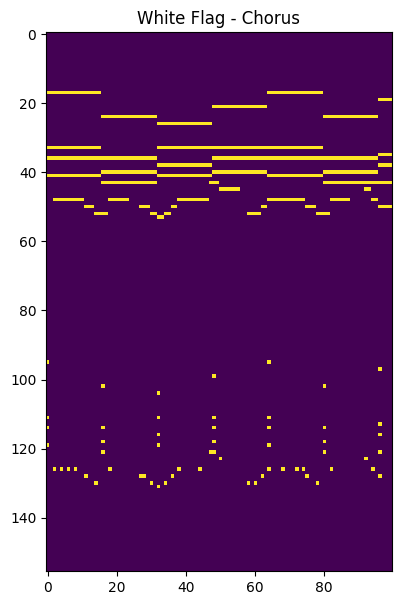

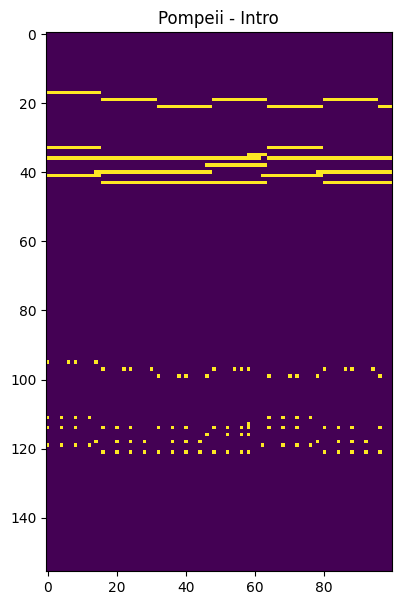

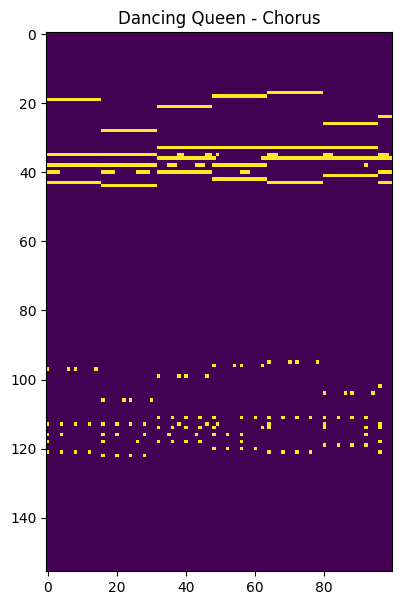

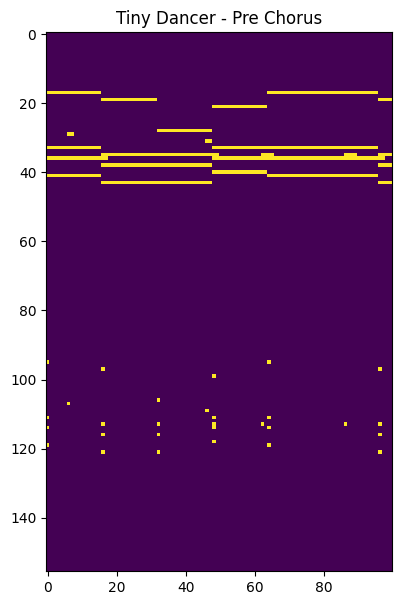

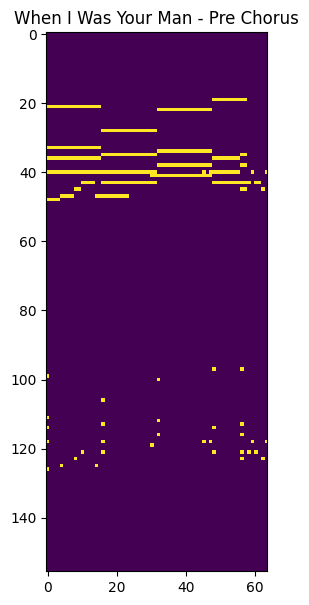

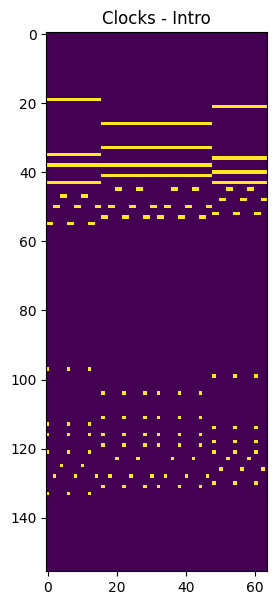

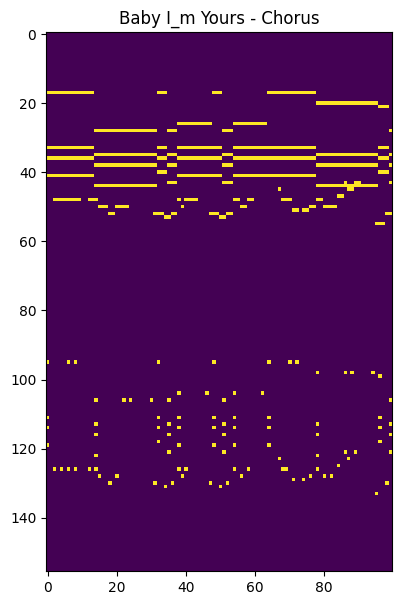

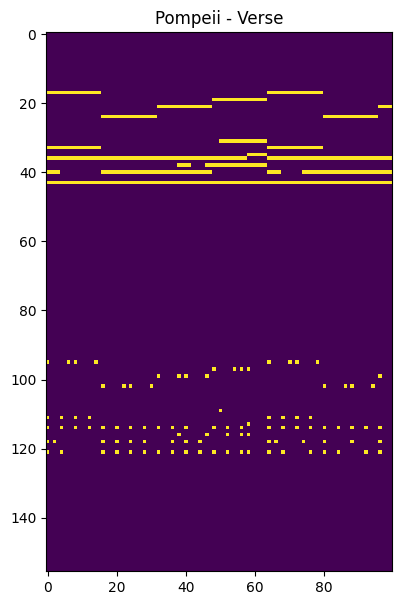

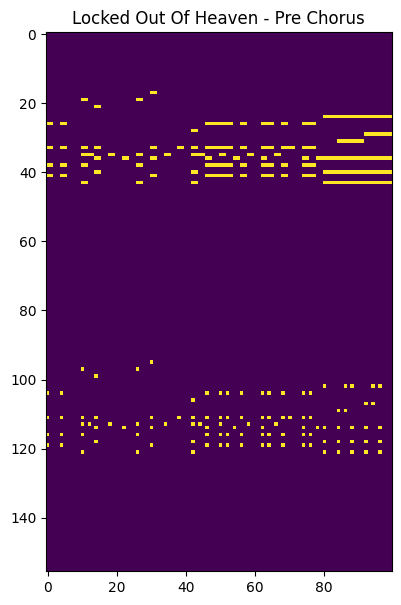

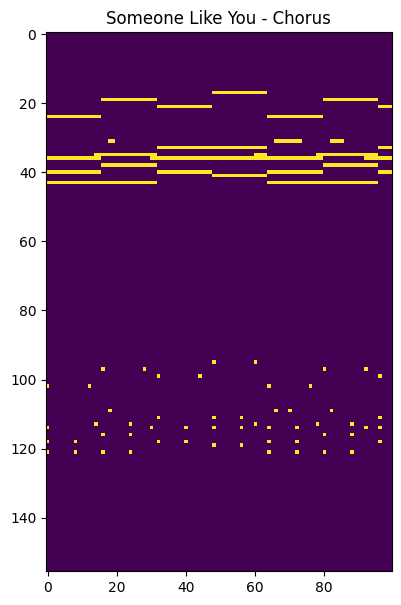

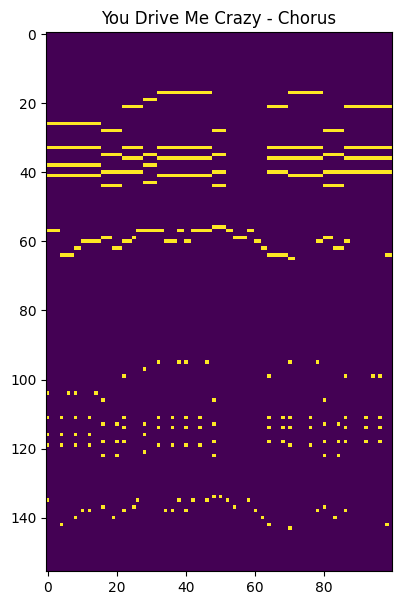

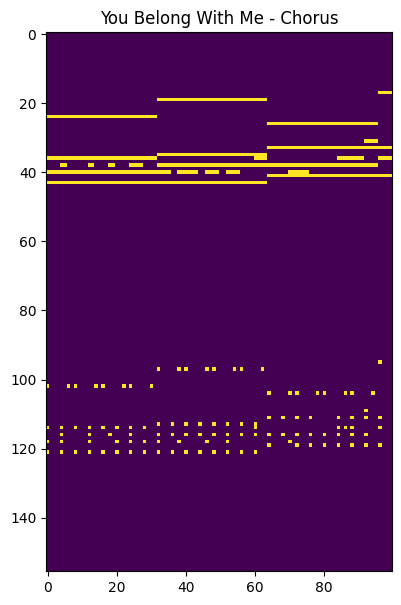

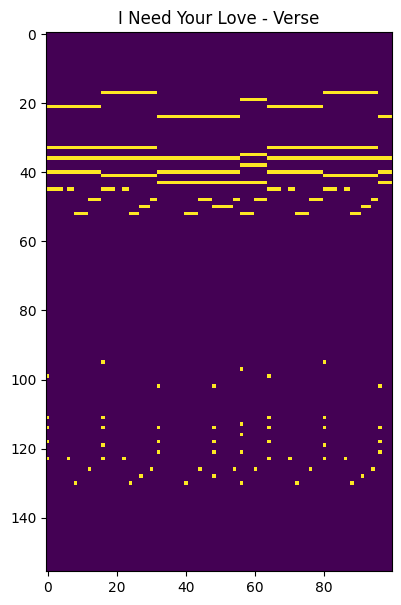

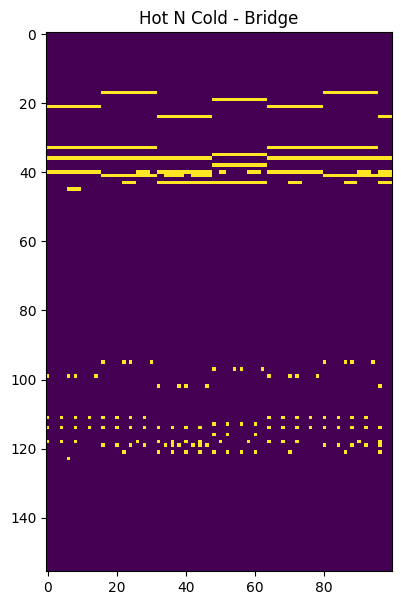

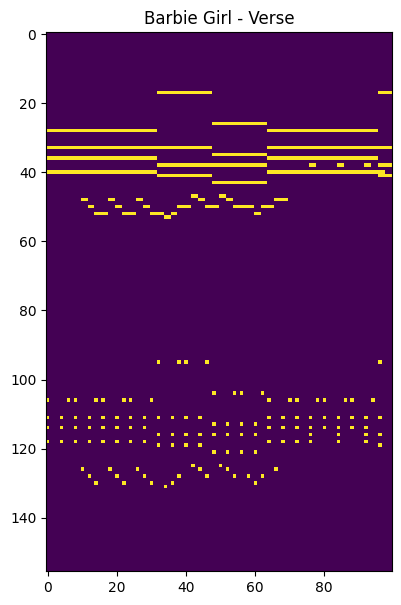

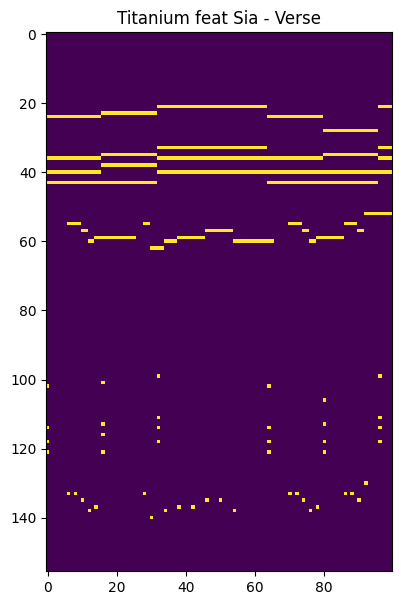

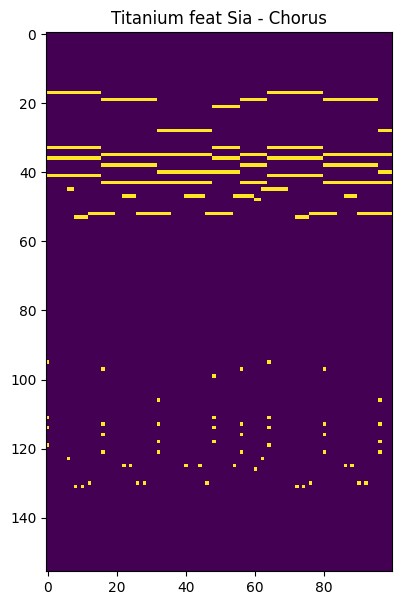

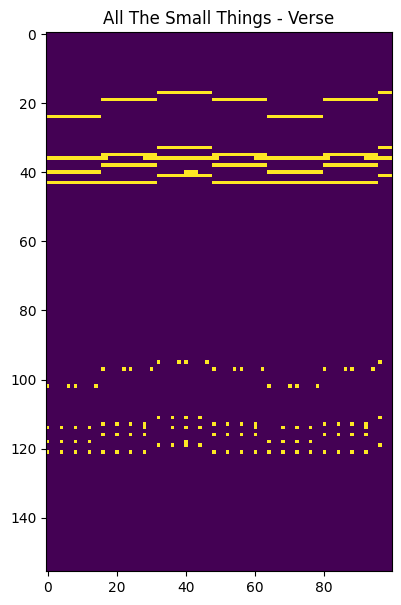

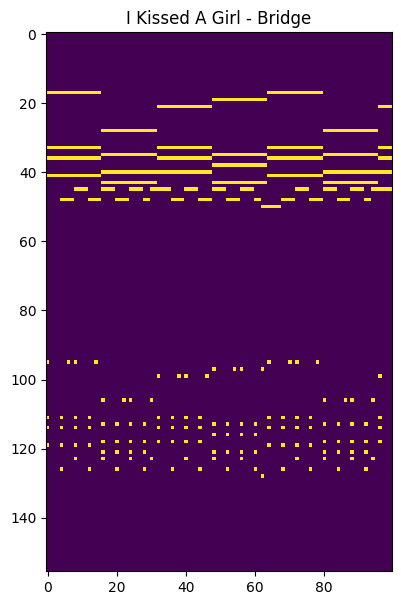

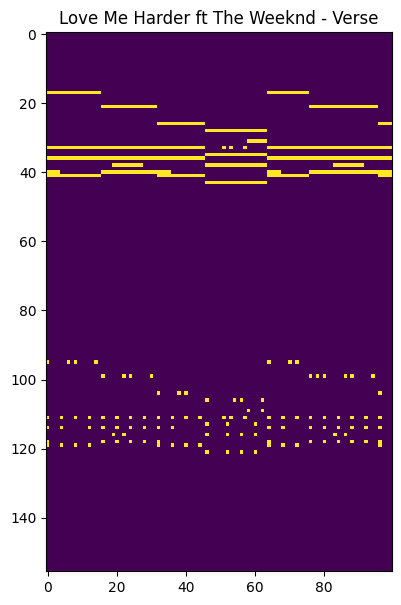

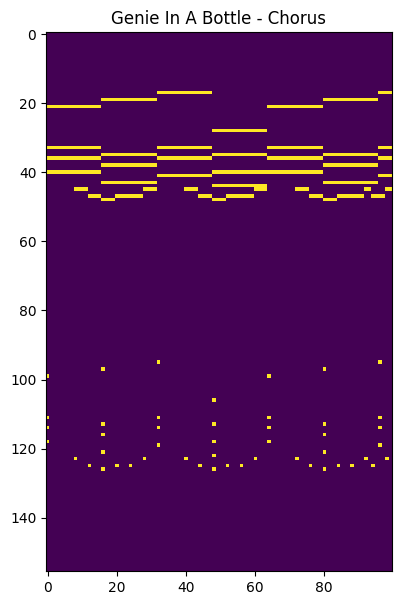

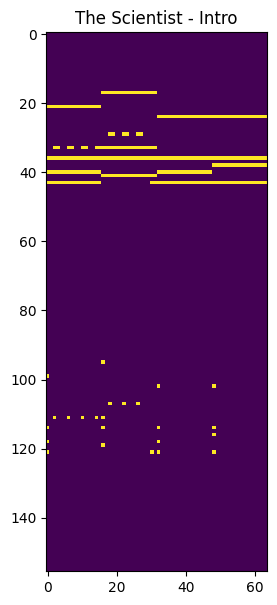

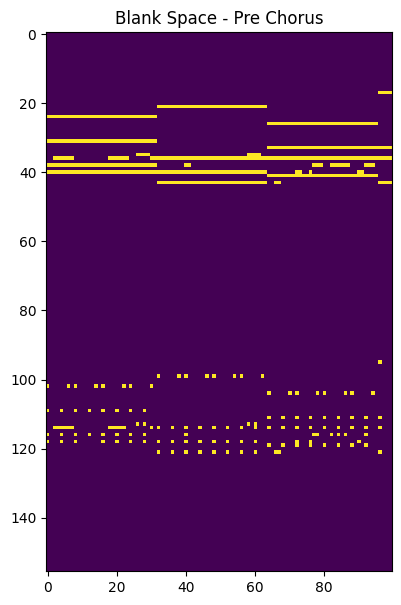

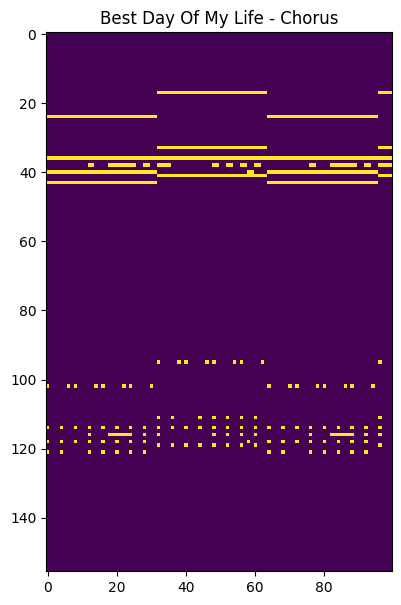

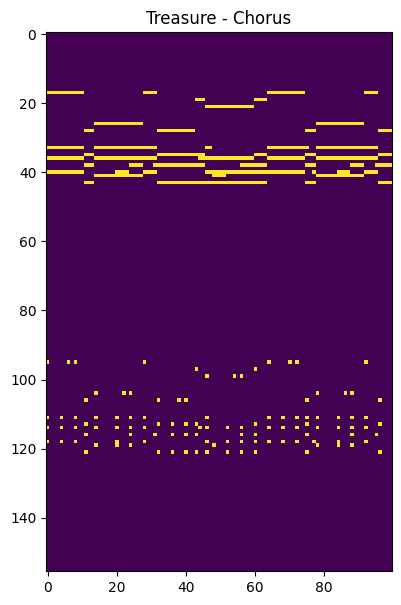

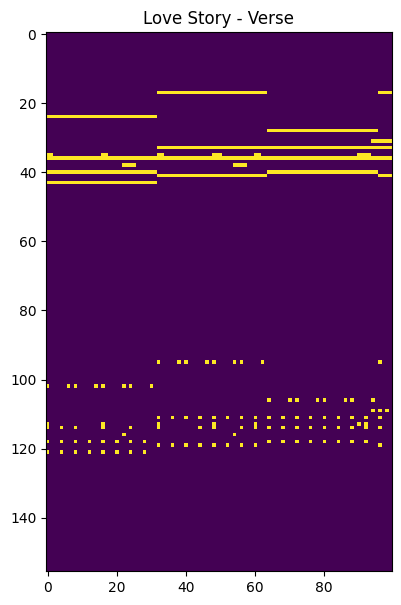

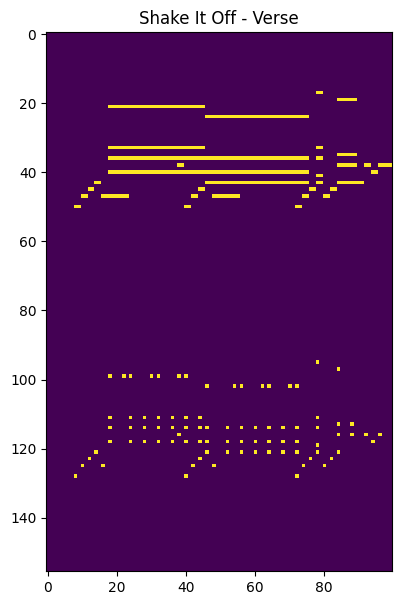

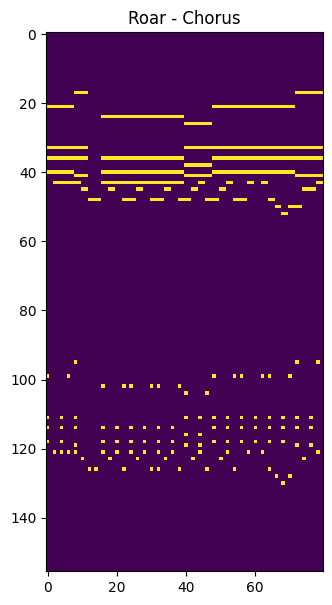

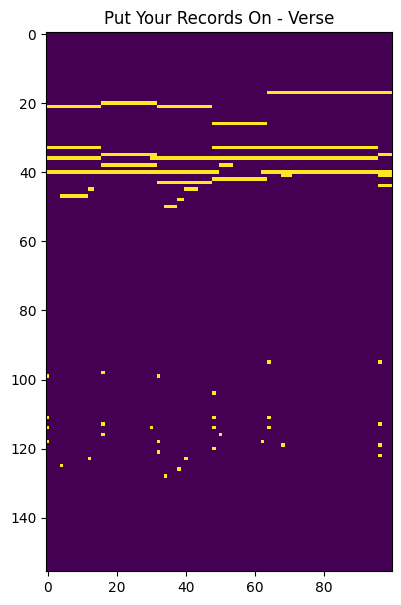

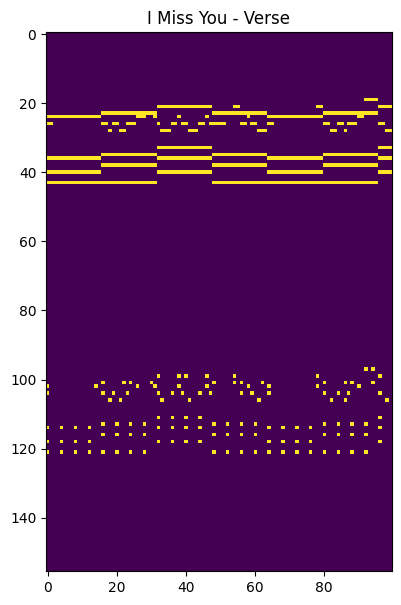

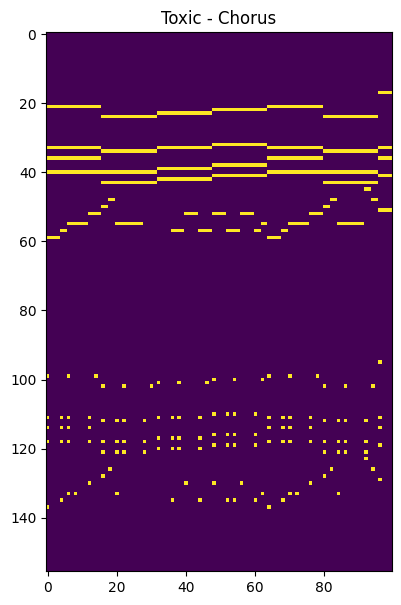

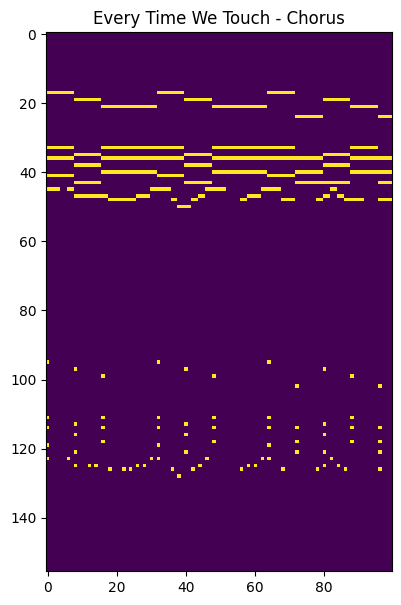

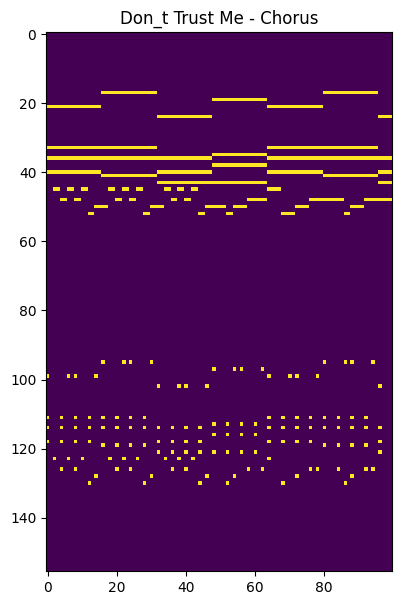

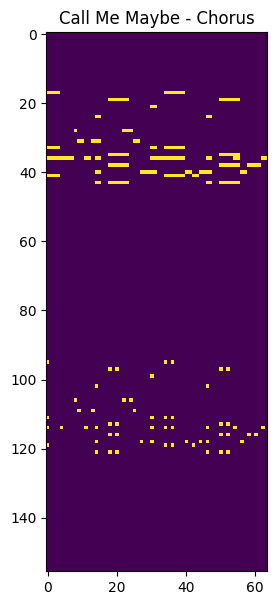

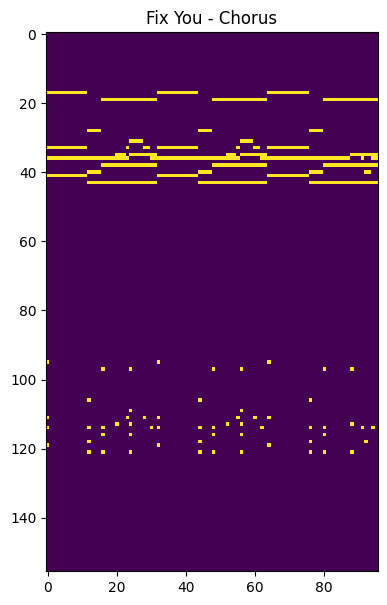

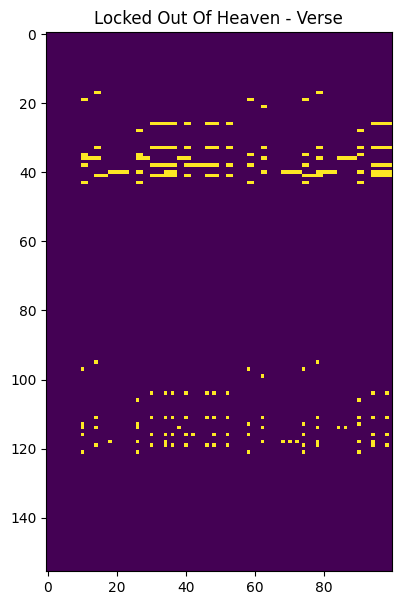

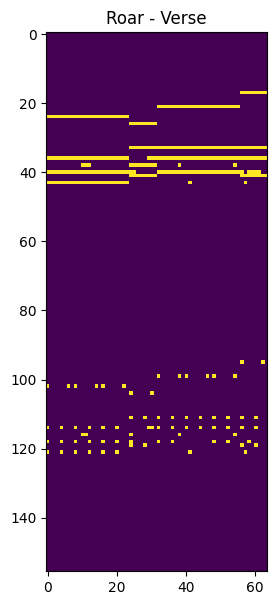

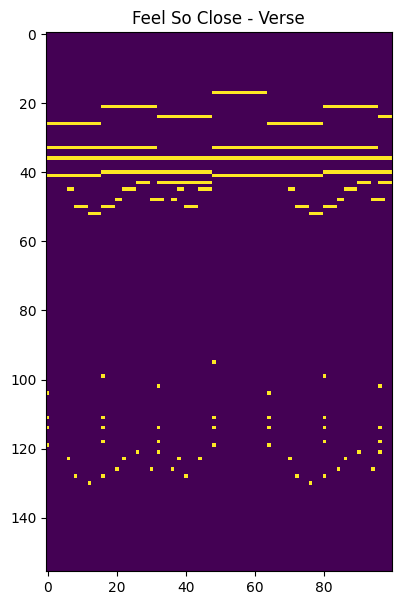

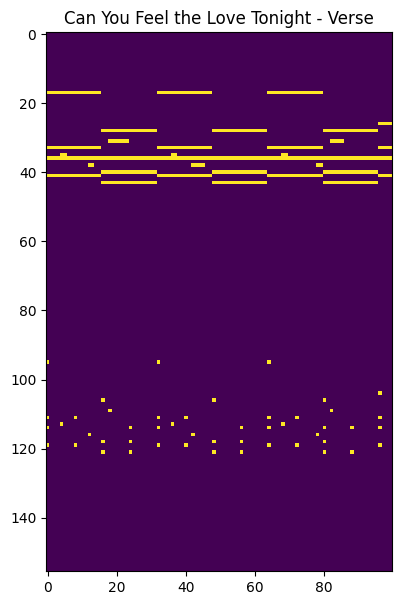

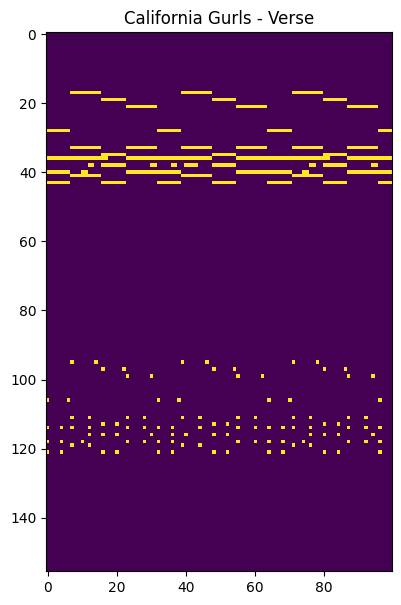

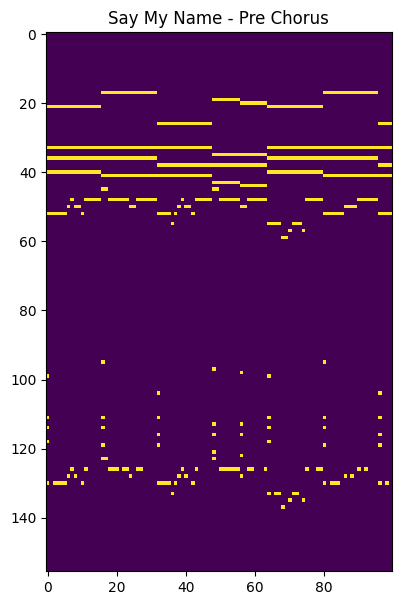

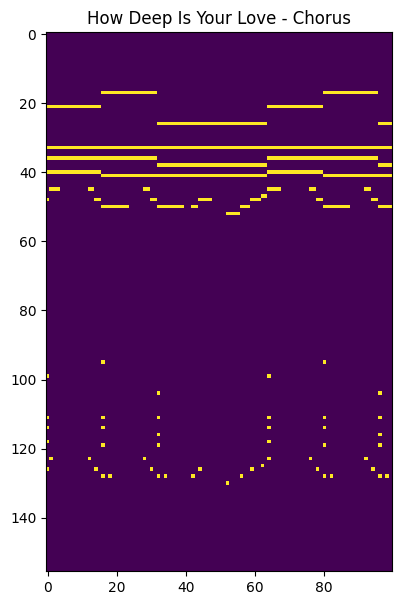

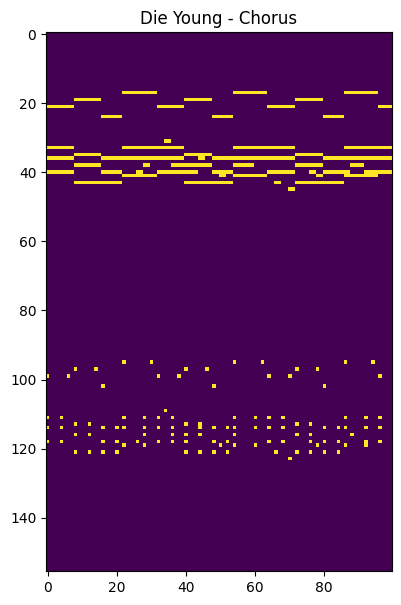

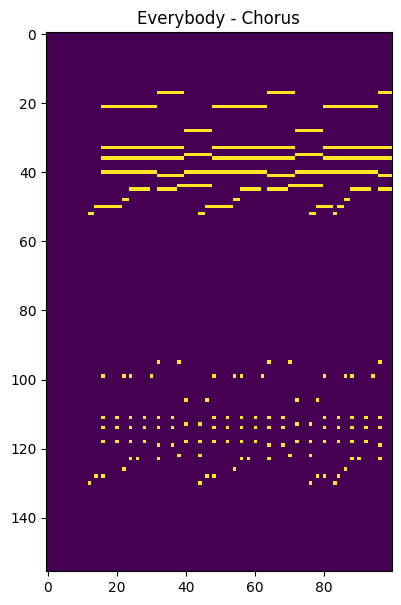

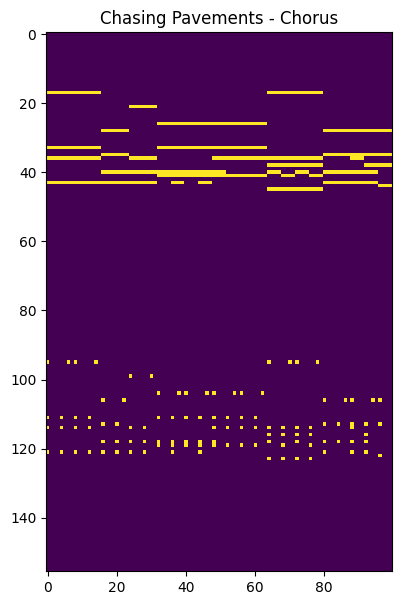

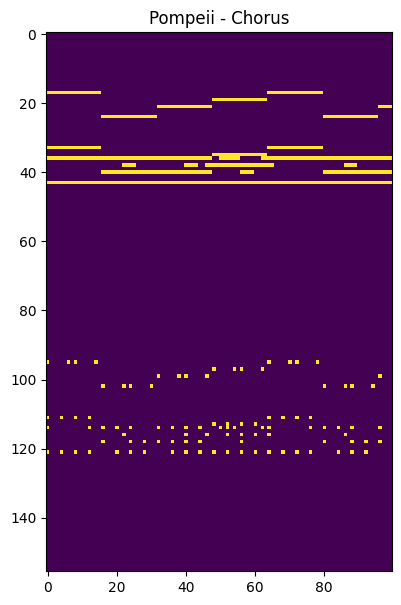

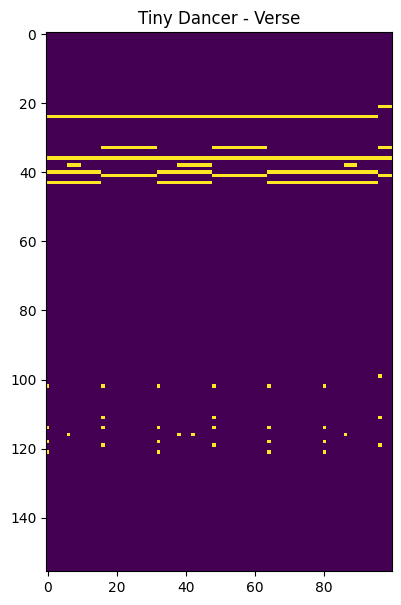

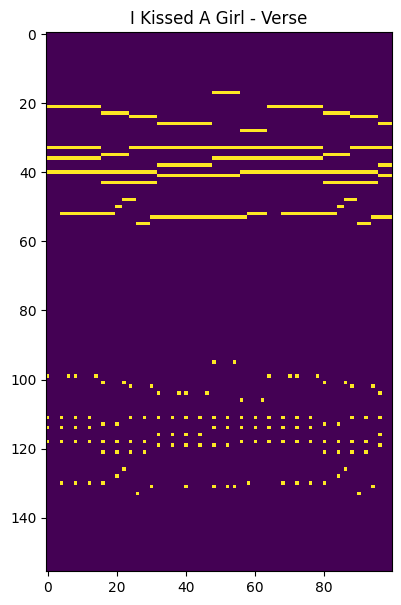

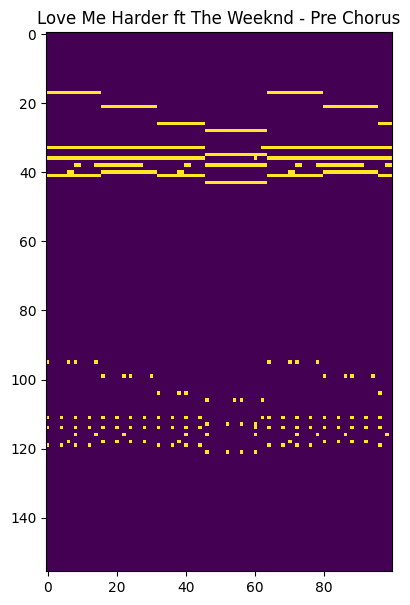

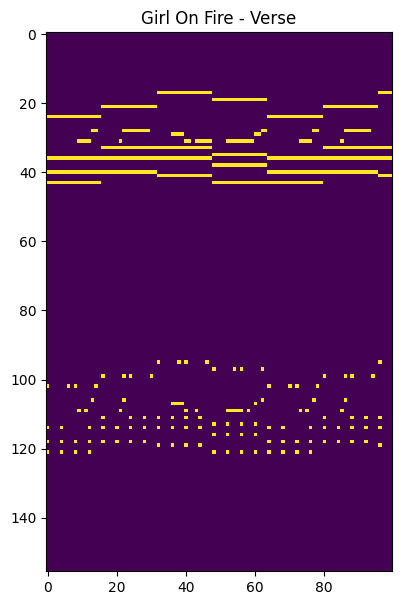

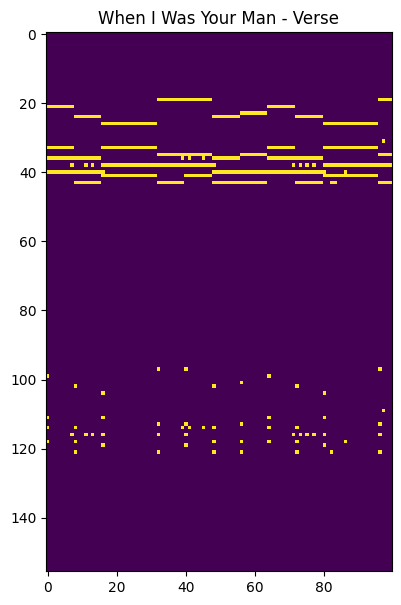

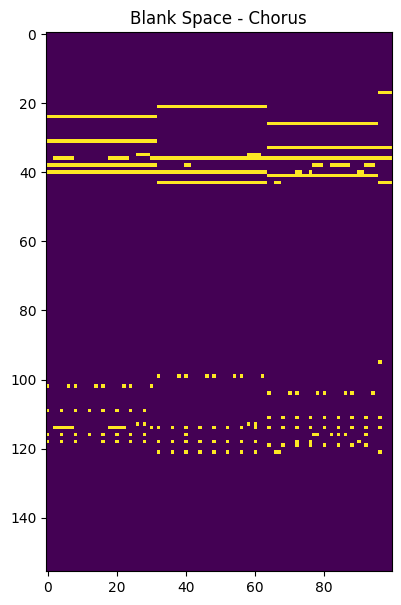

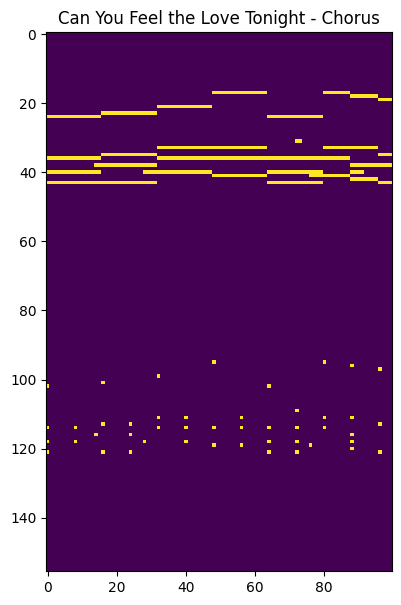

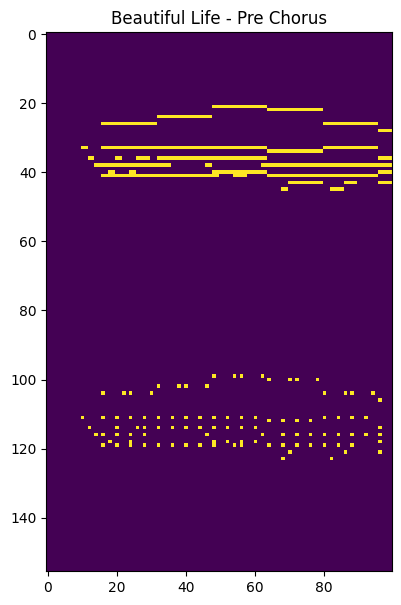

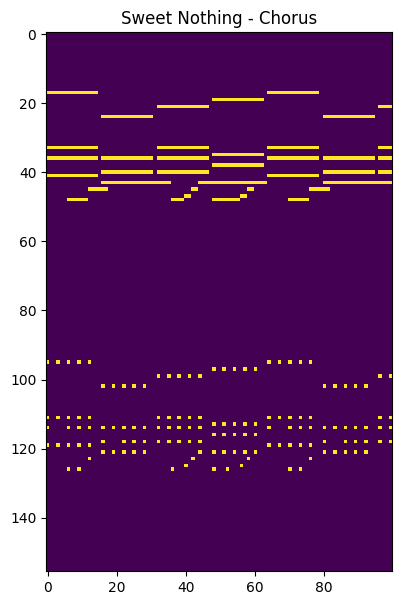

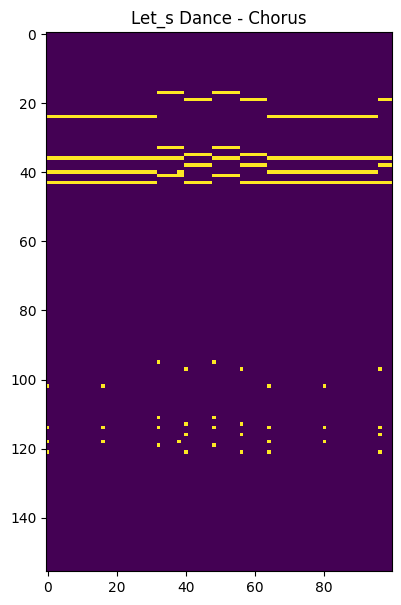

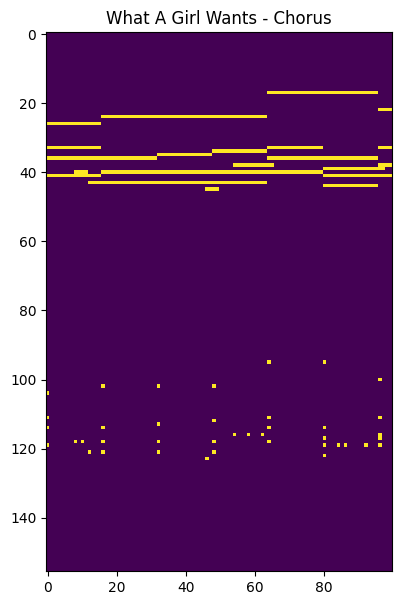

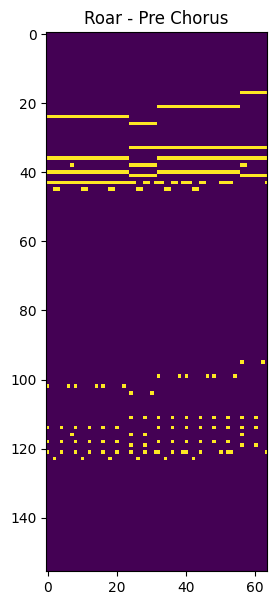

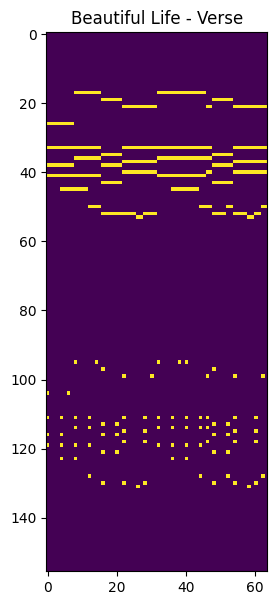

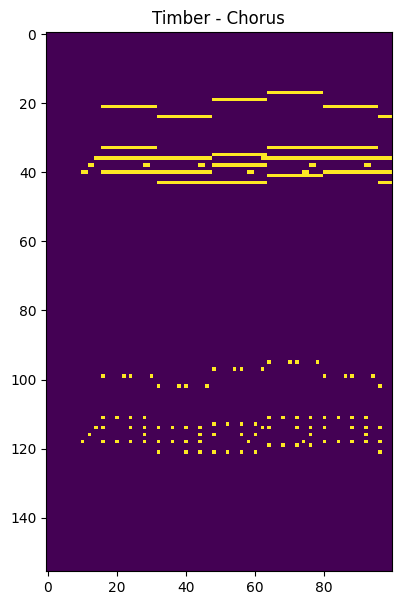

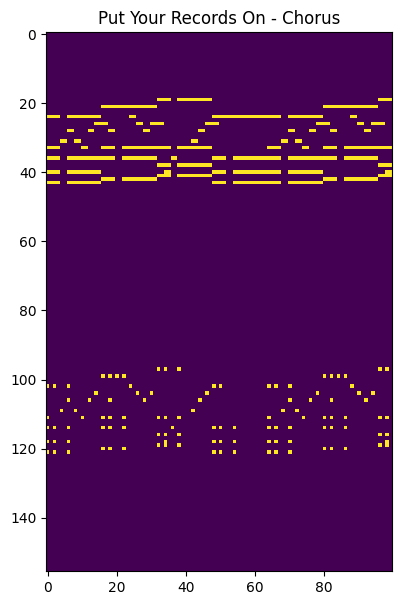

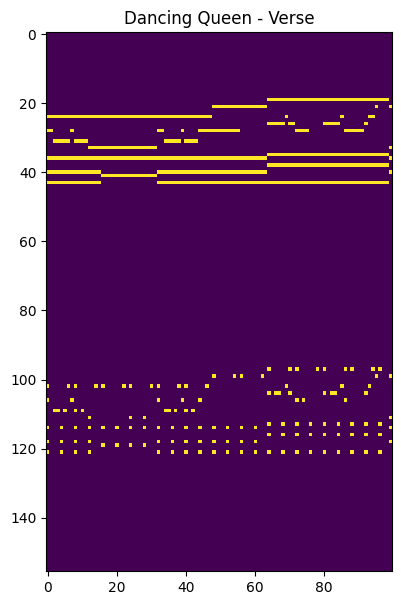

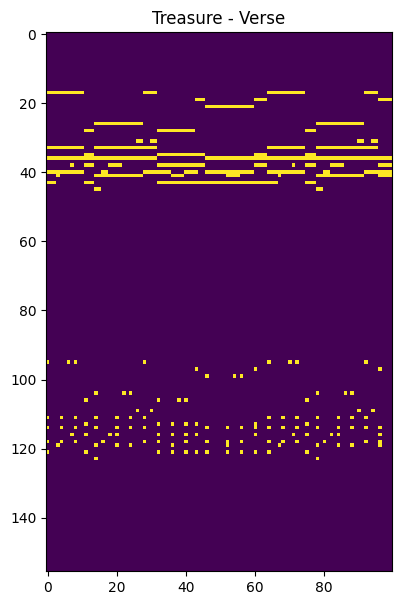

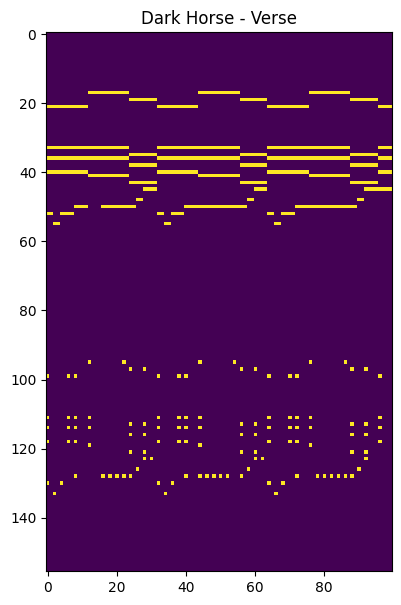

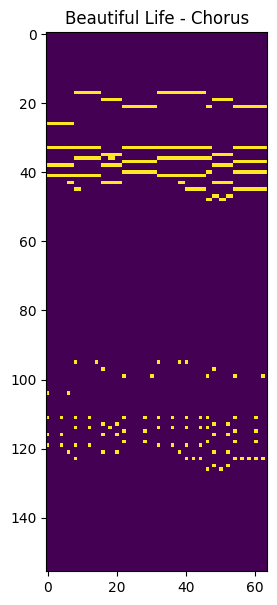

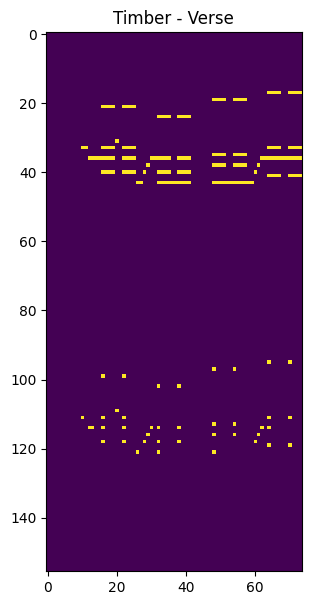

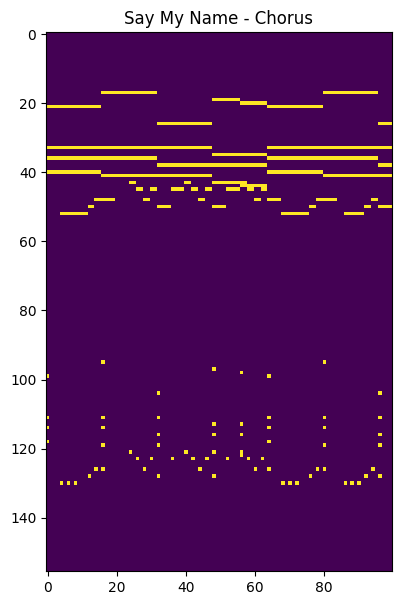

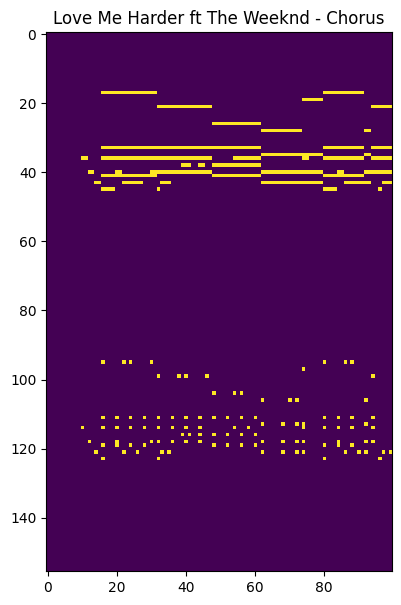

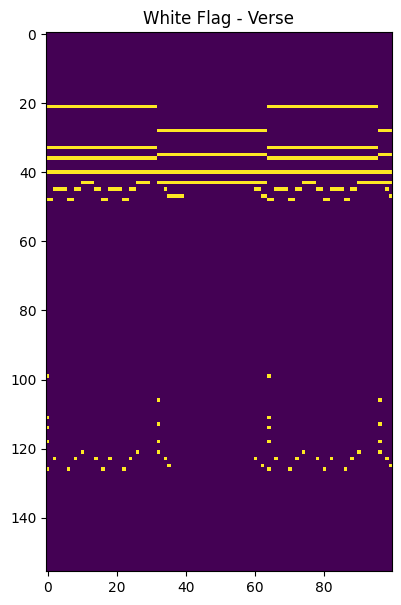

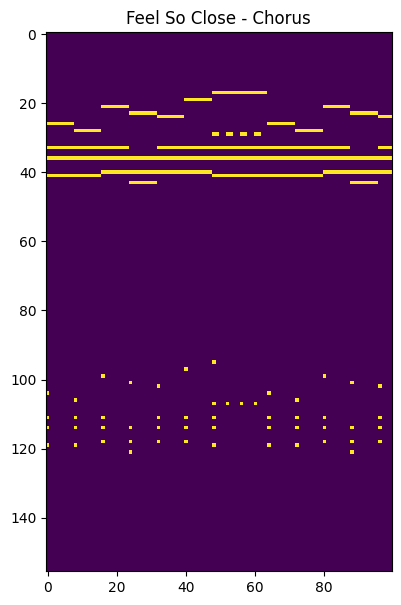

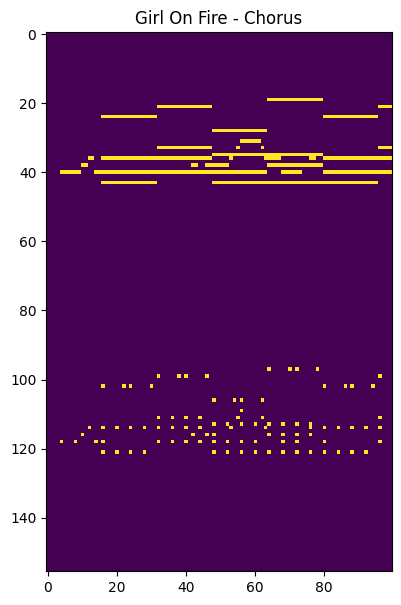

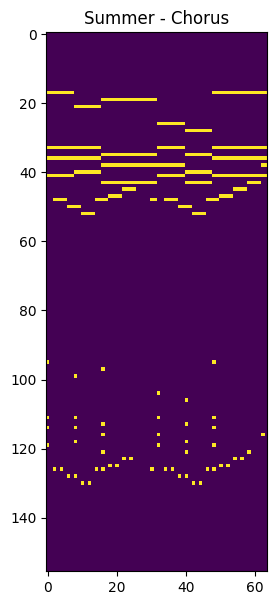

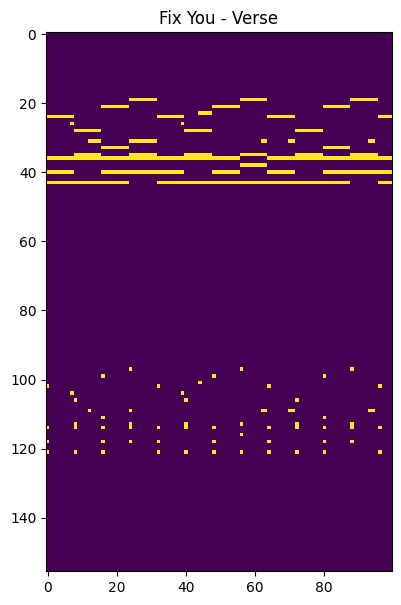

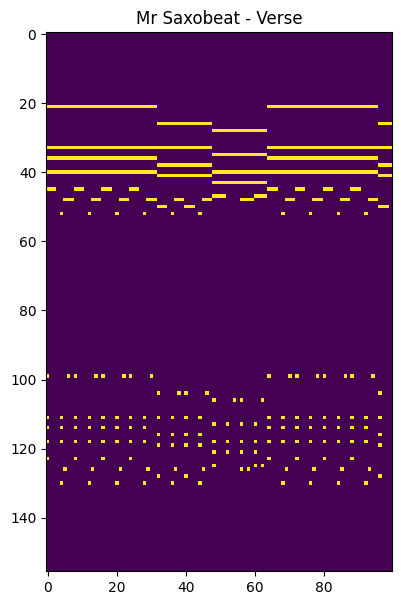

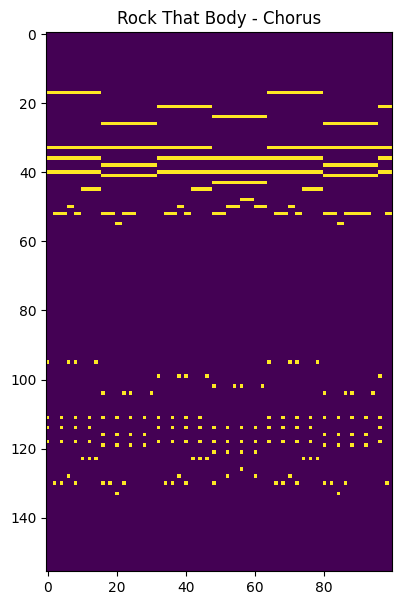

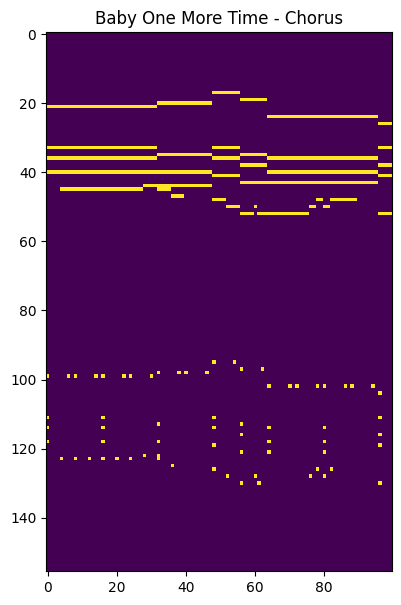

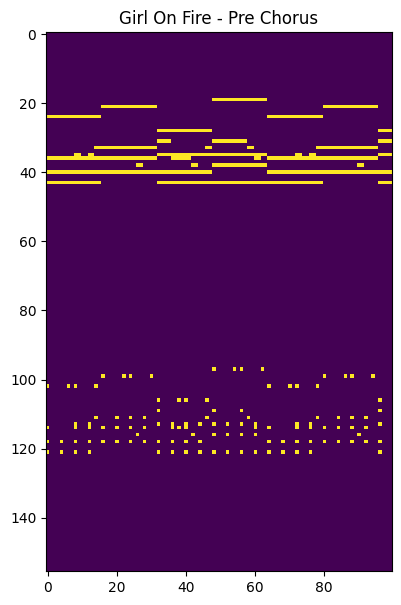

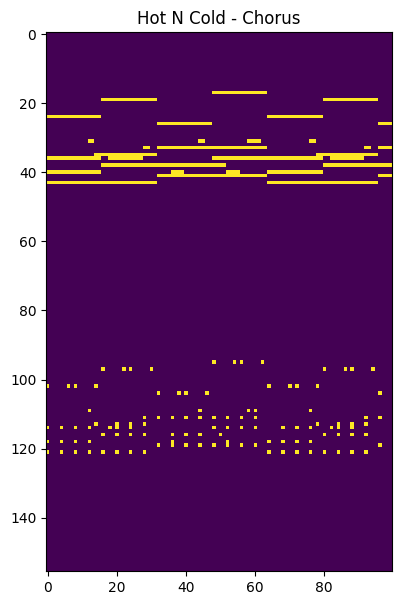

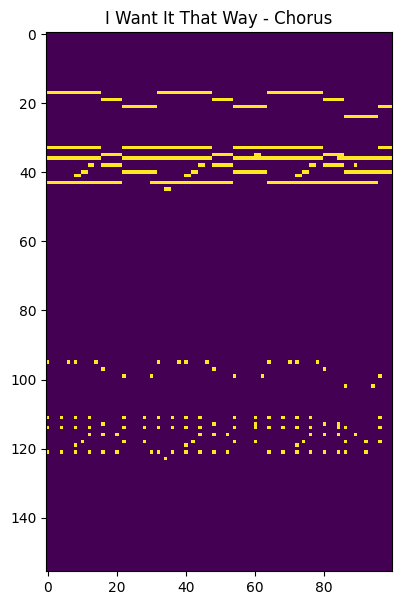

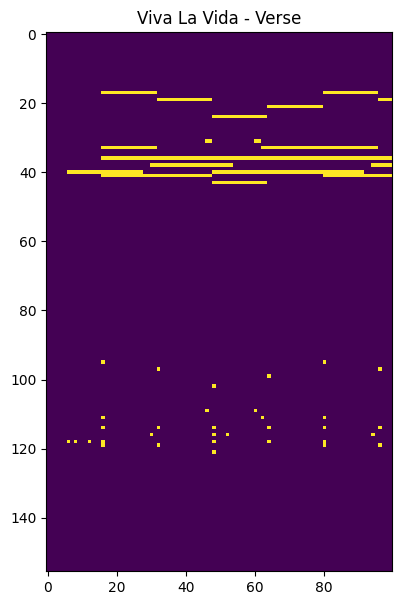

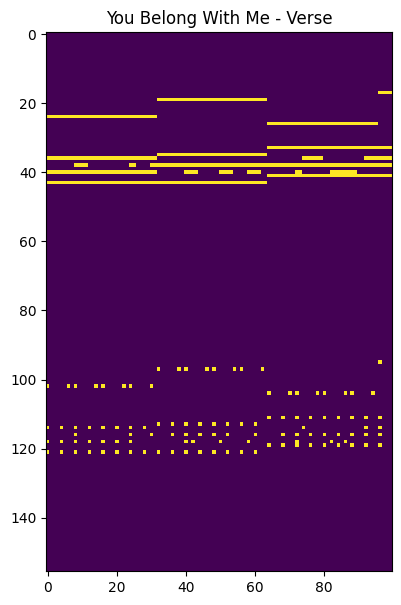

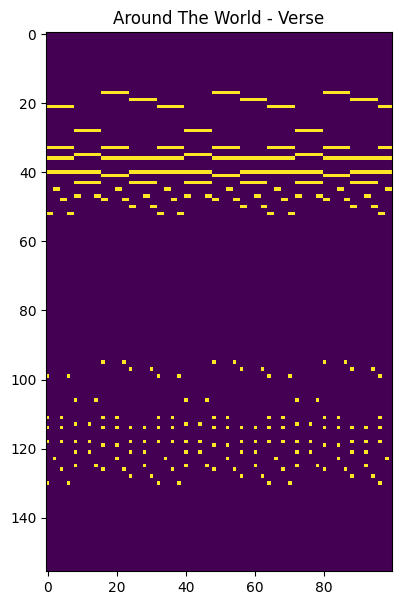

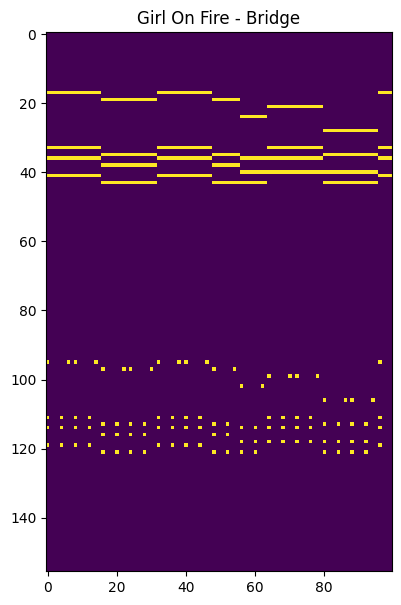

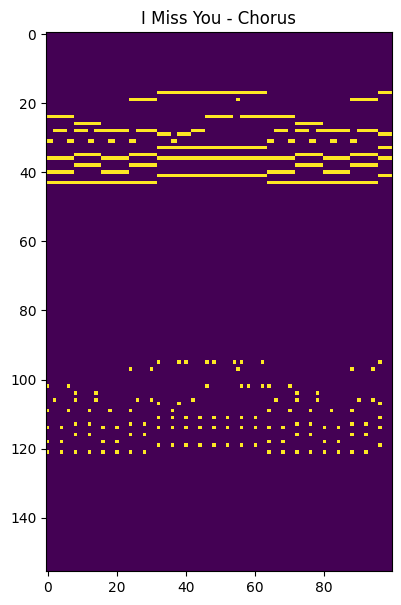

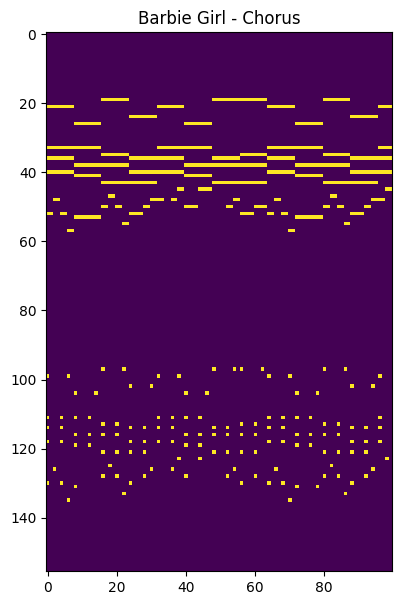

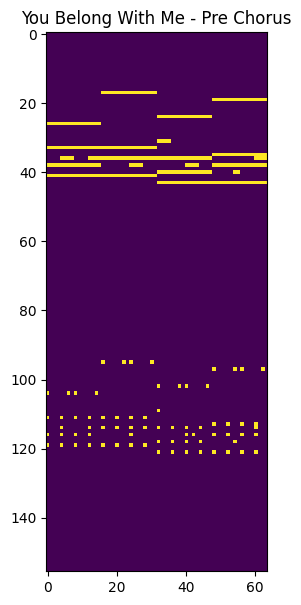

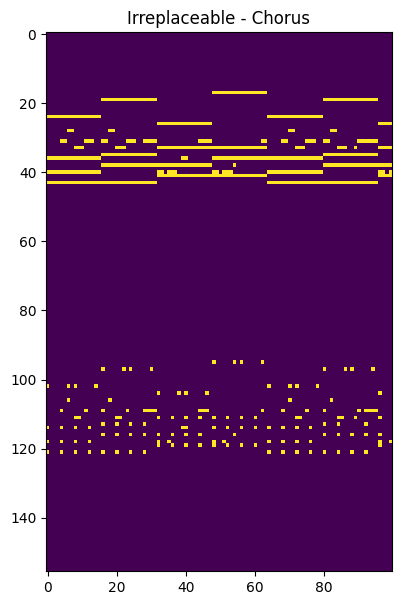

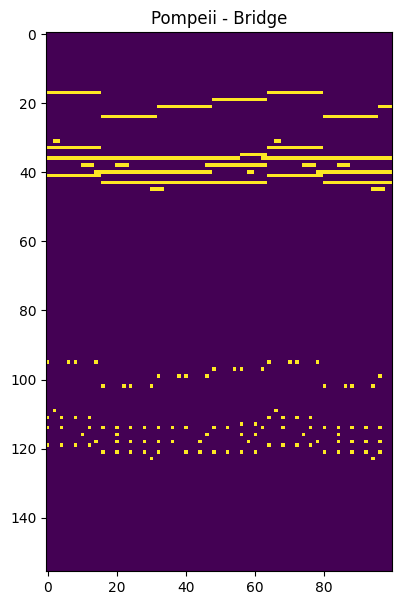

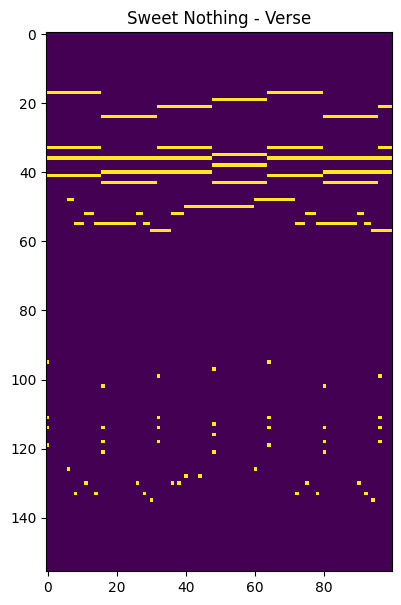

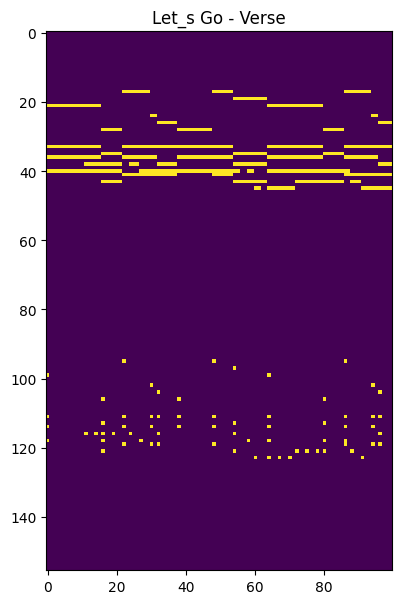

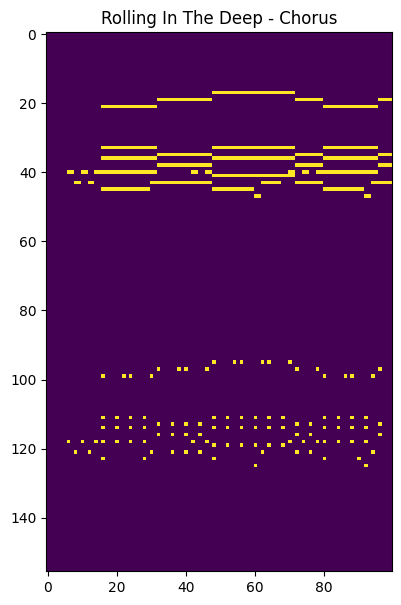

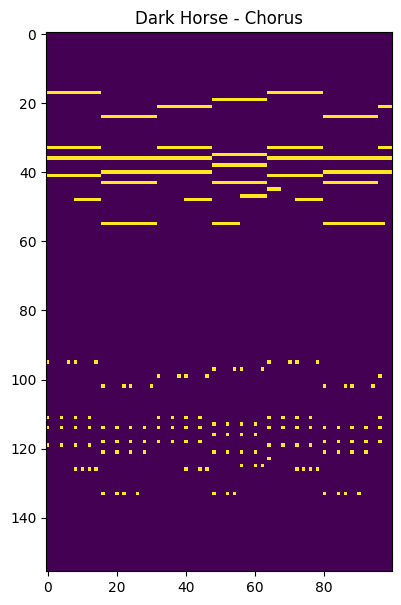

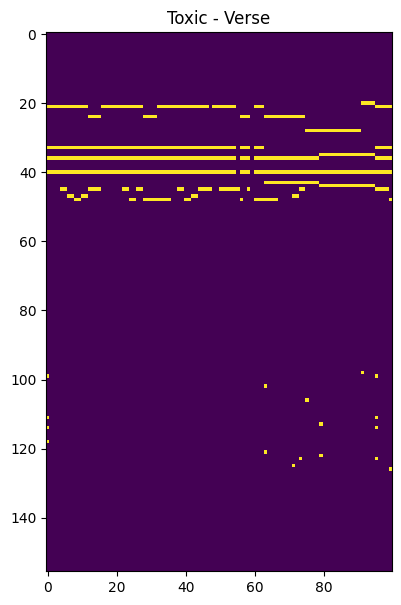

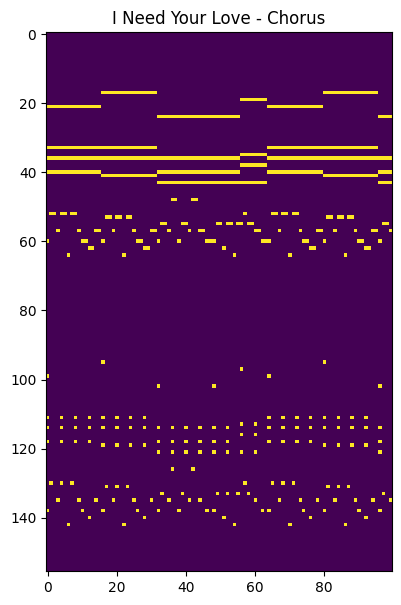

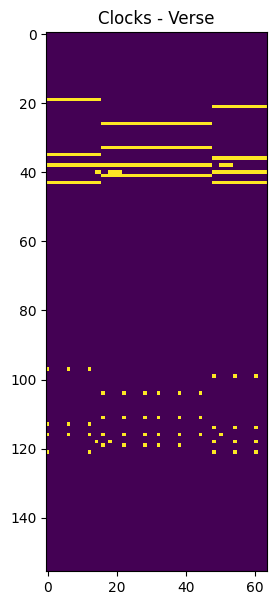

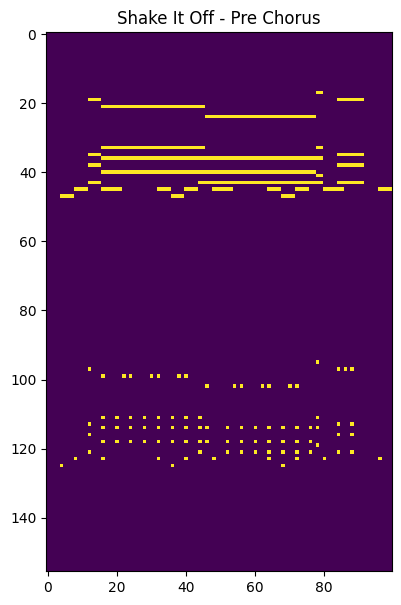

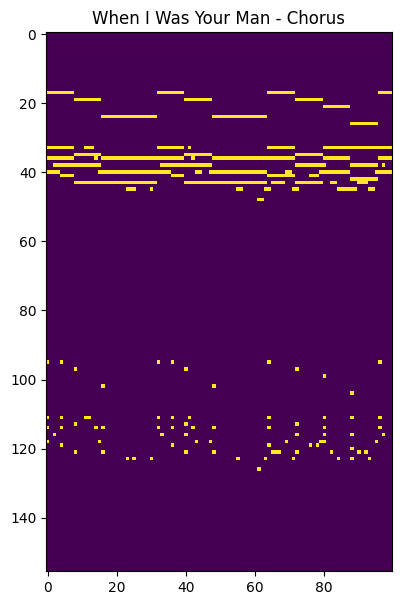

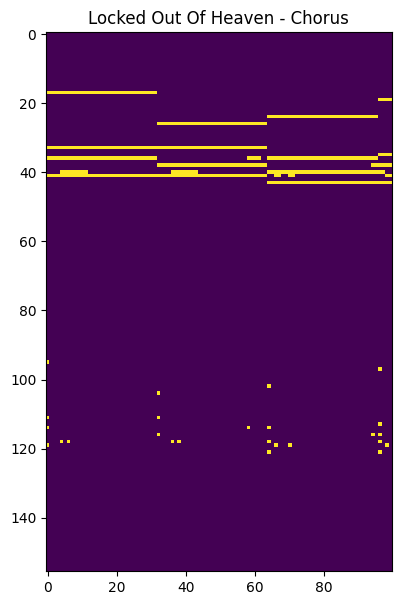

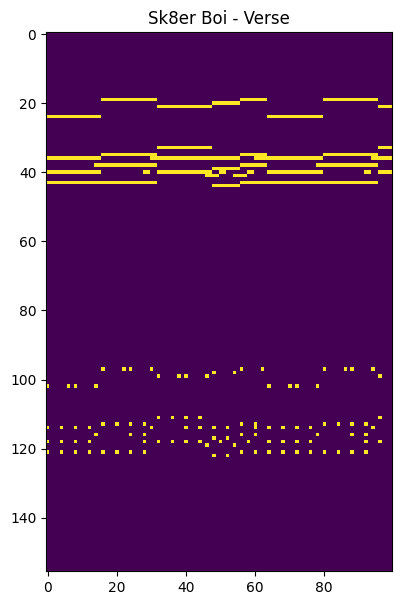

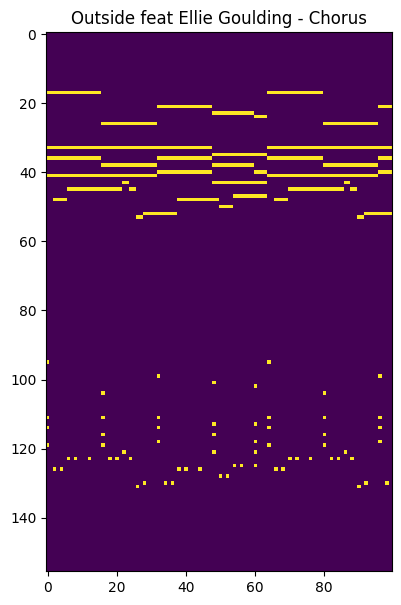

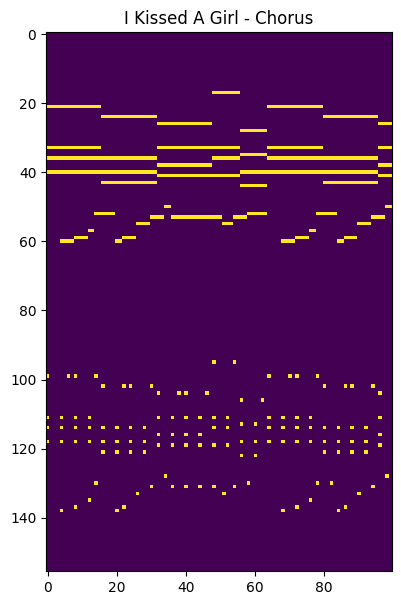

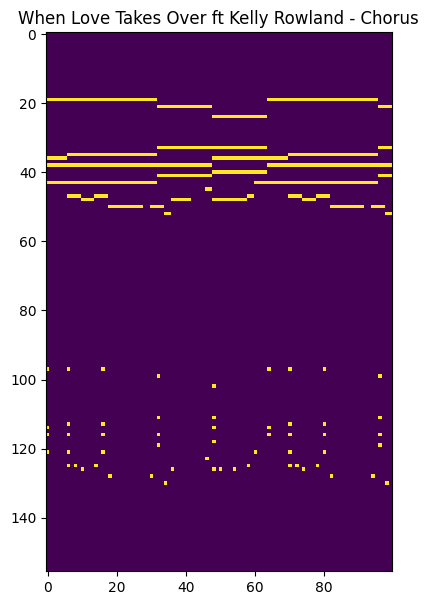

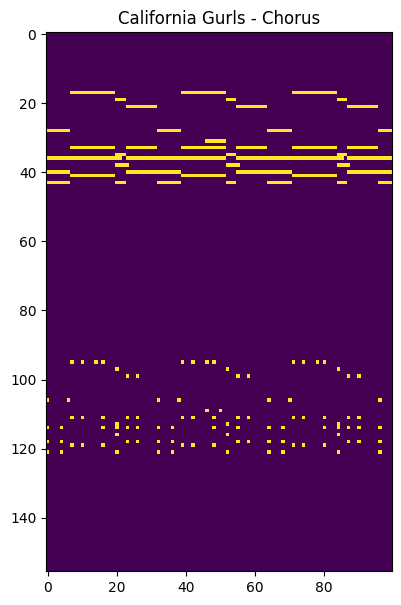

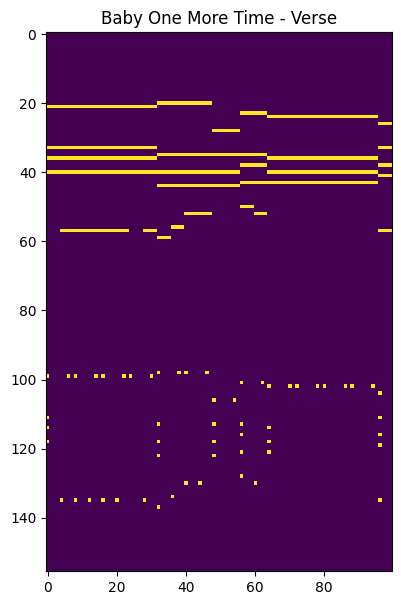

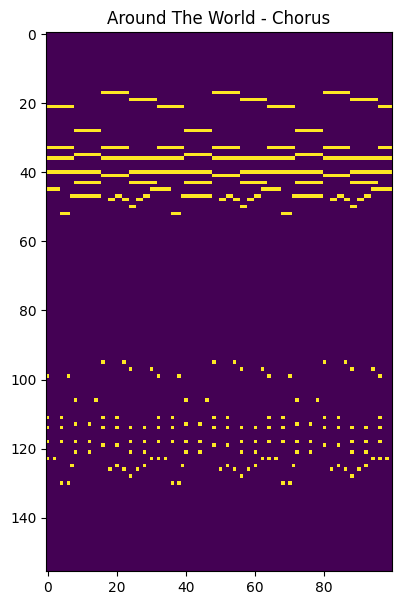

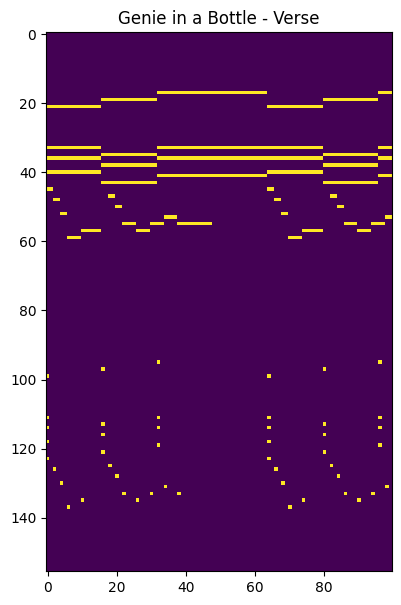

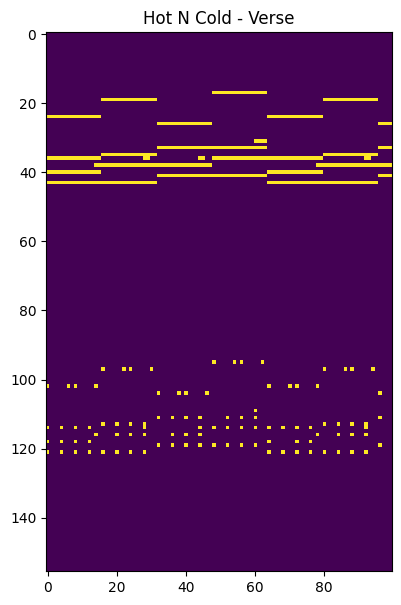

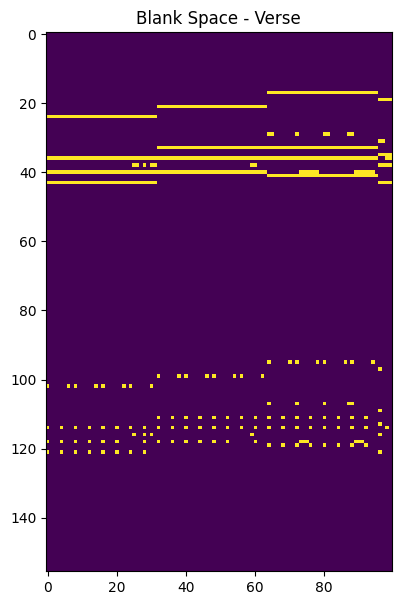

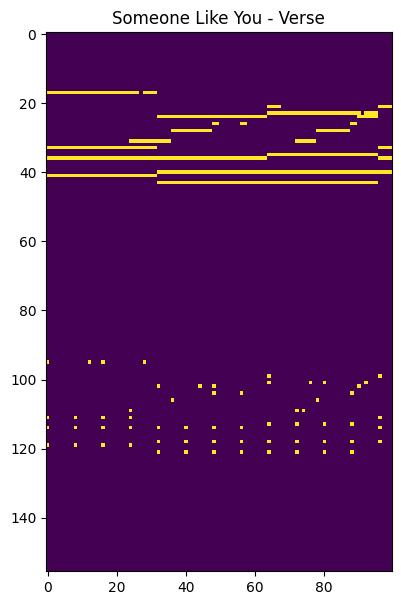

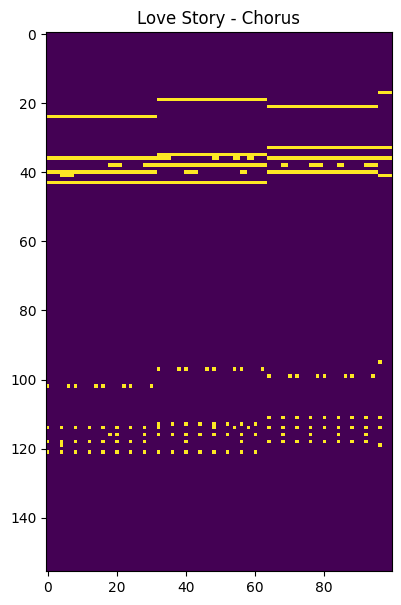

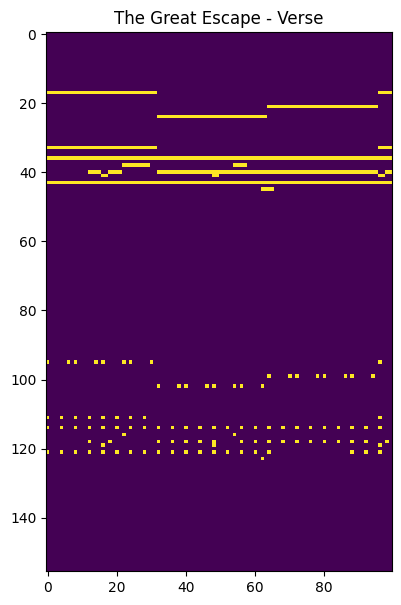

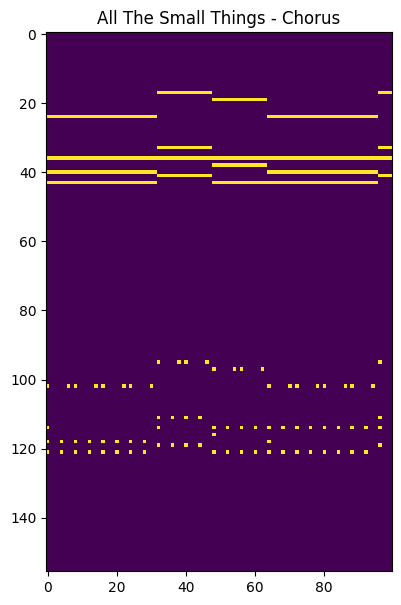

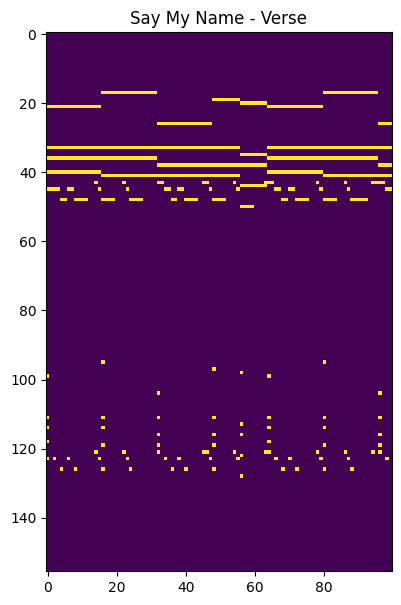

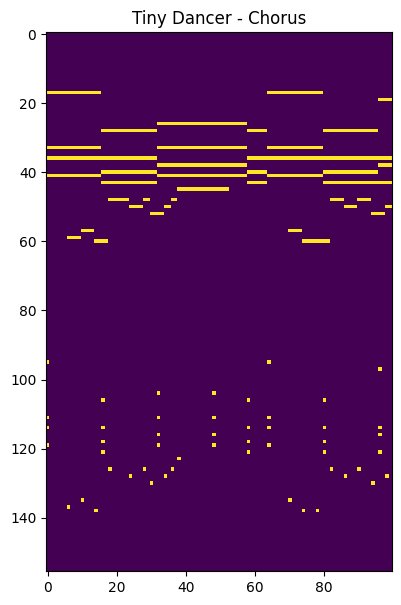

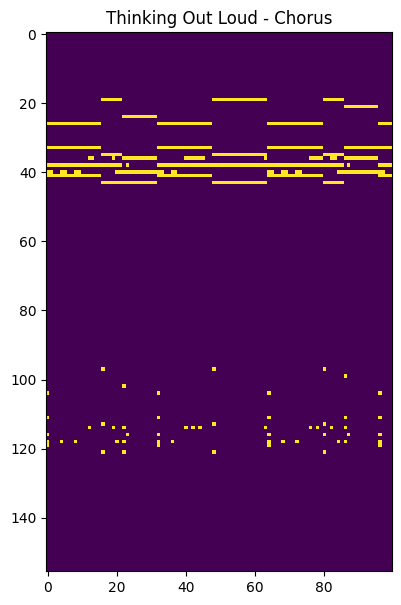

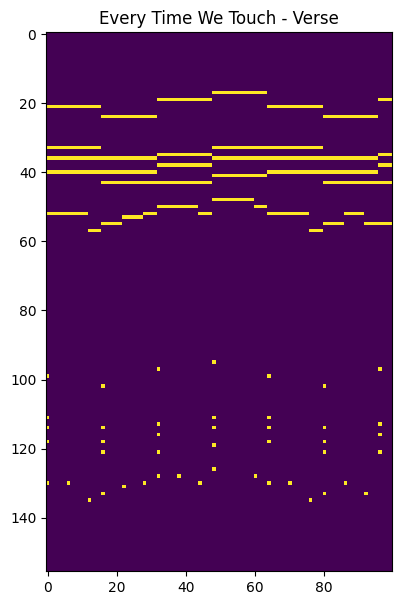

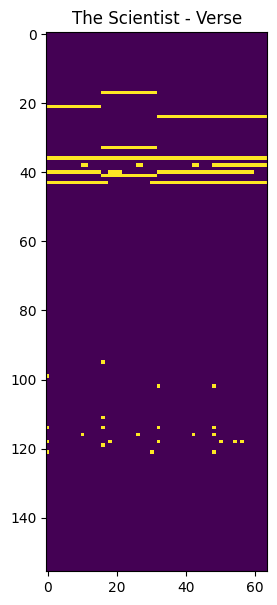

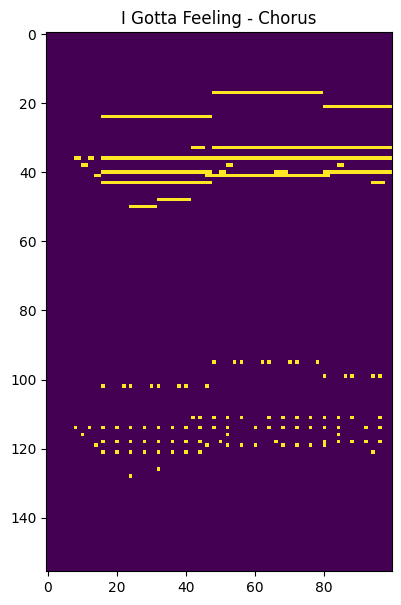

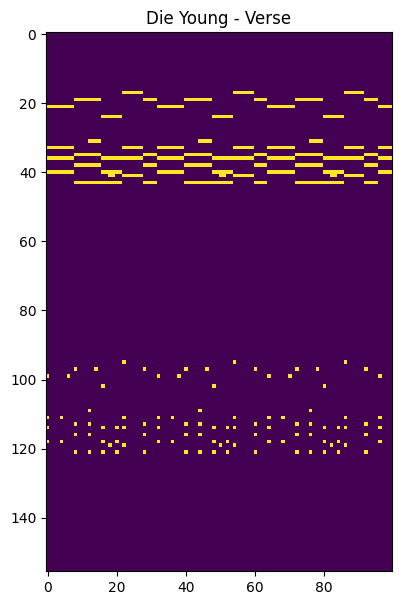

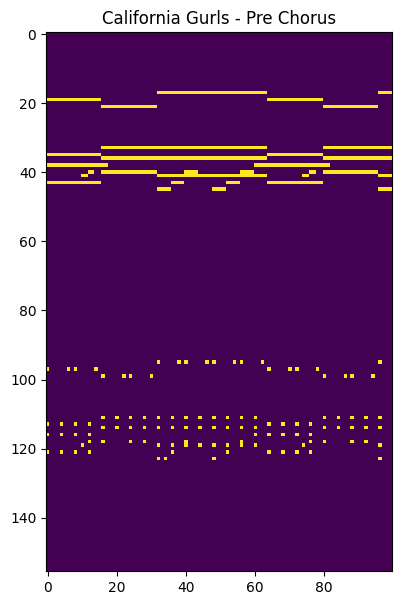

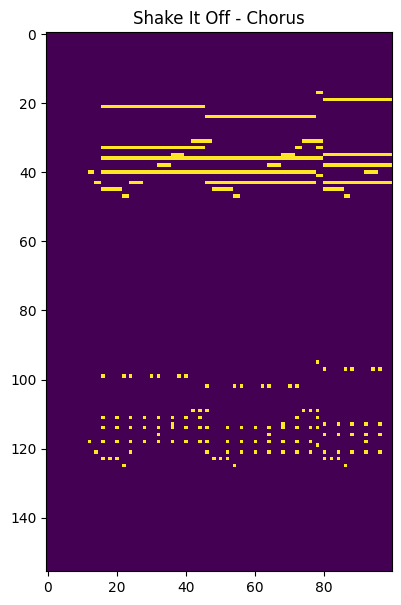

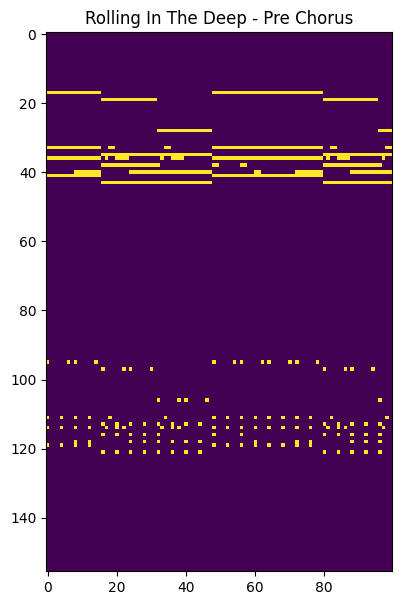

In [ ]:
plot_graphs(songs, 'song')

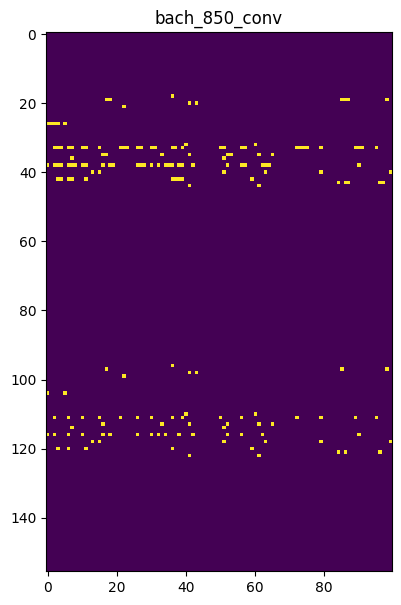

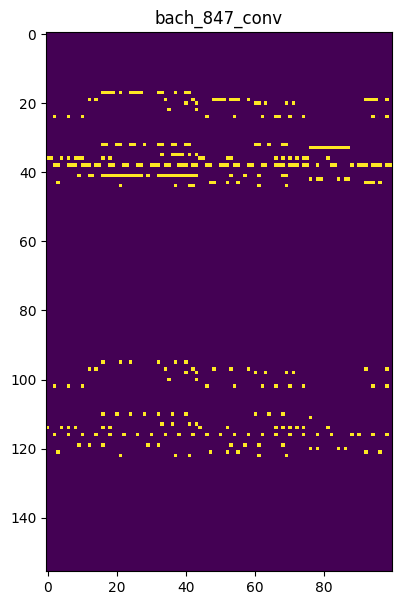

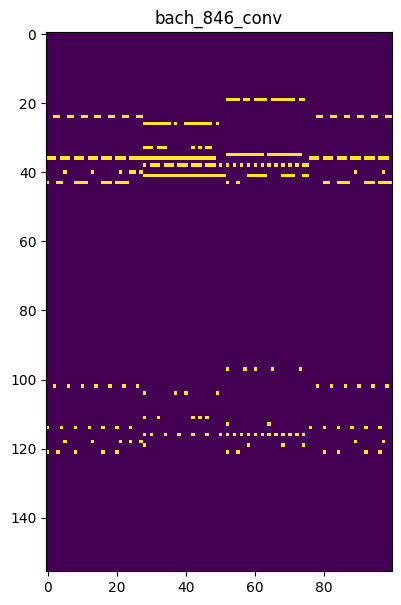

In [ ]:
plot_graphs(converted_songs, 'song')

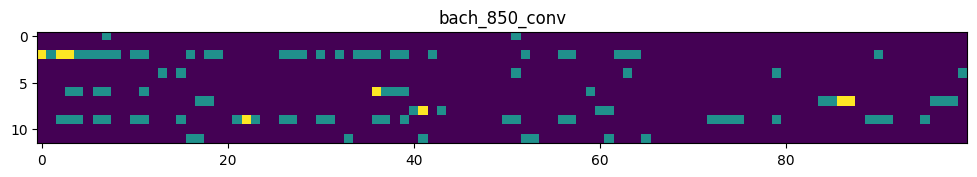

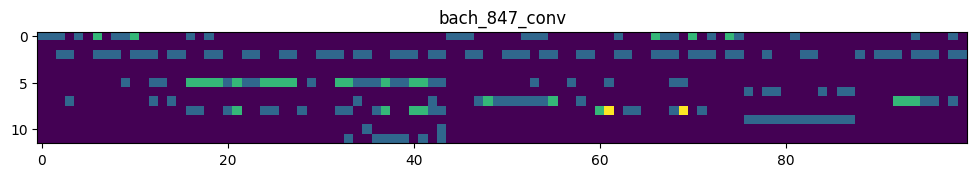

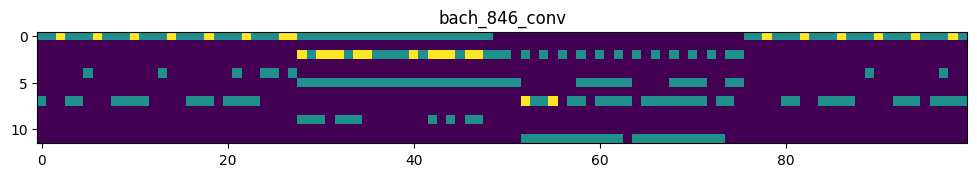

In [ ]:
plot_graphs(converted_songs, 'chroma')

# Classic to Pop

In [ ]:
songs = get_songs('./Classical_Music_Midi/bach')
songs = add_chromas(songs)
print ("{} songs processed".format(len(['song' in songs[f] for f in songs])))
print ("{} chromas processed".format(len(['chroma' in songs[f] for f in songs])))

3 songs processed
3 chromas processed


In [ ]:
sess = train_model(songs, 100, "classicto_pop")
source_path = './Pop_Music_Midi'
fit_gen(source_path, sess)

For epoch 0: D_Loss: 1.46, G_Loss: 32.14
For epoch 1200: D_Loss: 0.14, G_Loss: 6.64
For epoch 2400: D_Loss: 0.15, G_Loss: 5.70
For epoch 3600: D_Loss: 0.01, G_Loss: 10.02
For epoch 4800: D_Loss: 0.00, G_Loss: 17.47
For epoch 6000: D_Loss: 0.00, G_Loss: 17.22
For epoch 7200: D_Loss: 0.00, G_Loss: 17.24
For epoch 8400: D_Loss: 0.00, G_Loss: 15.91
For epoch 9600: D_Loss: 0.00, G_Loss: 18.98
For epoch 10800: D_Loss: 0.00, G_Loss: 21.72
For epoch 12000: D_Loss: 0.00, G_Loss: 24.41
Processed 122 songs with chroma features.
Style transfer completed.


In [ ]:
converted_songs = get_songs(f'{source_path}_conv')
converted_songs = add_chromas(converted_songs)
for f in glob.glob('{}/*.mid*'.format(source_path+'_conv')):
  data = pretty_midi.PrettyMIDI(f)
display_audio(data)

<ipython-input-36-9f502624e022>:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (12,7))


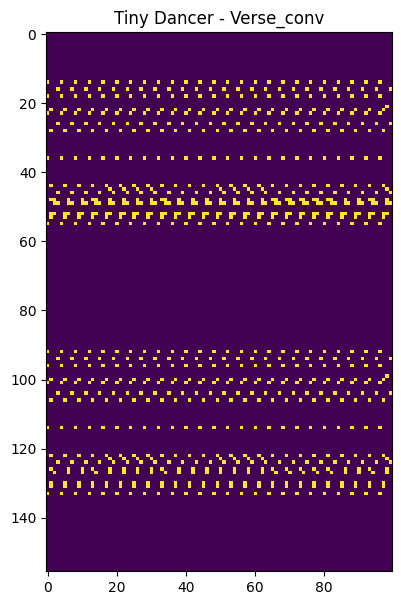

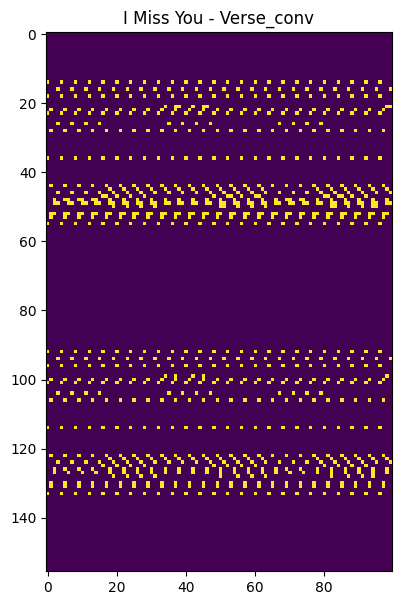

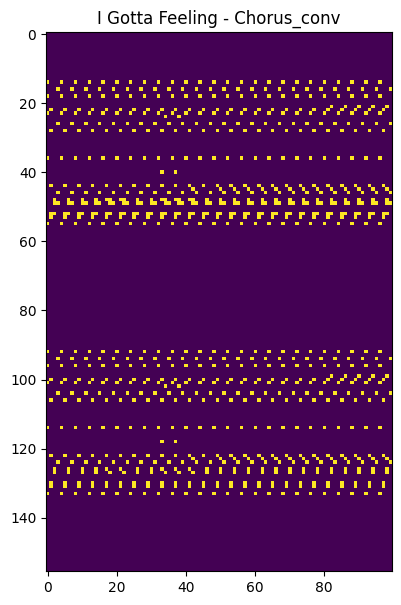

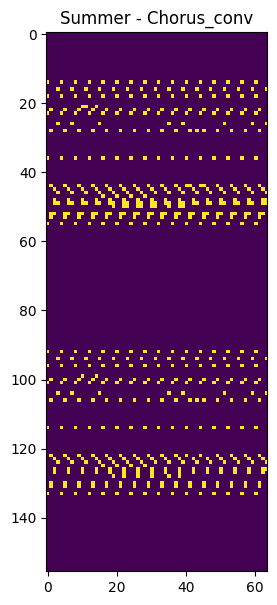

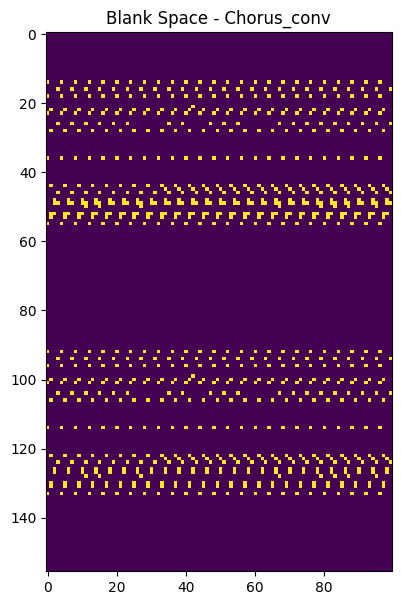

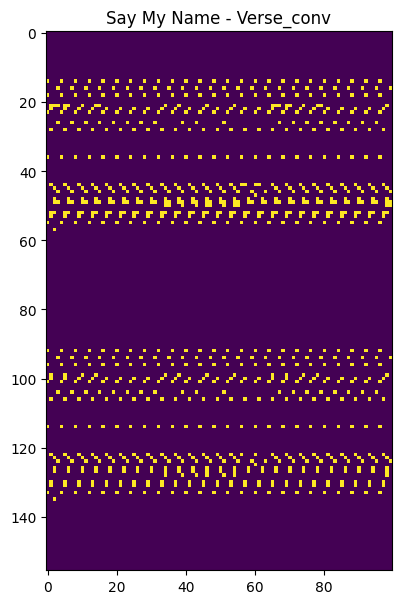

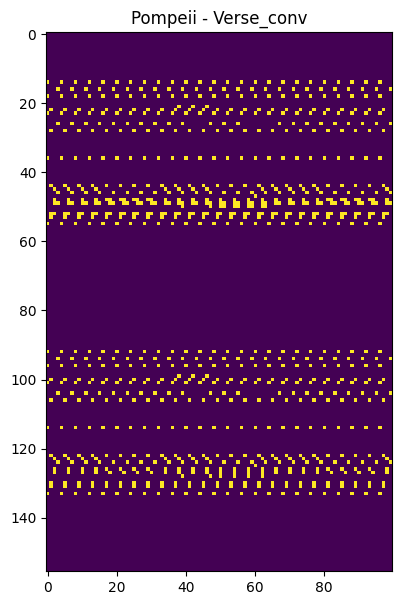

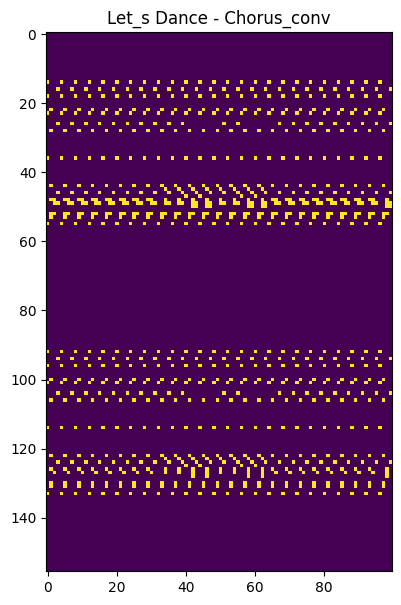

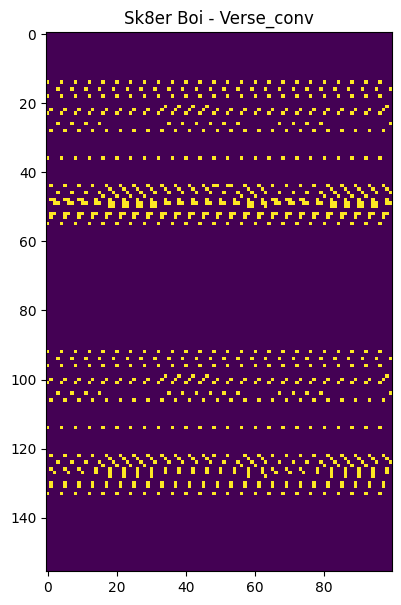

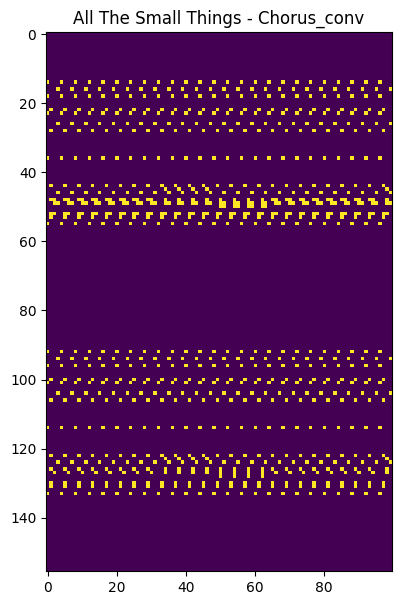

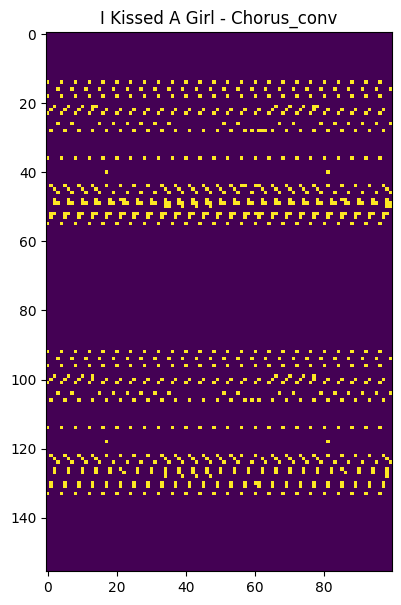

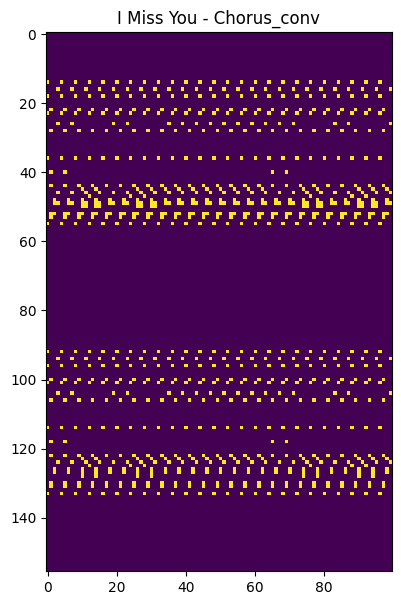

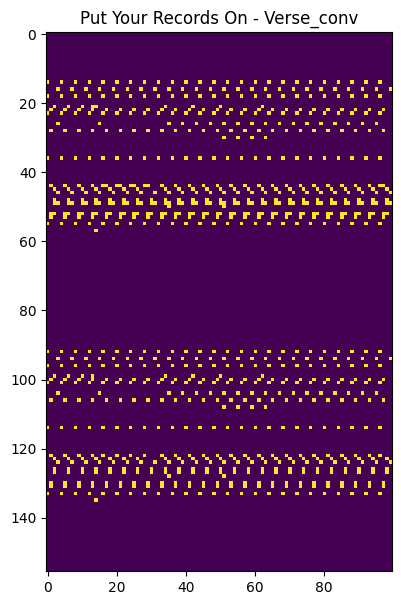

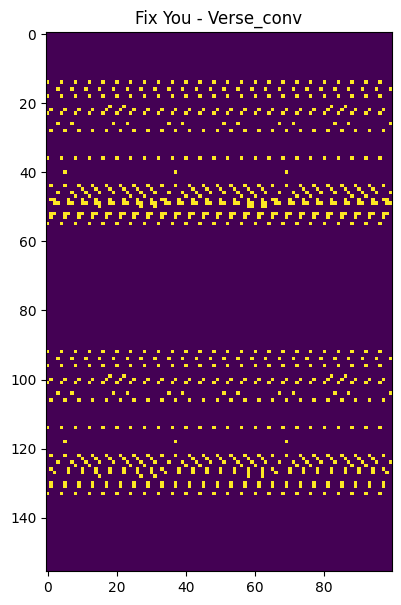

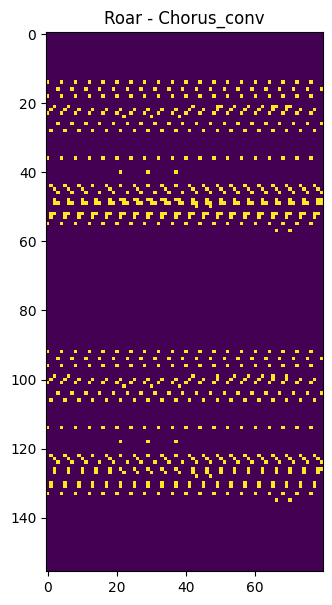

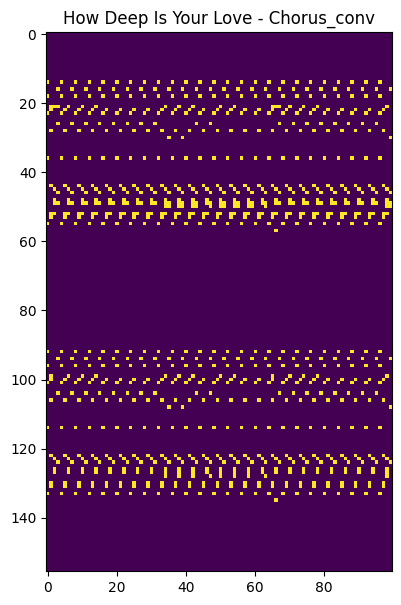

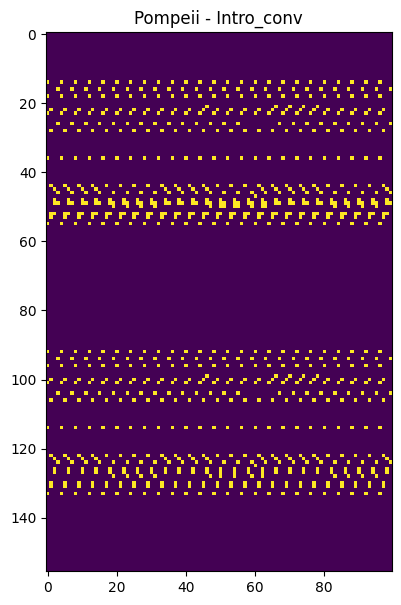

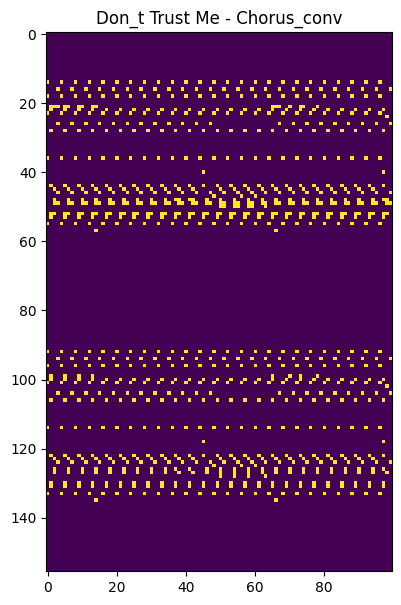

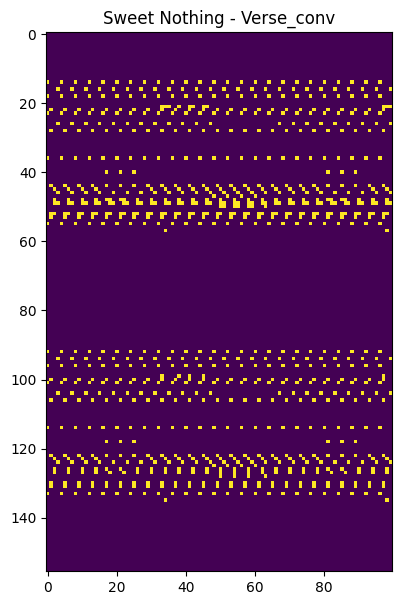

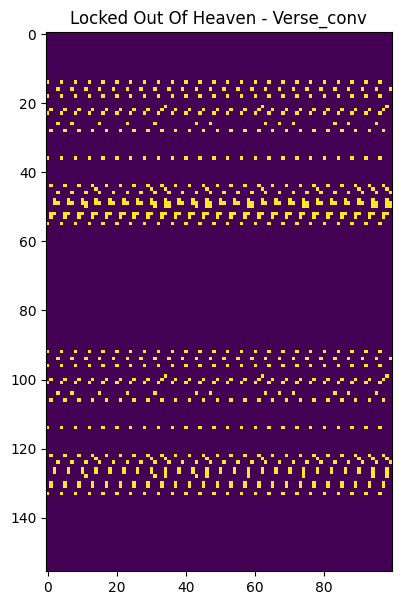

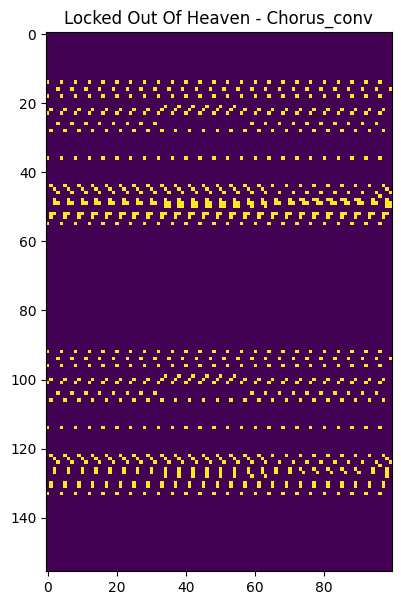

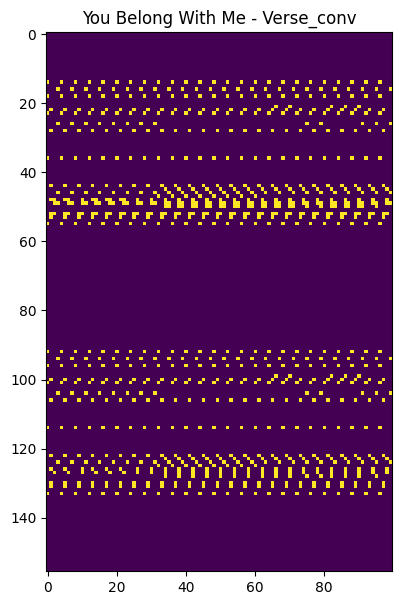

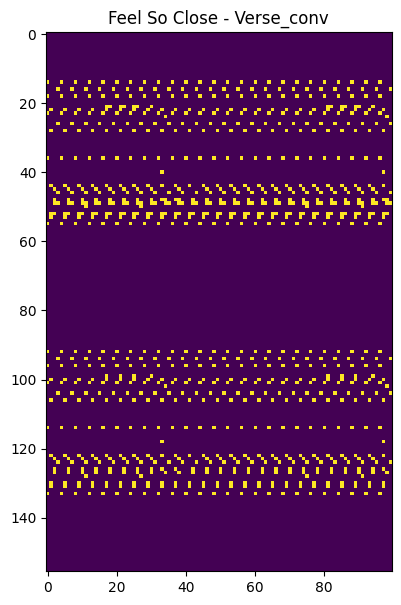

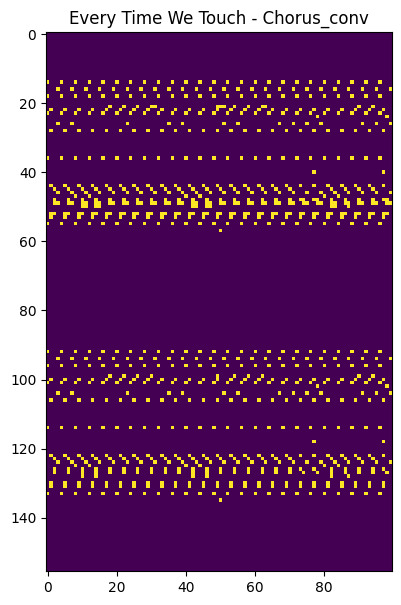

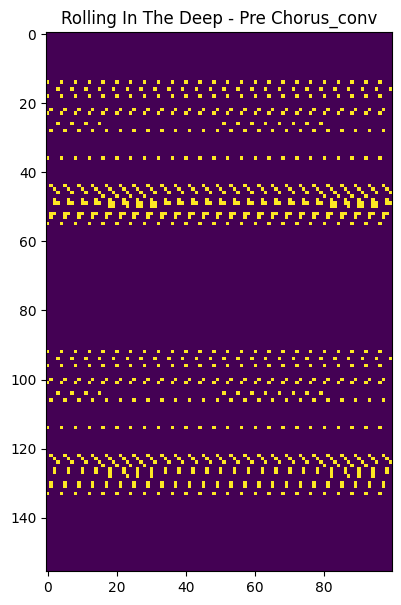

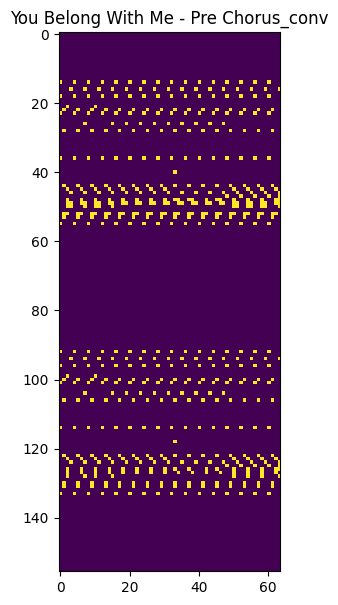

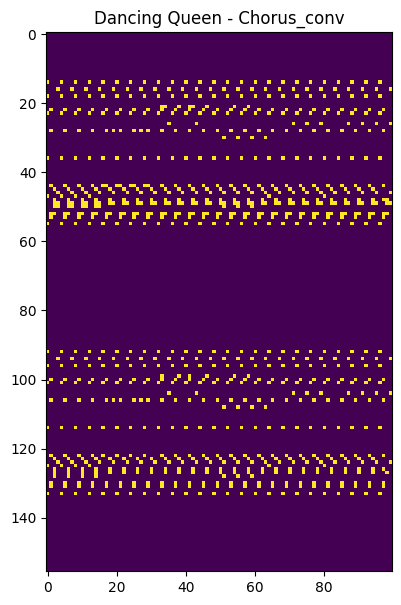

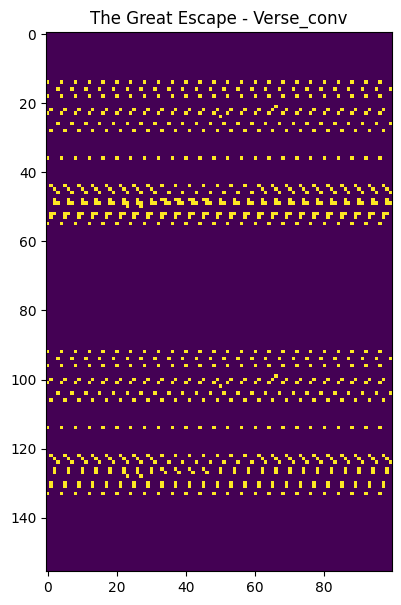

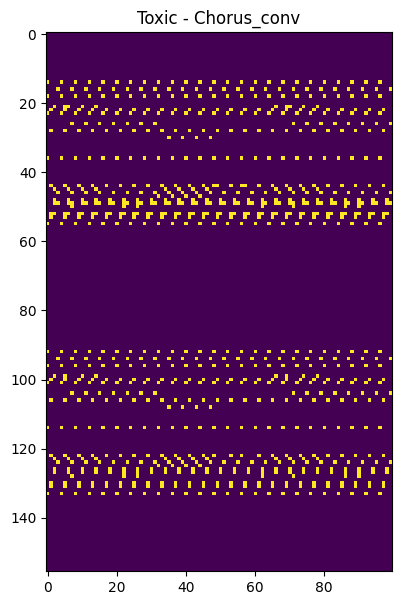

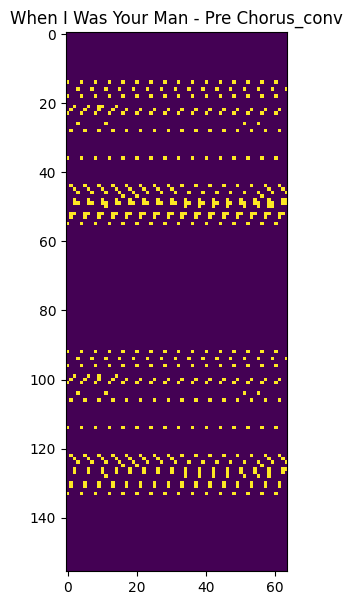

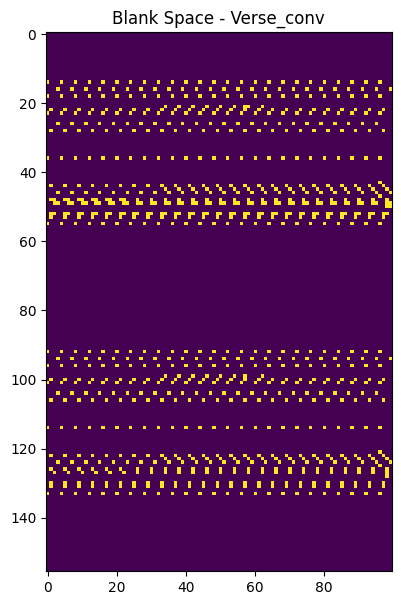

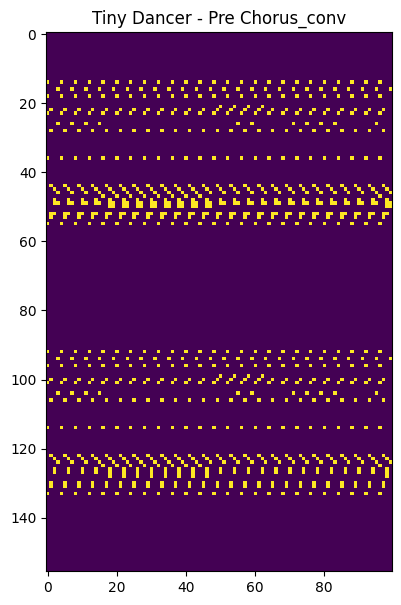

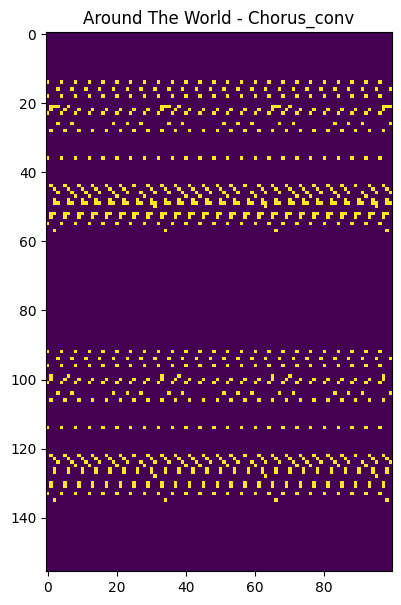

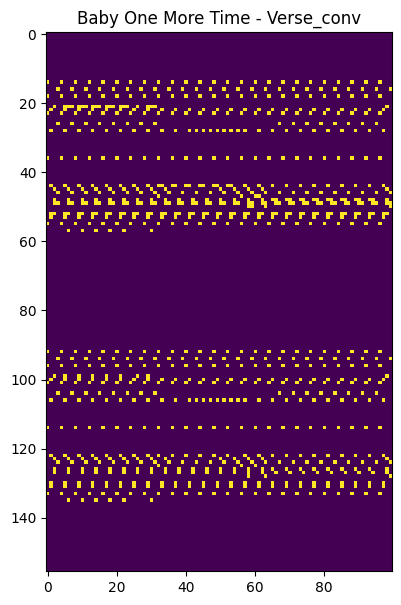

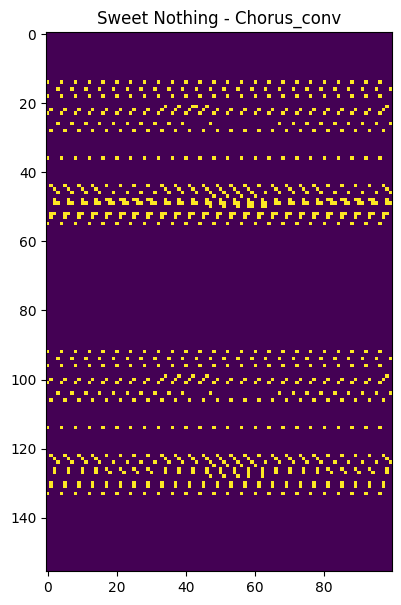

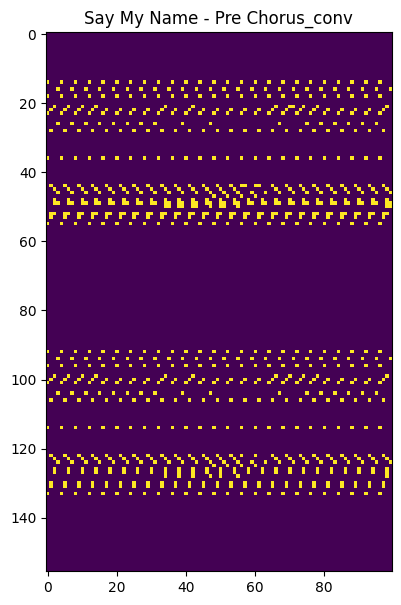

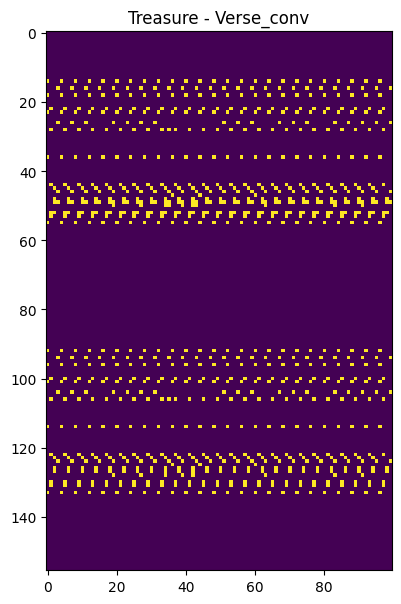

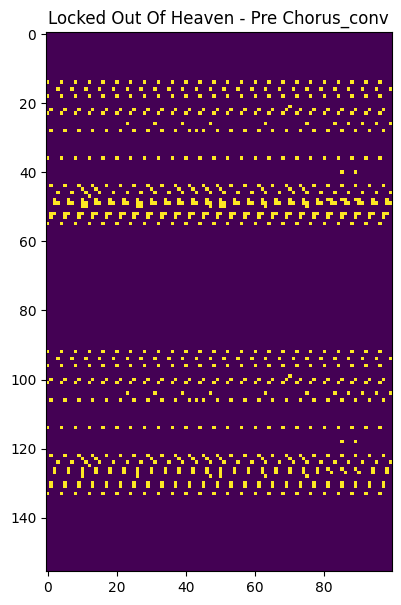

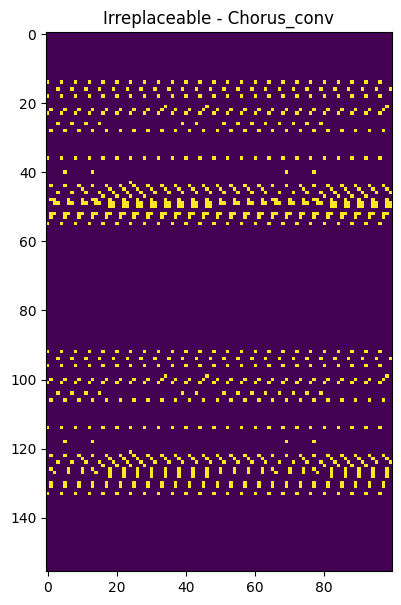

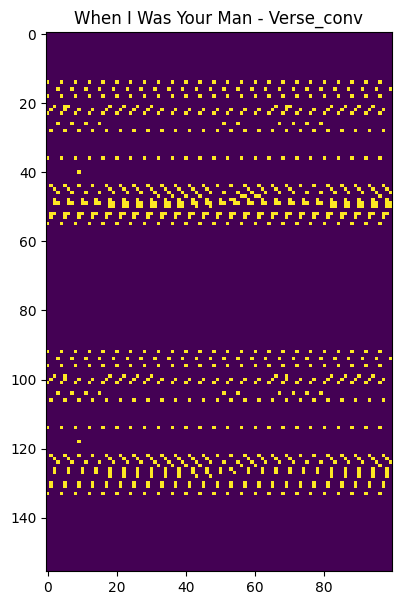

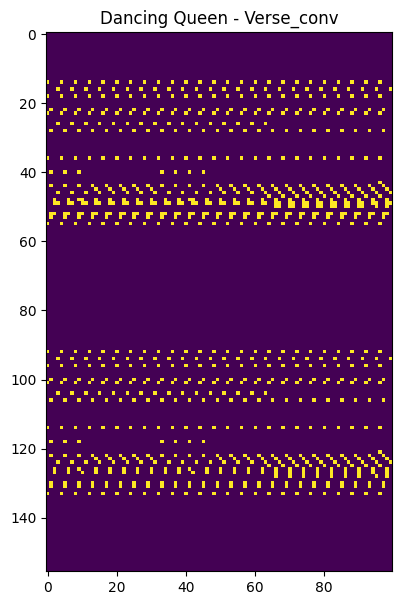

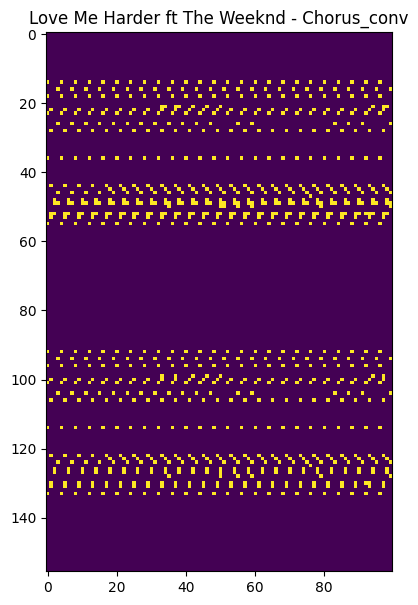

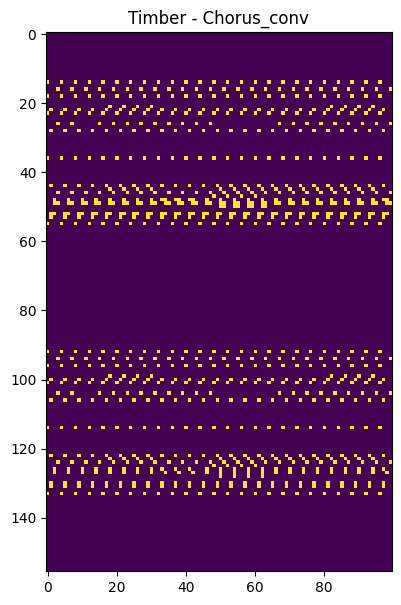

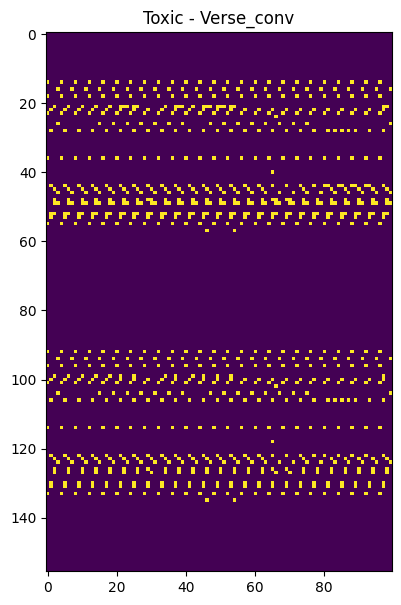

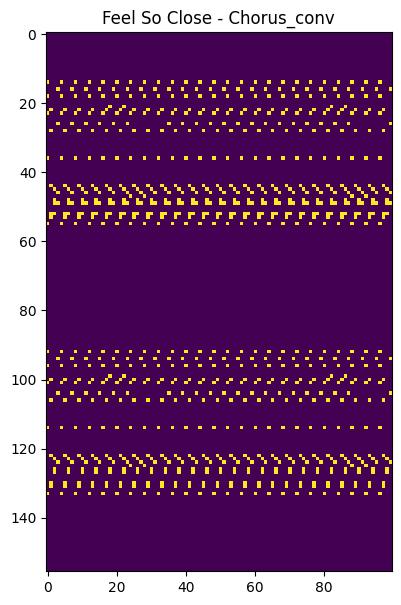

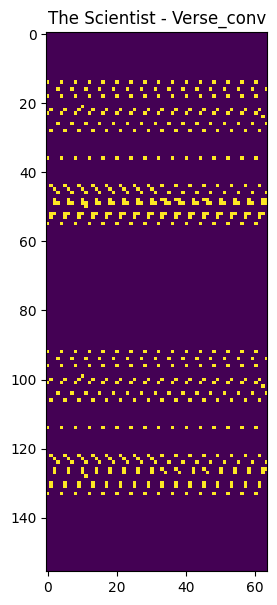

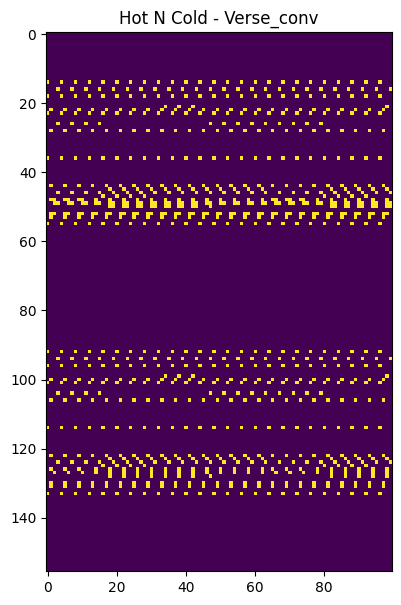

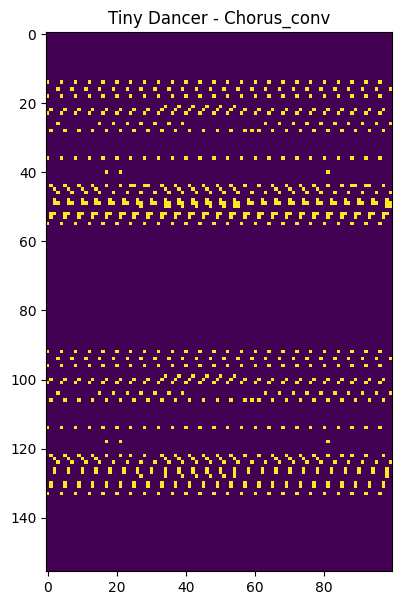

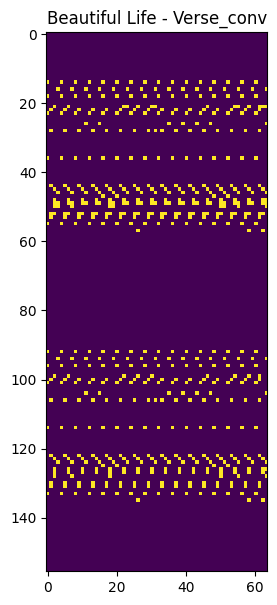

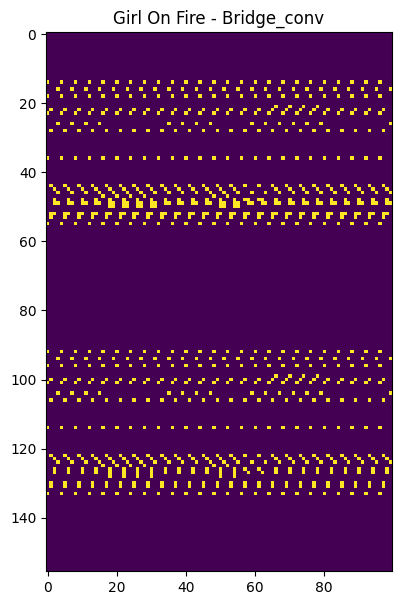

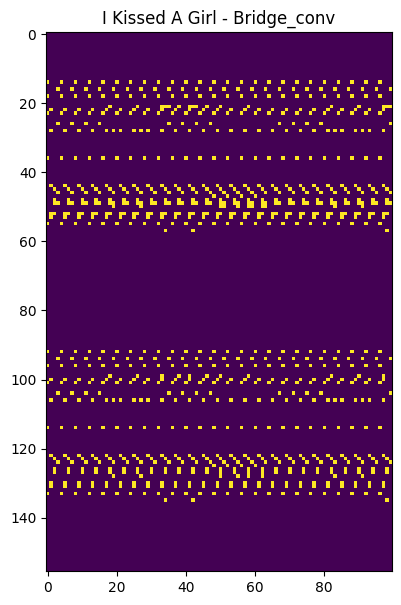

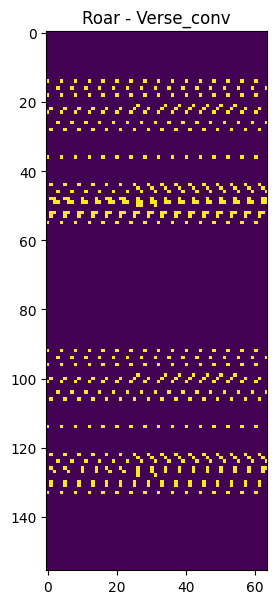

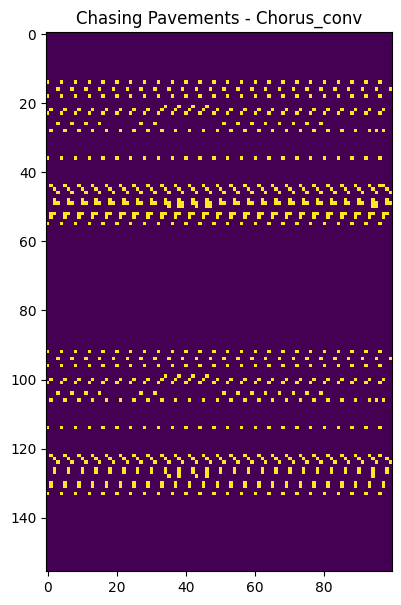

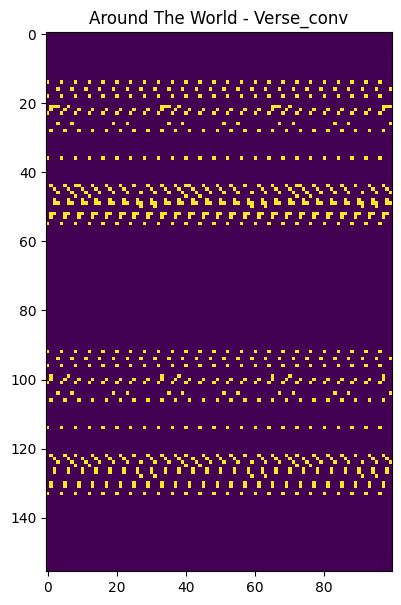

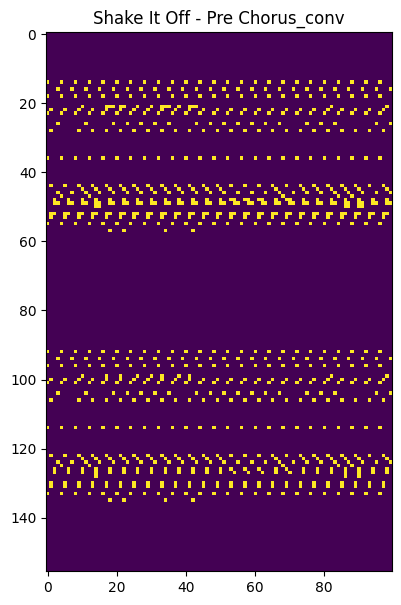

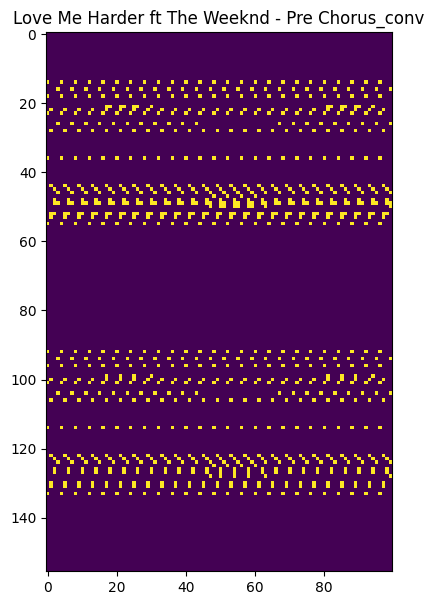

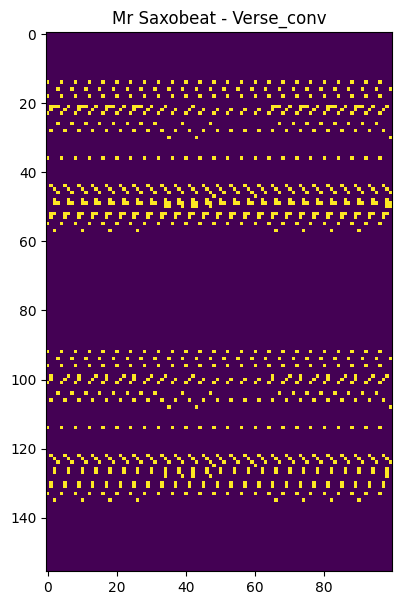

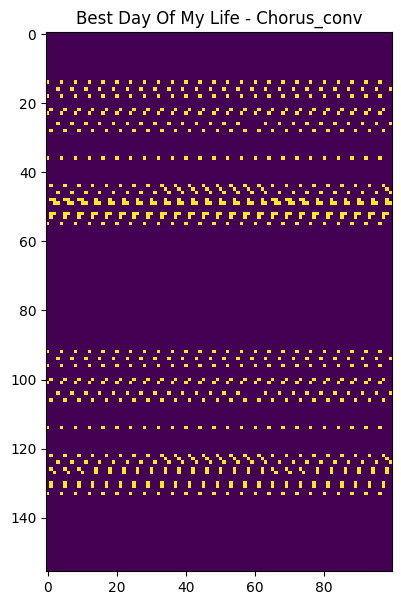

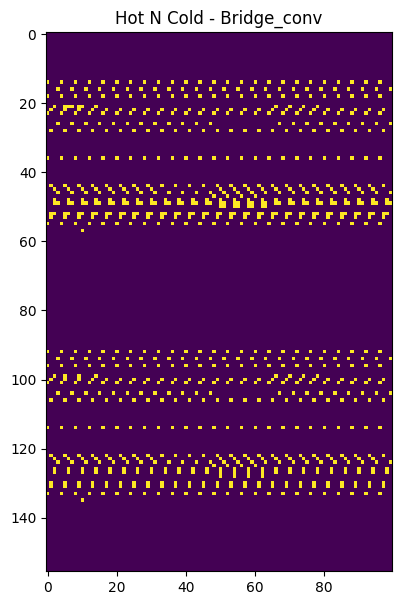

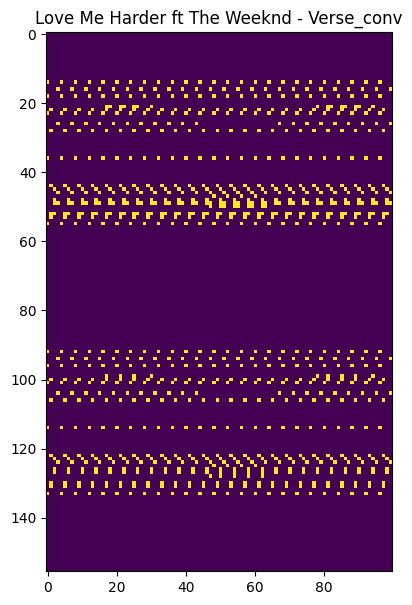

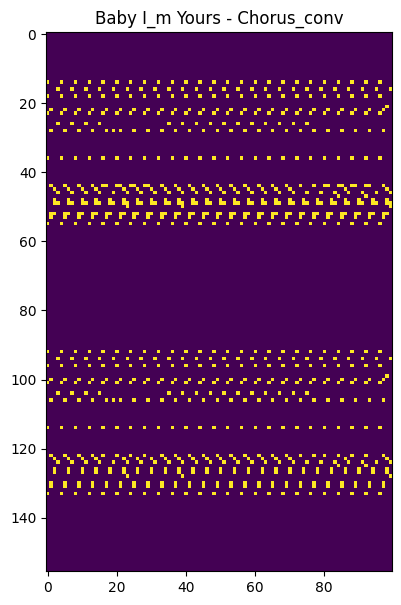

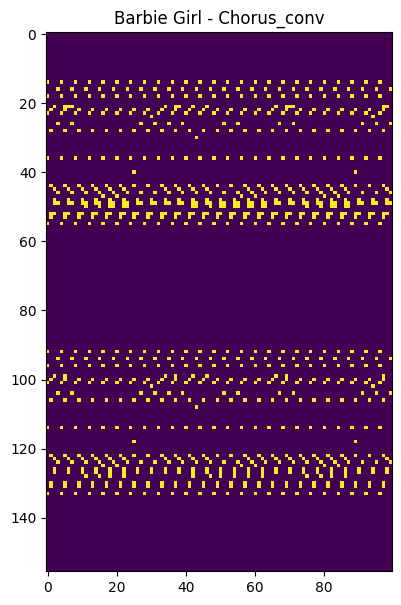

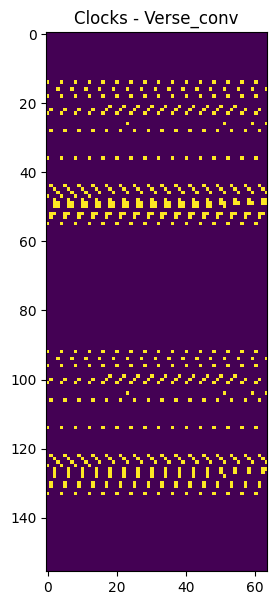

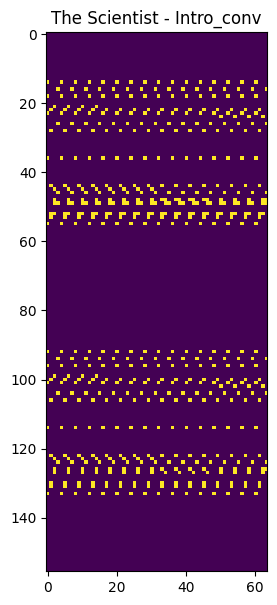

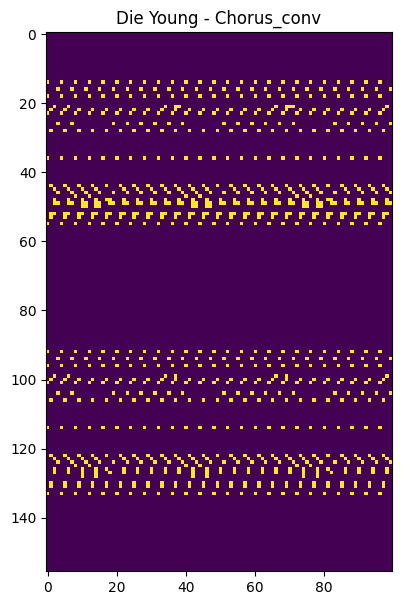

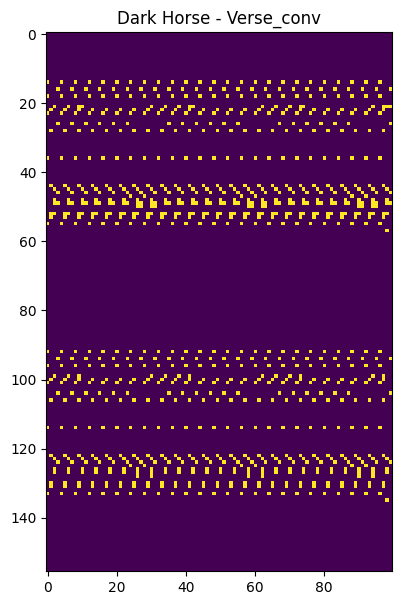

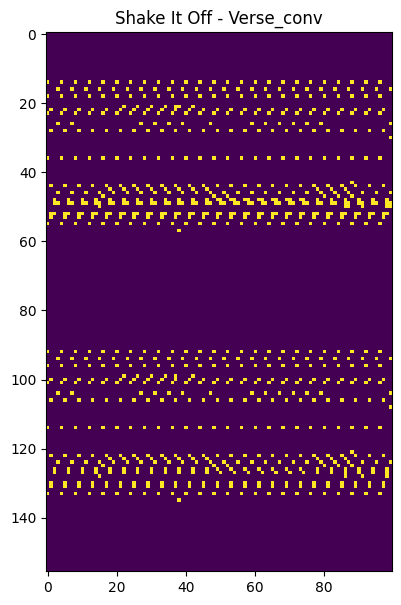

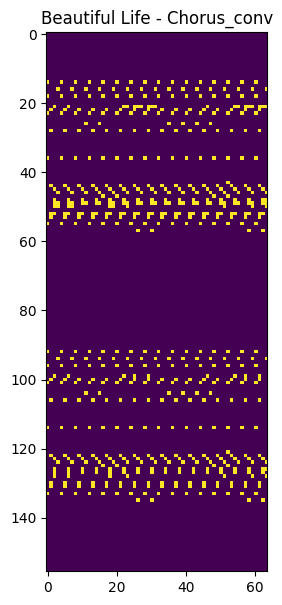

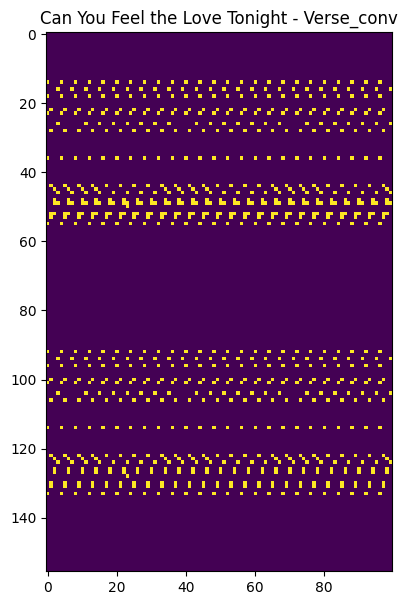

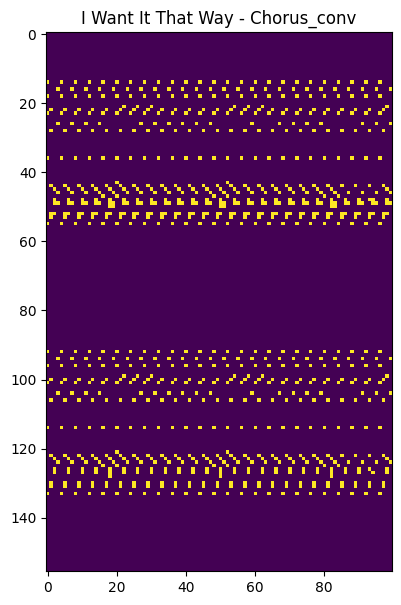

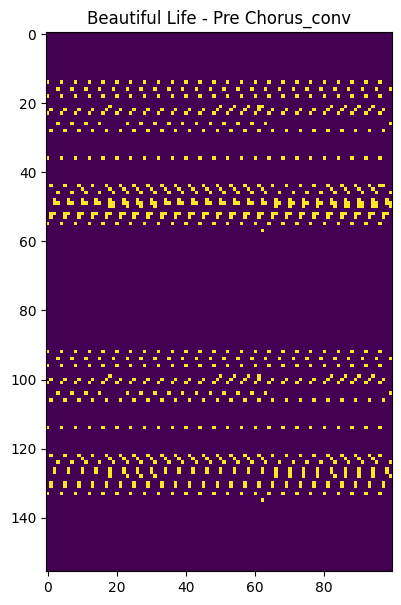

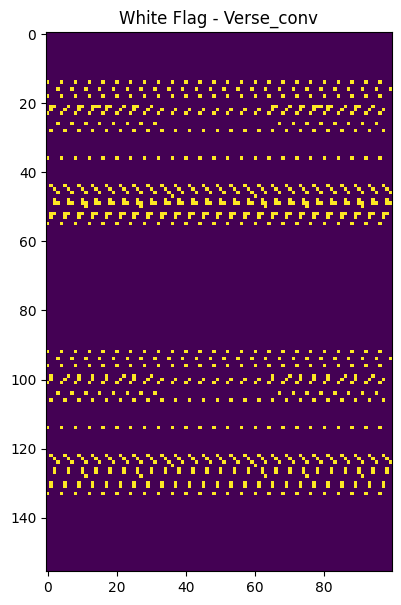

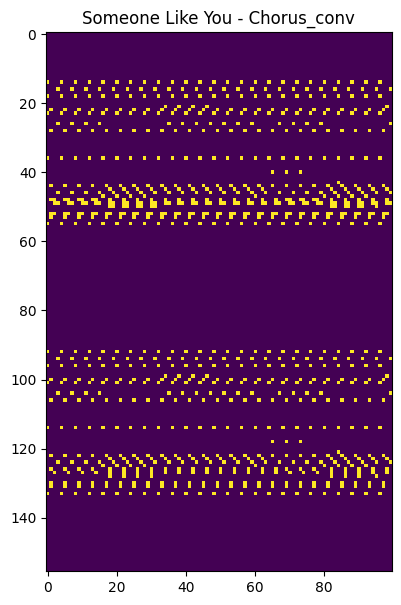

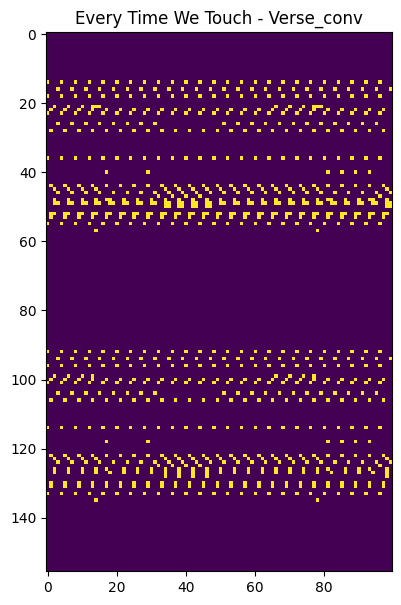

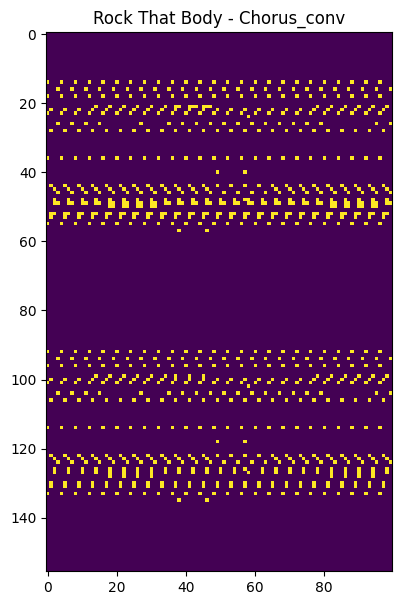

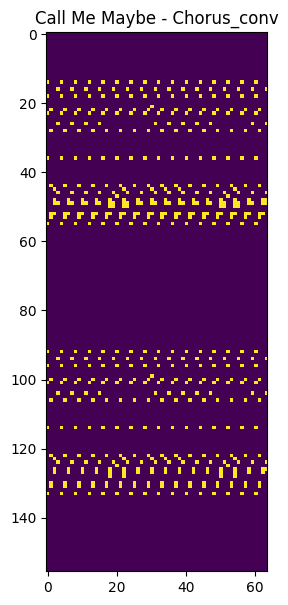

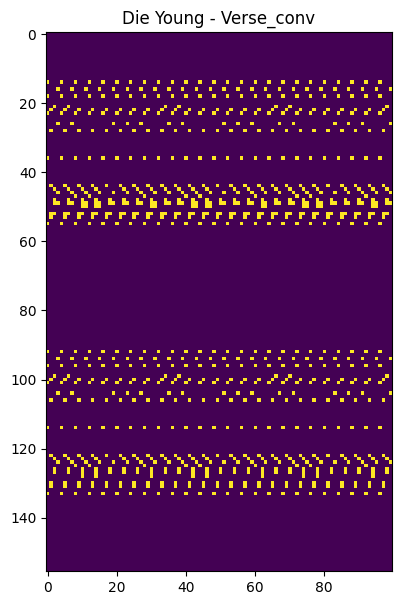

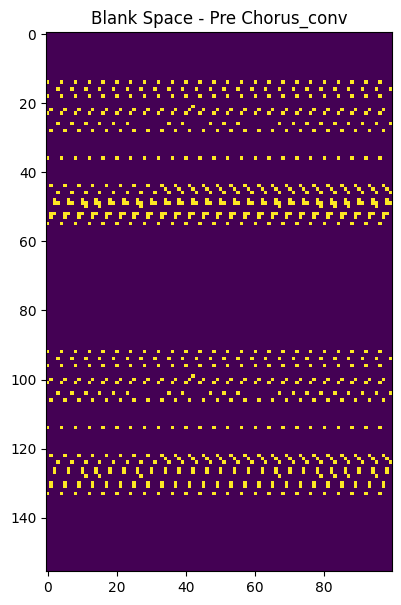

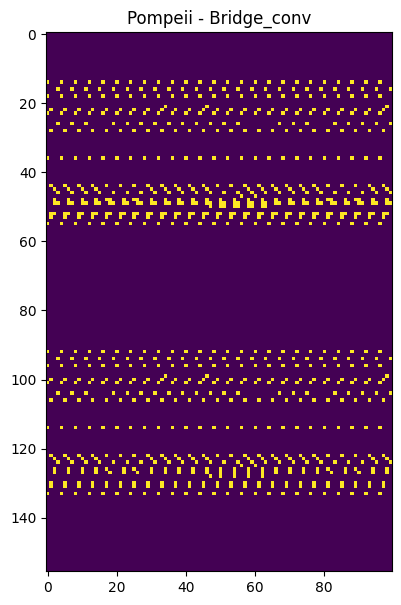

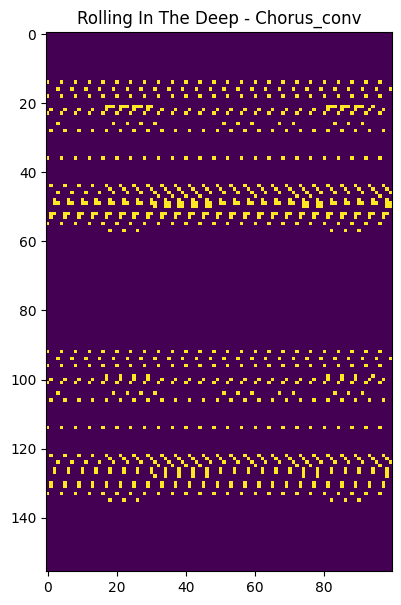

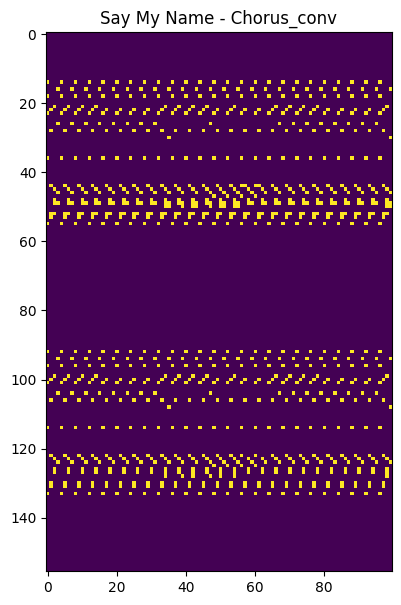

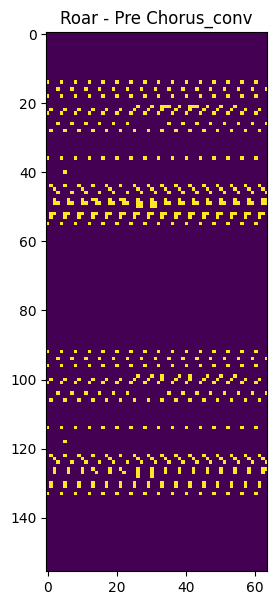

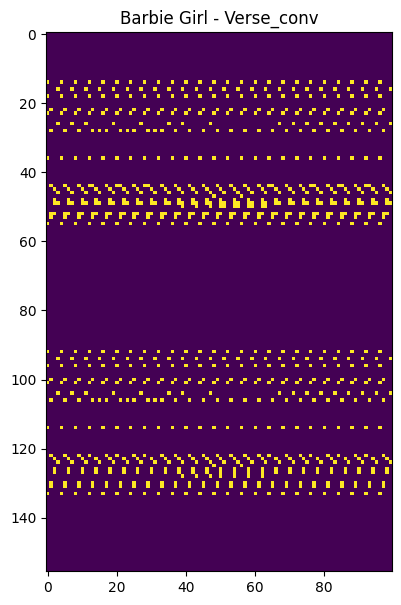

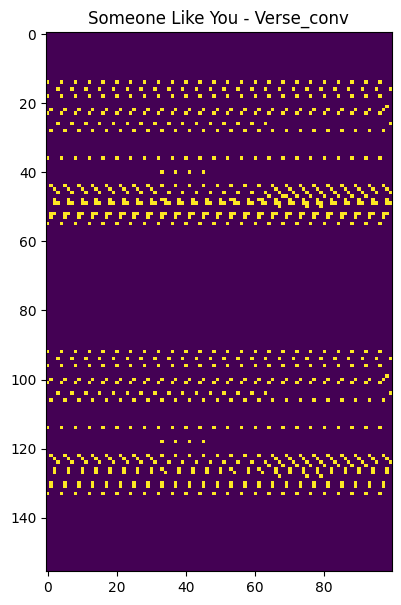

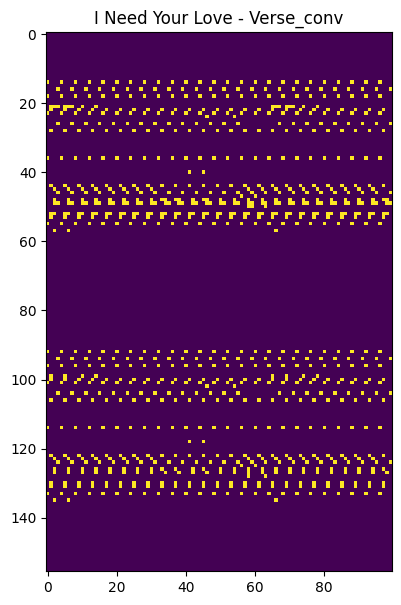

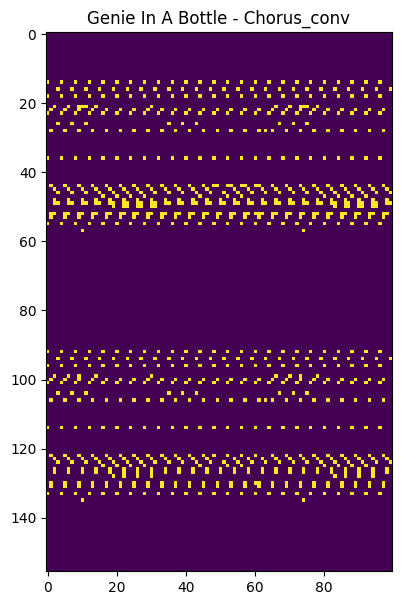

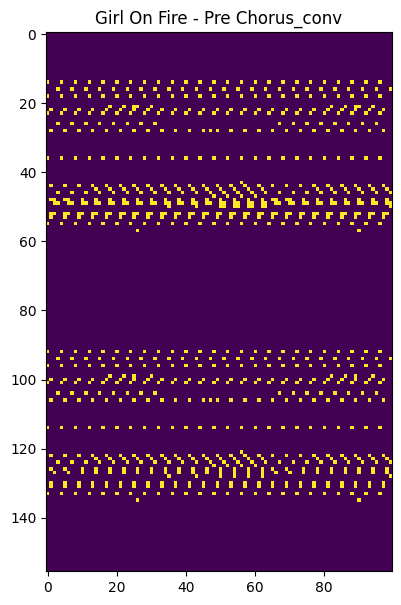

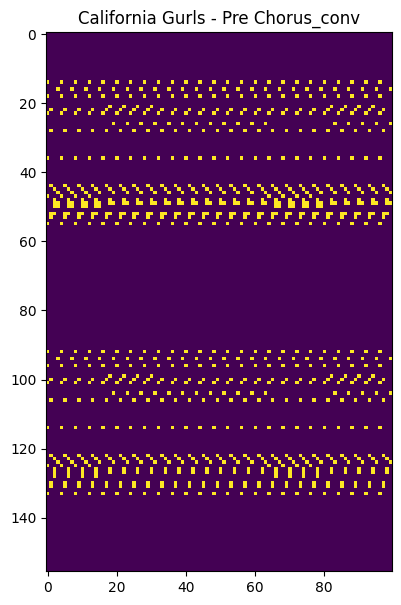

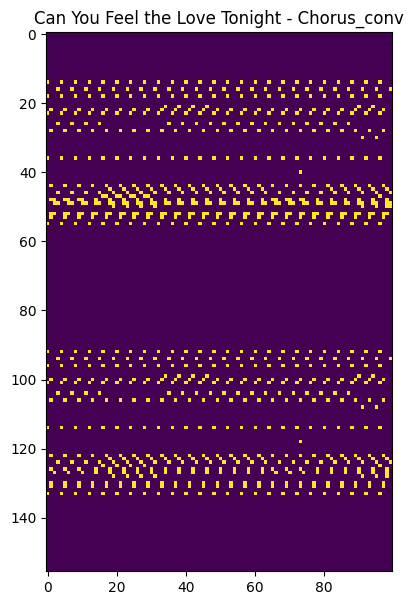

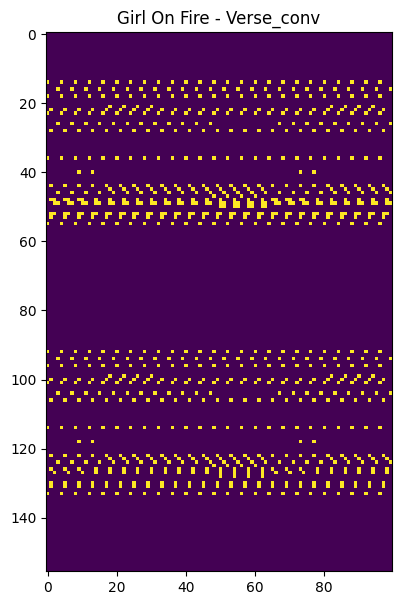

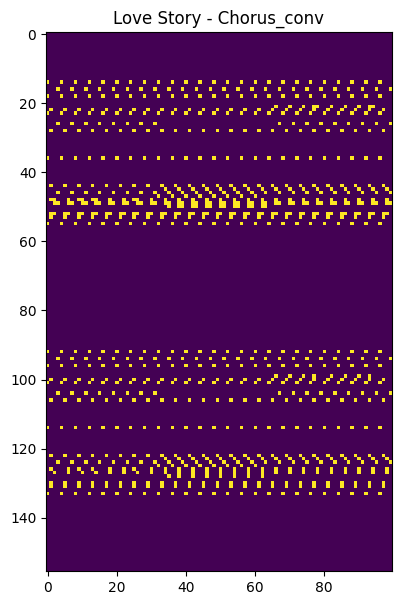

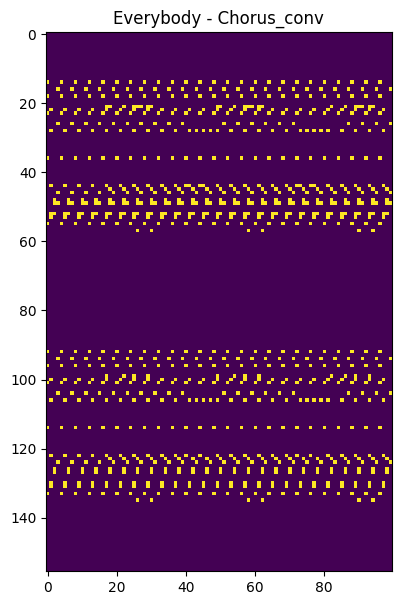

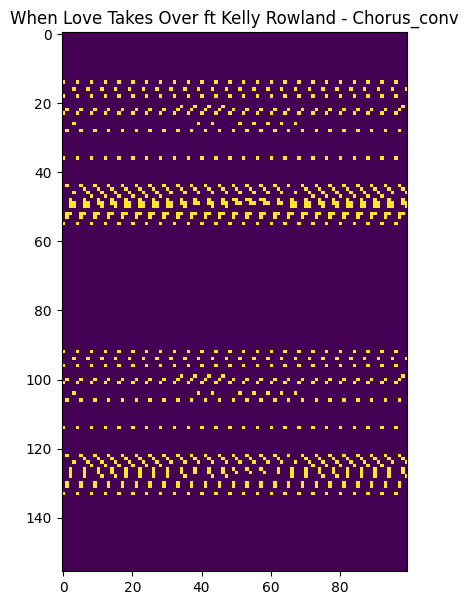

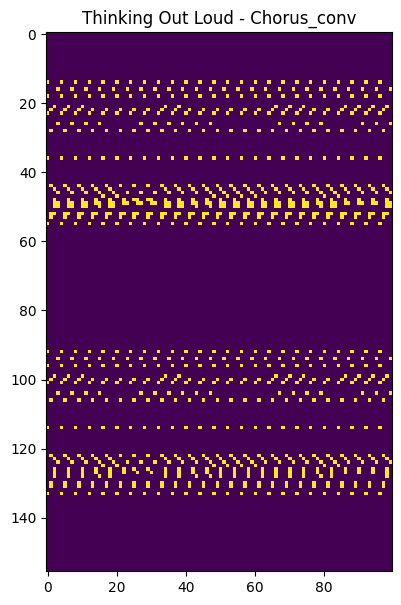

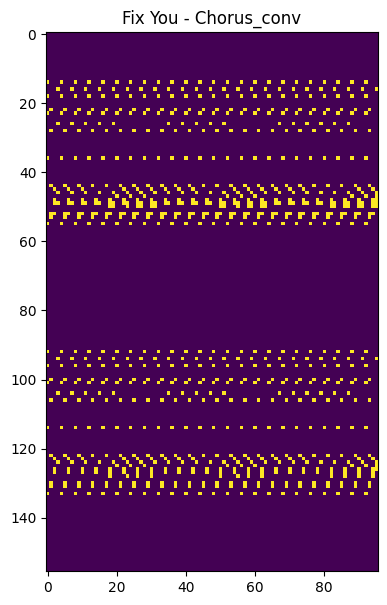

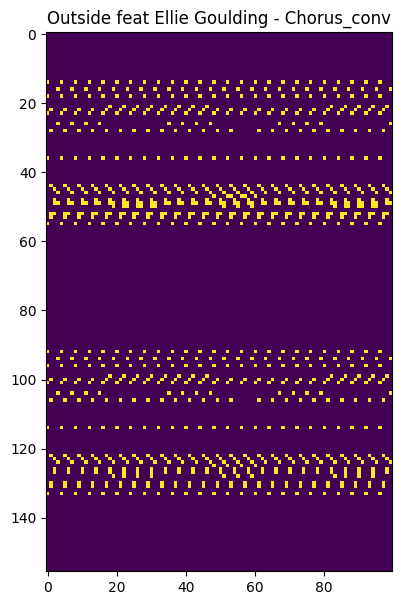

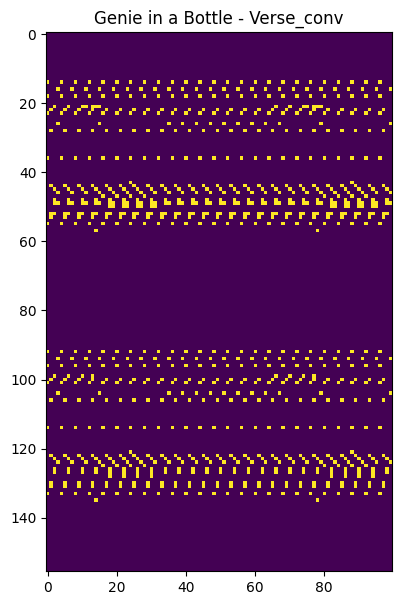

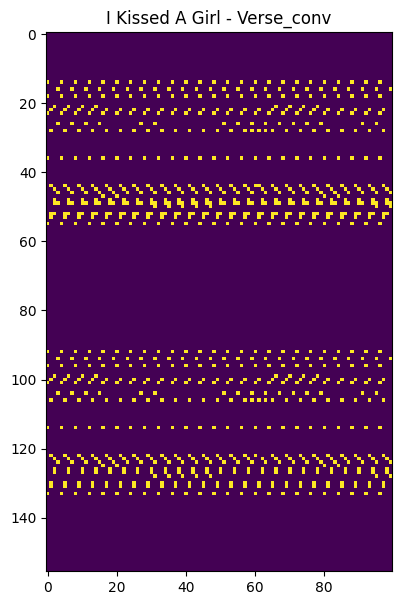

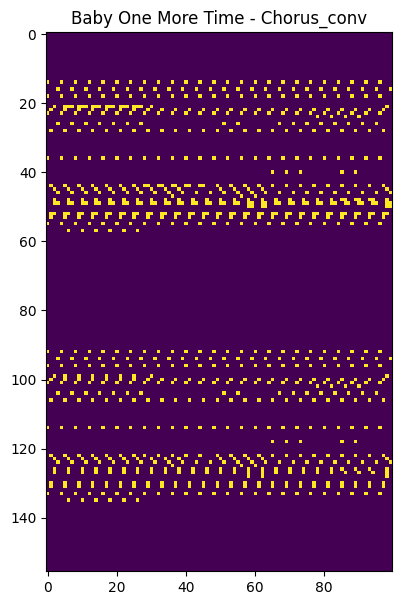

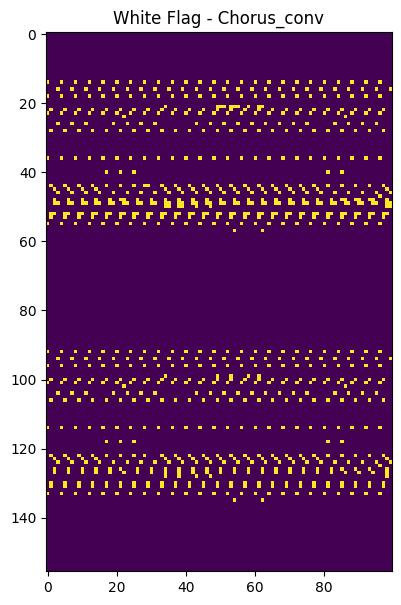

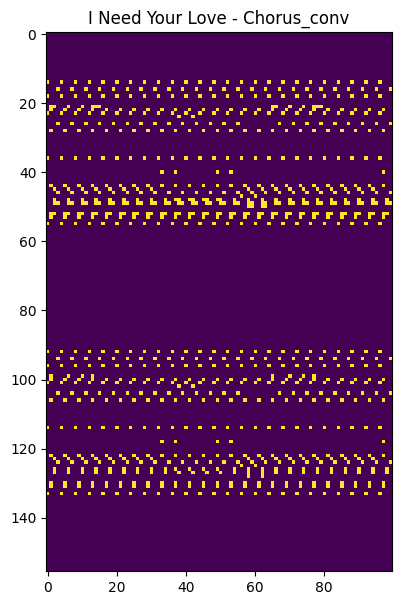

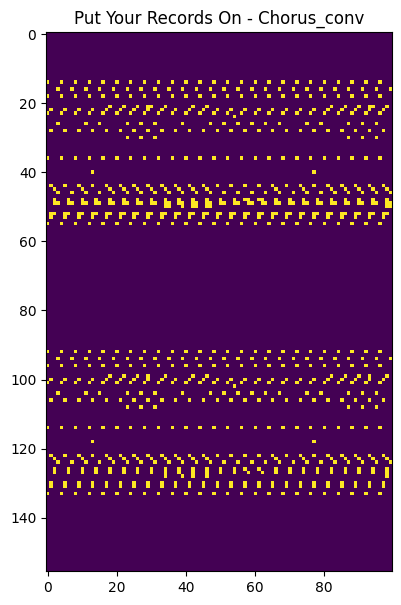

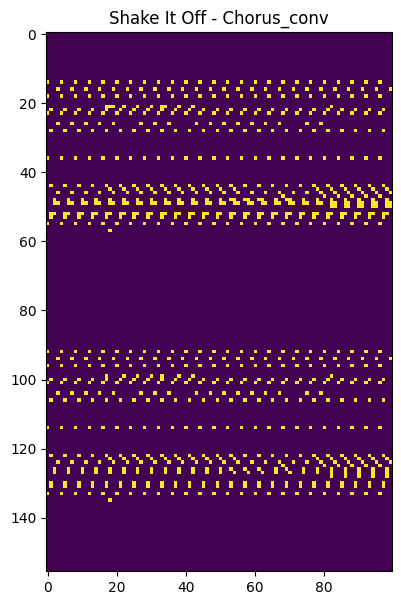

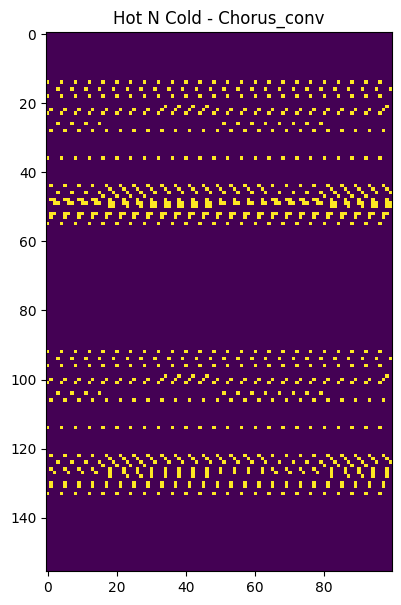

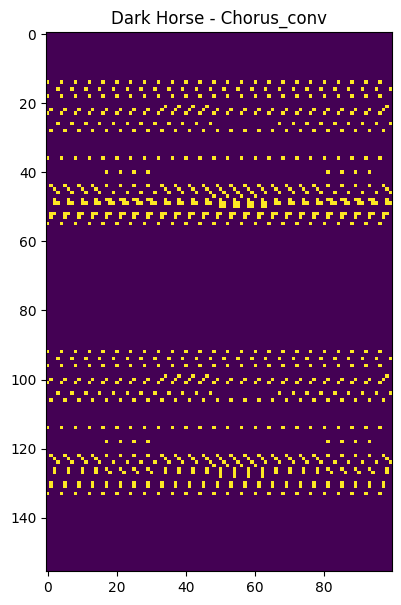

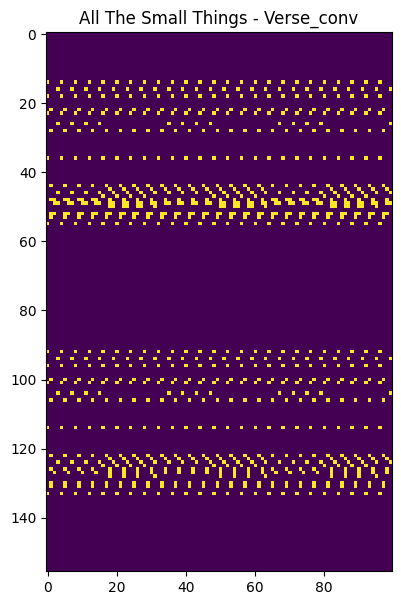

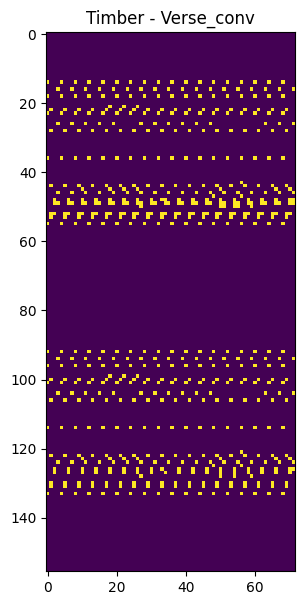

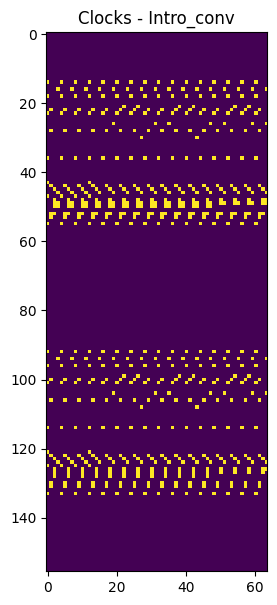

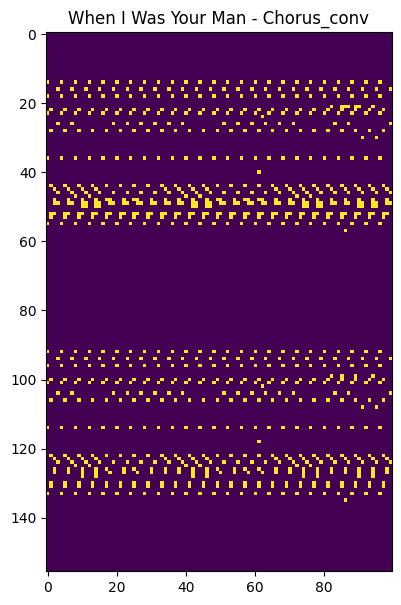

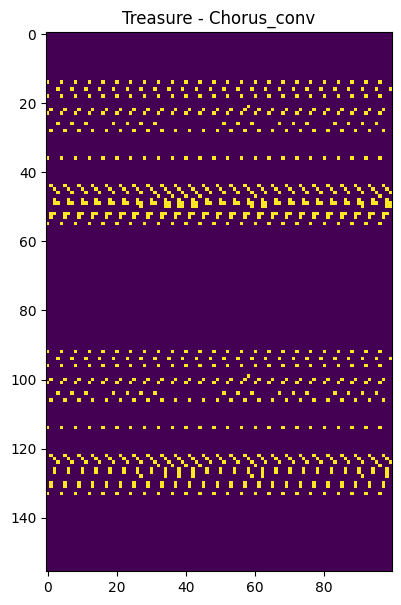

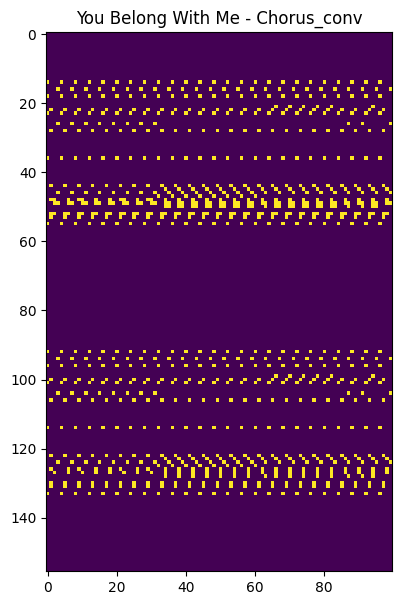

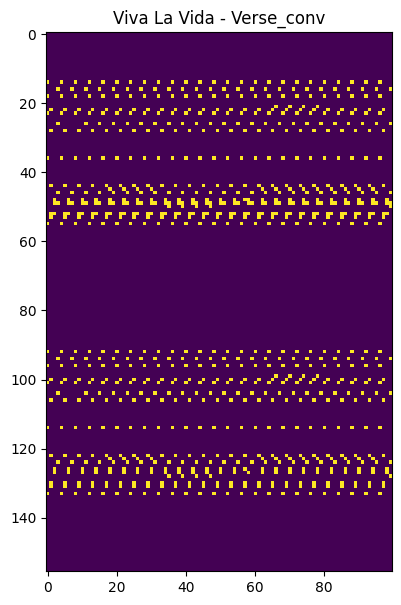

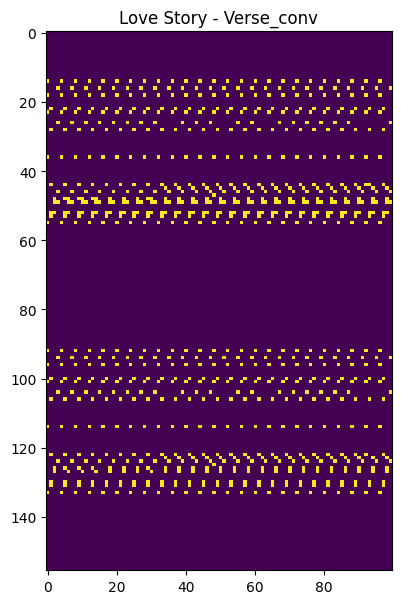

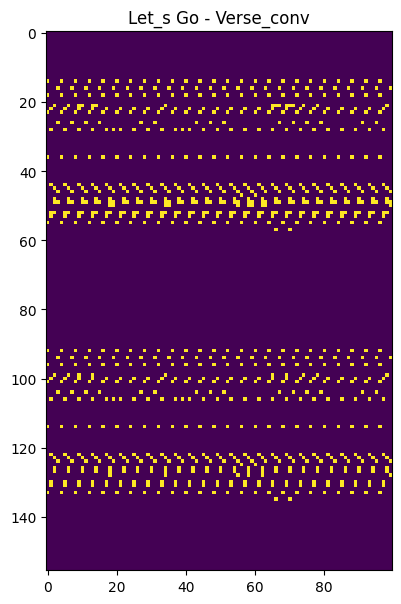

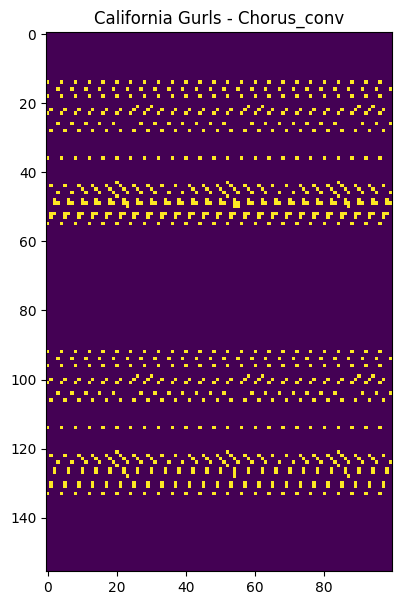

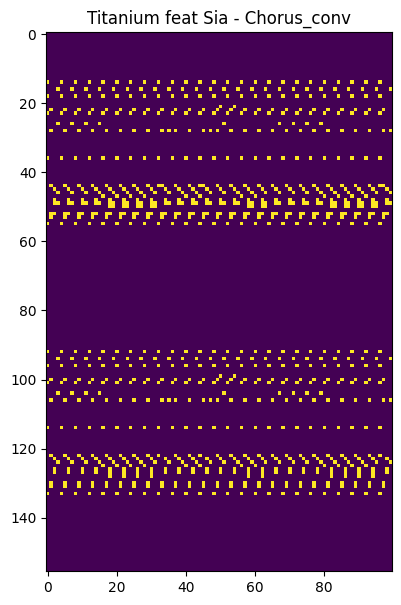

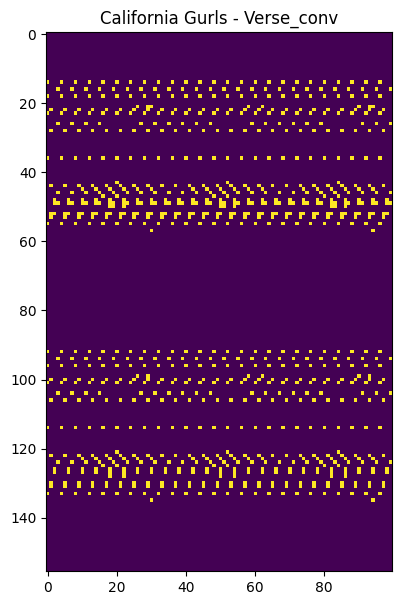

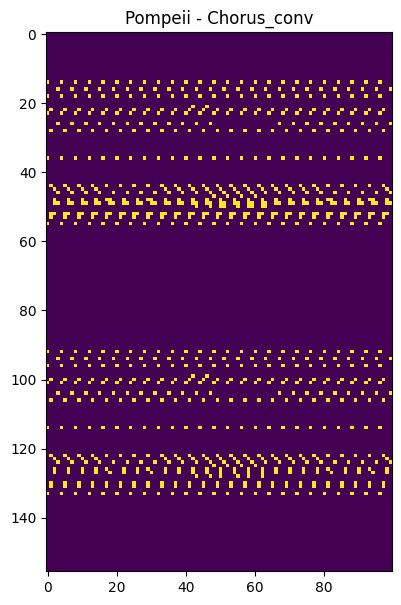

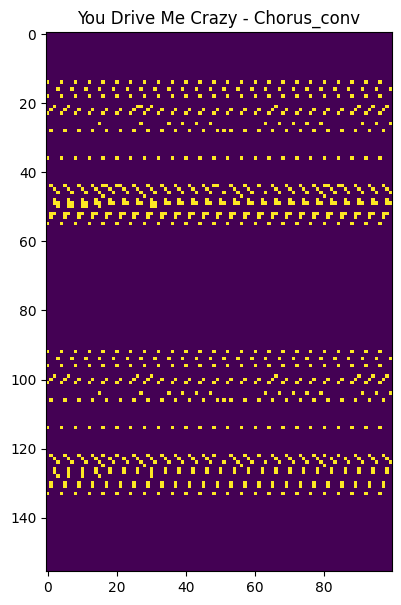

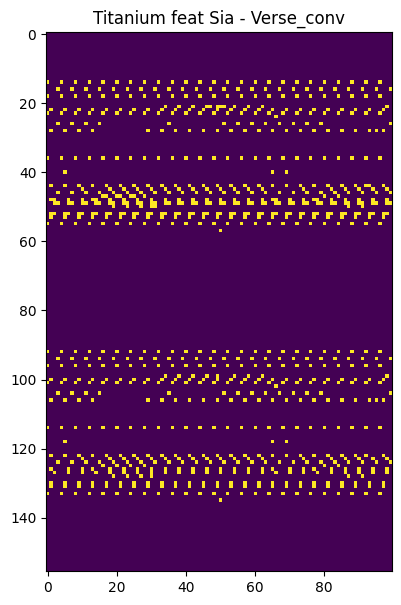

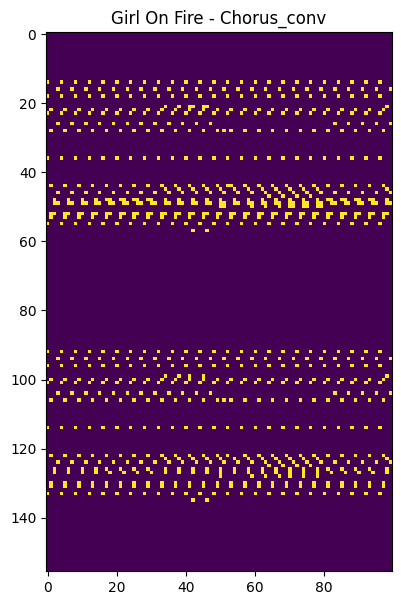

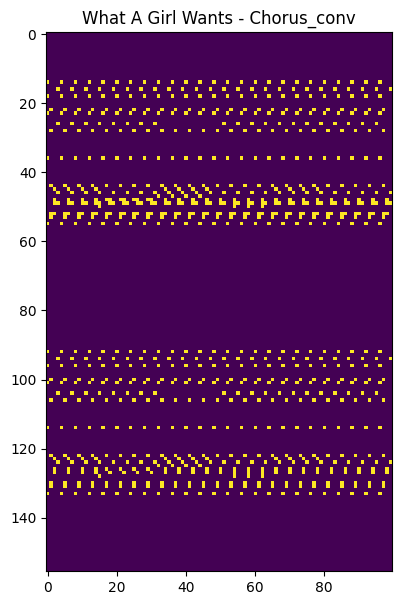

In [ ]:
plot_graphs(converted_songs, 'song')

<ipython-input-36-9f502624e022>:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (12,7))


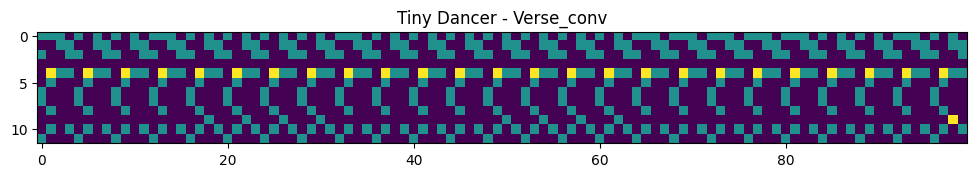

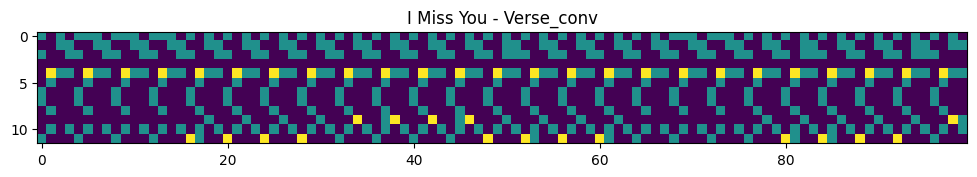

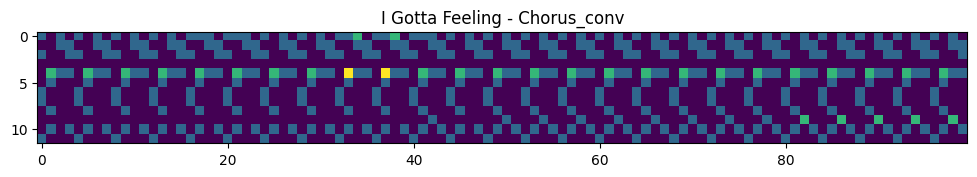

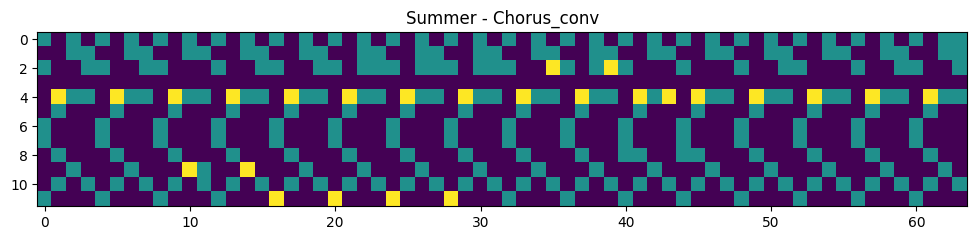

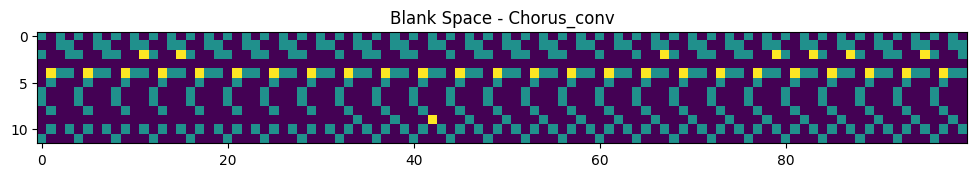

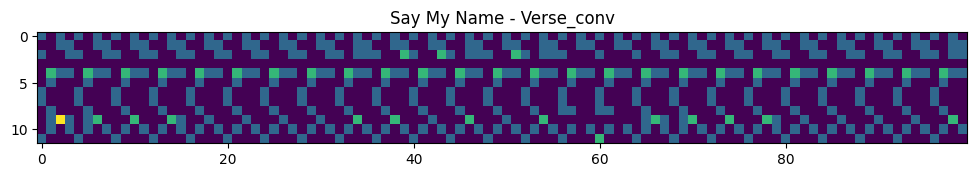

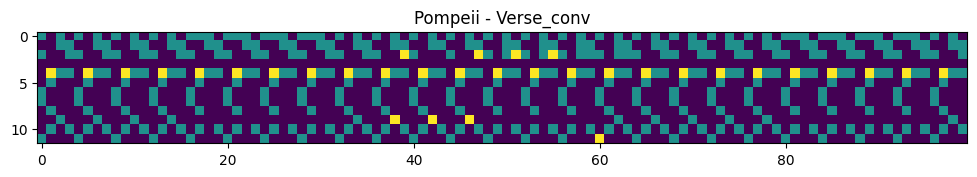

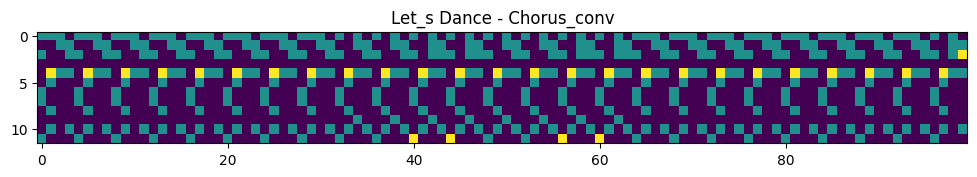

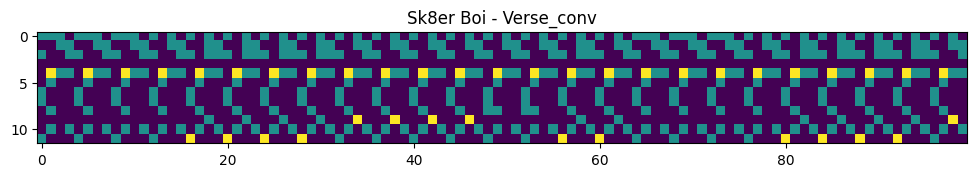

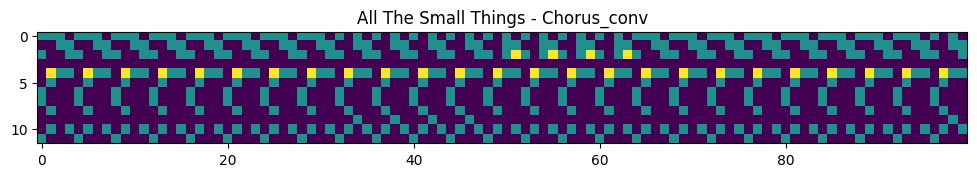

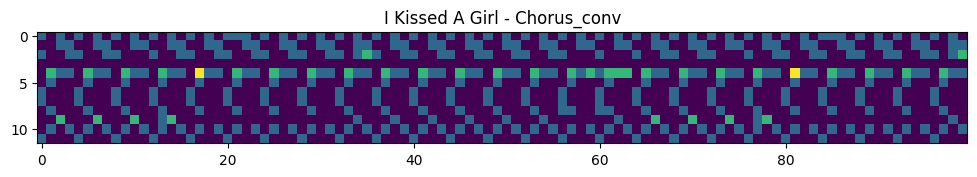

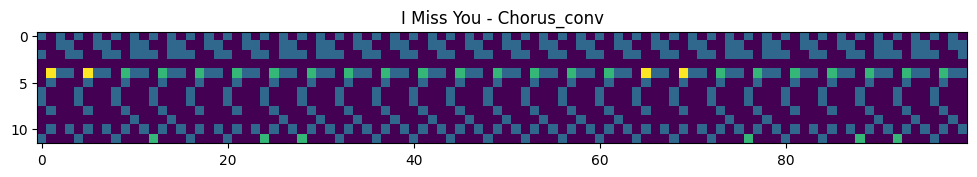

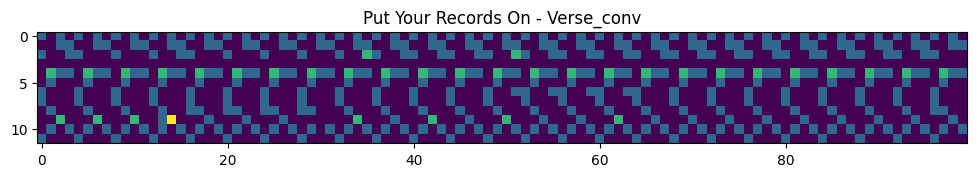

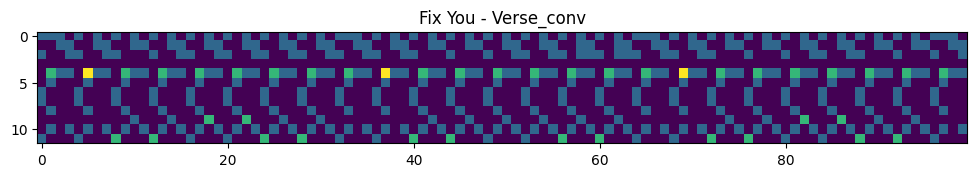

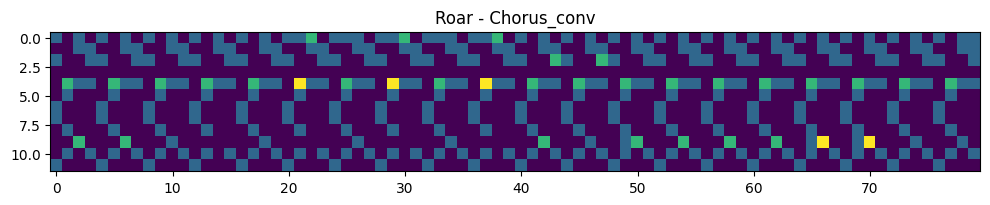

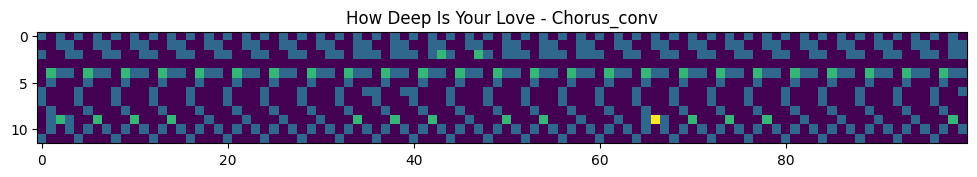

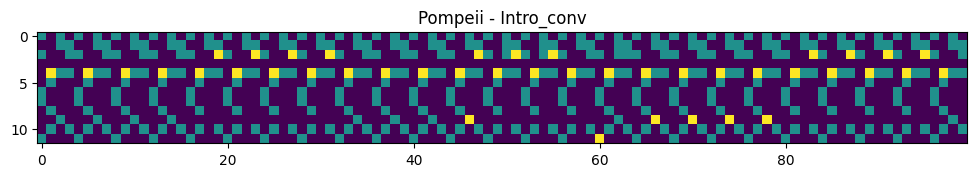

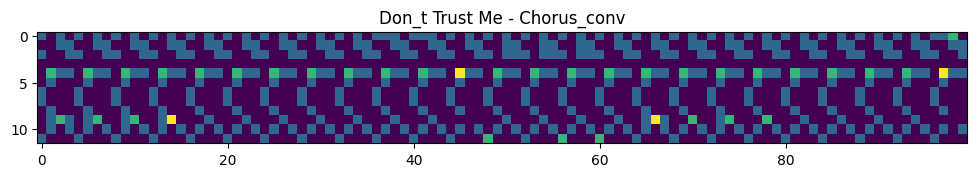

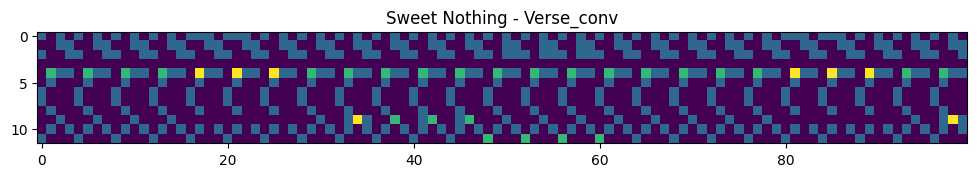

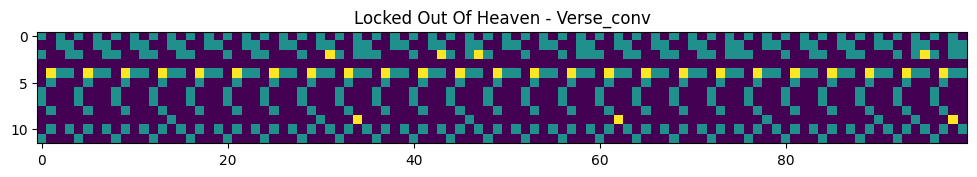

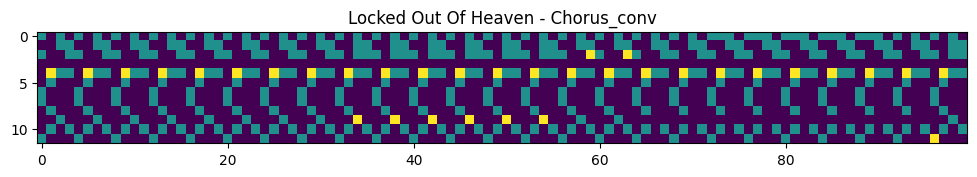

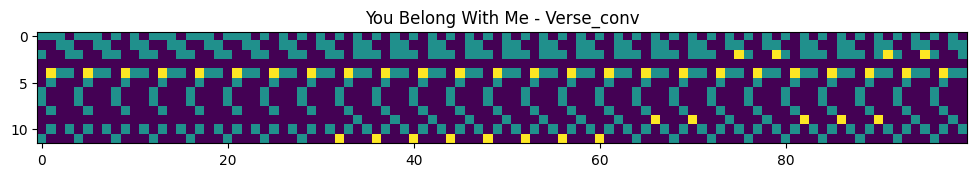

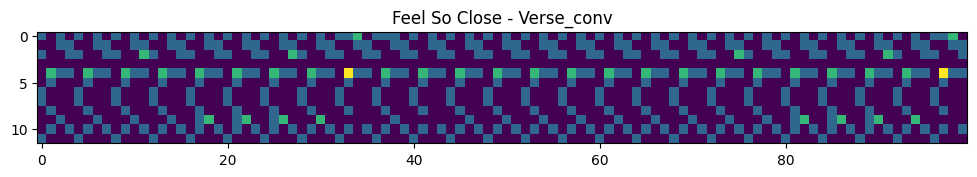

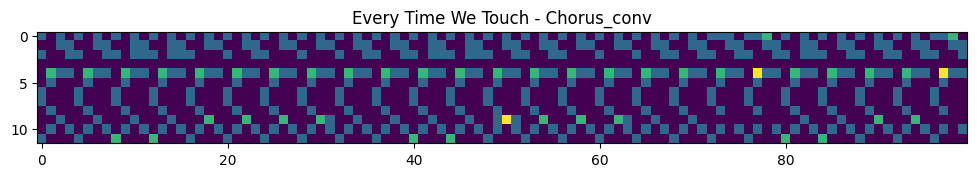

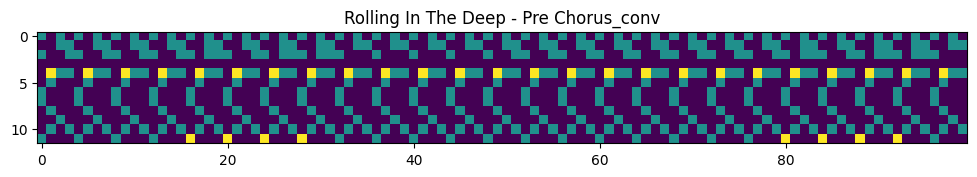

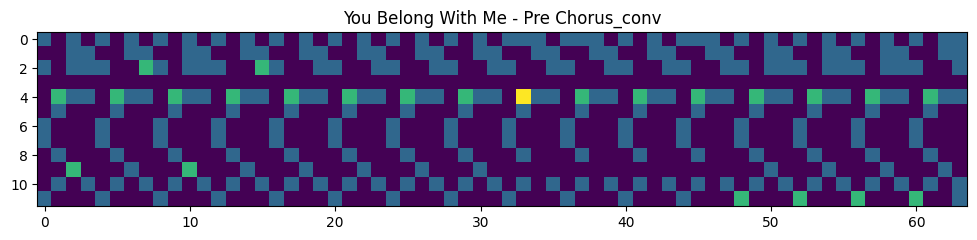

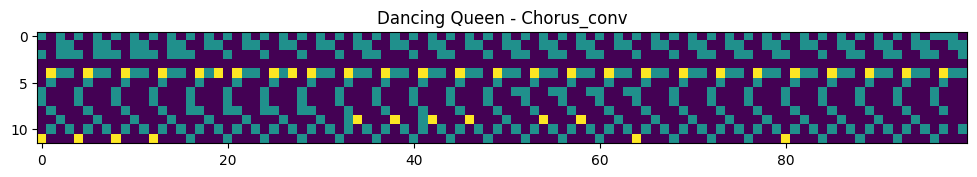

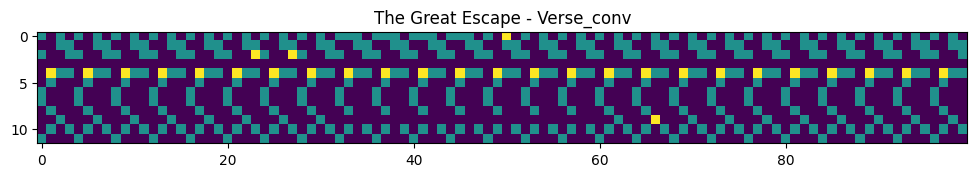

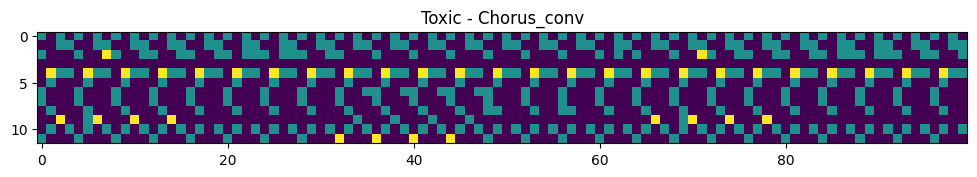

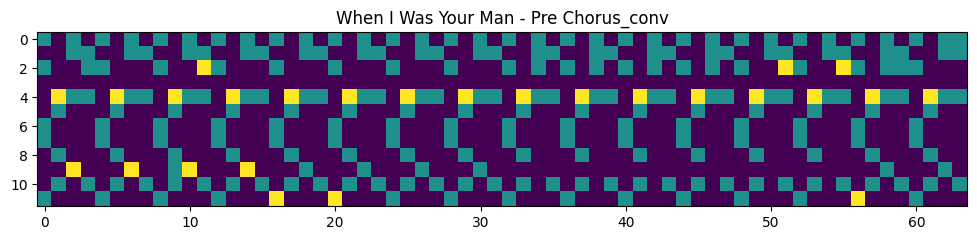

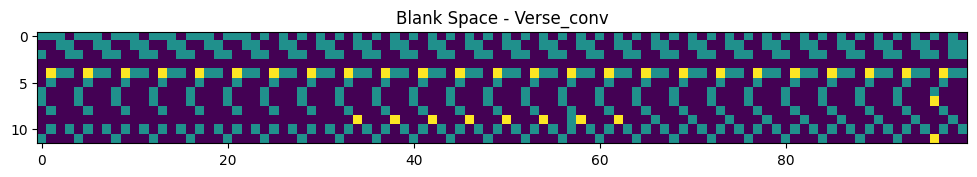

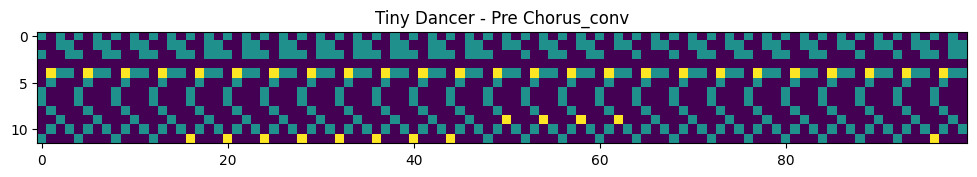

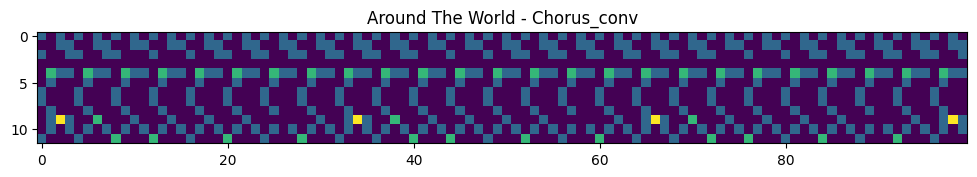

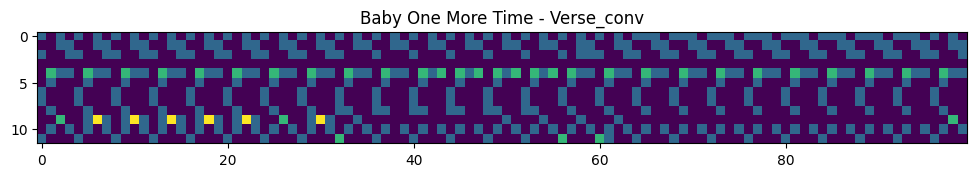

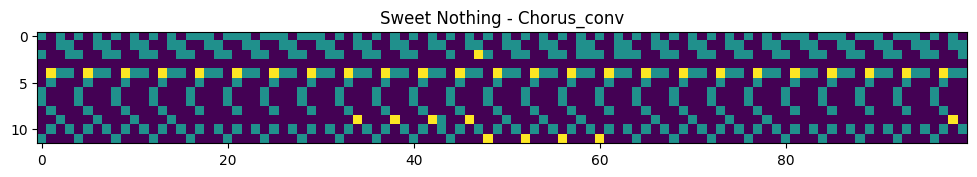

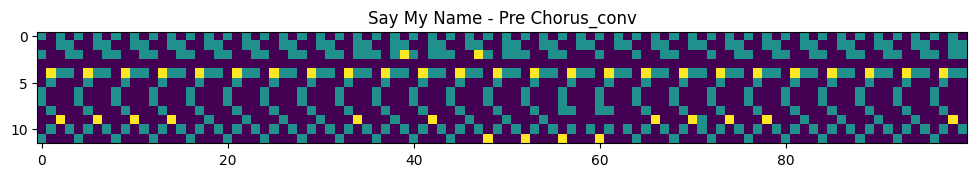

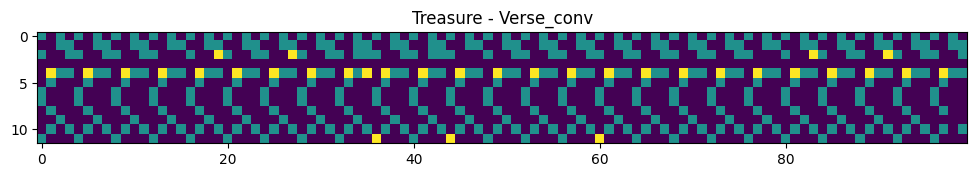

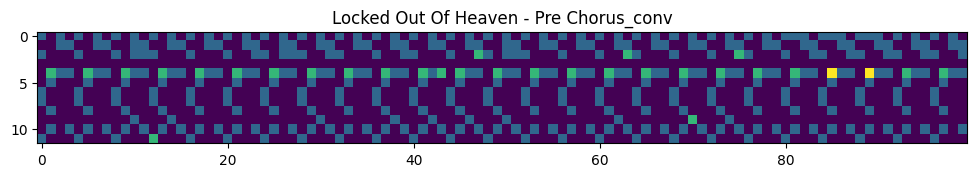

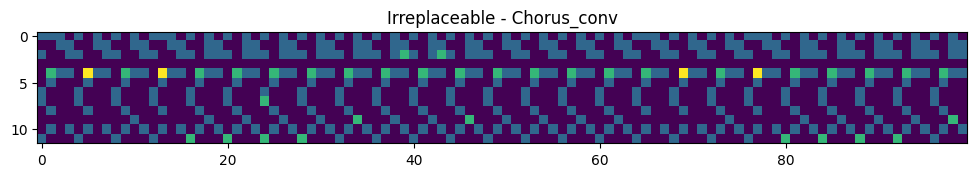

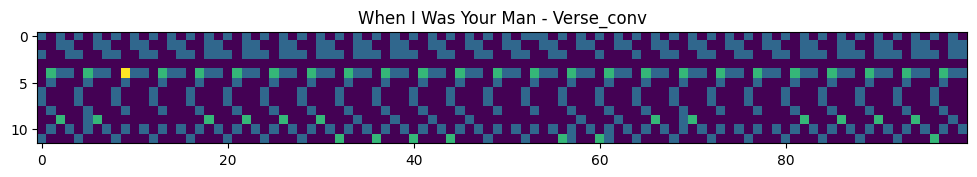

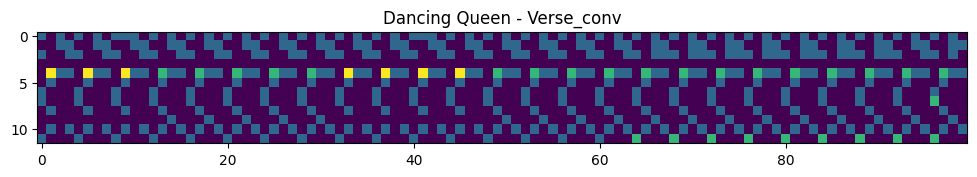

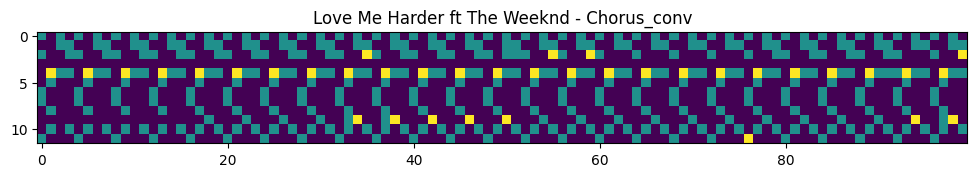

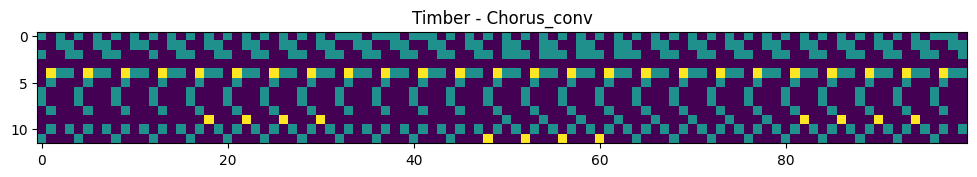

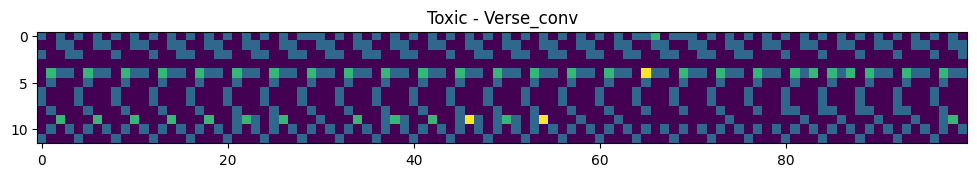

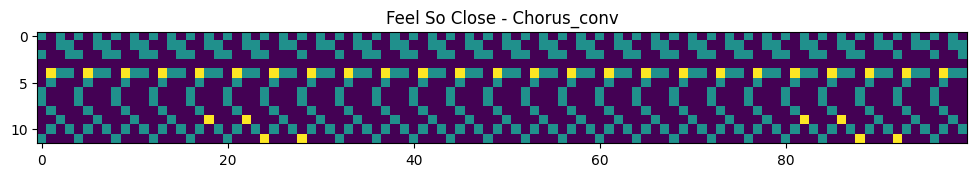

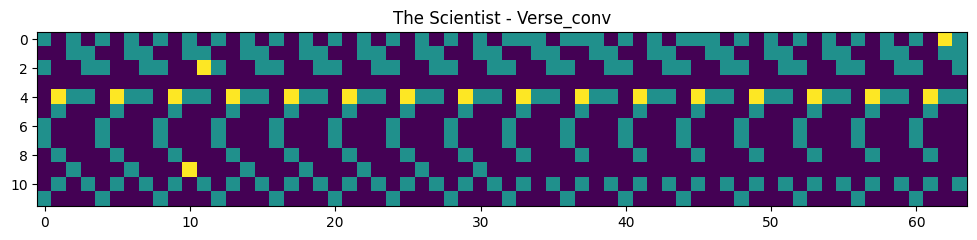

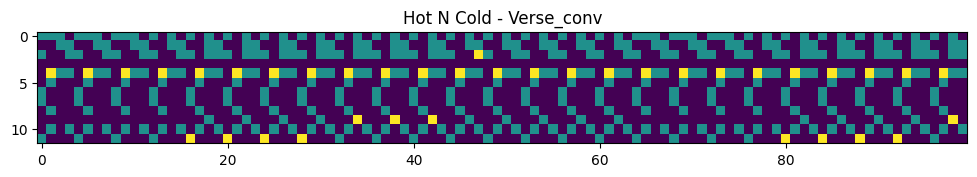

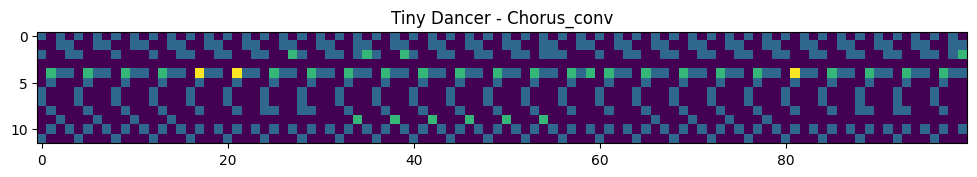

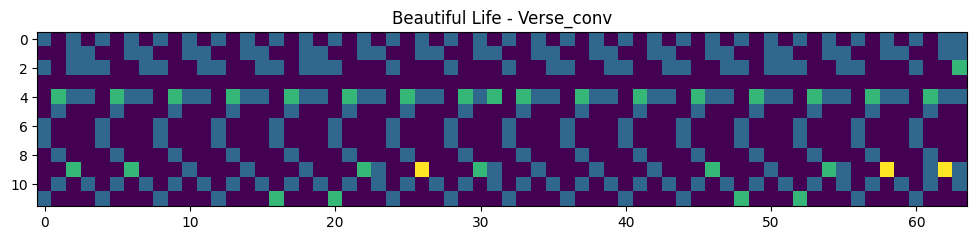

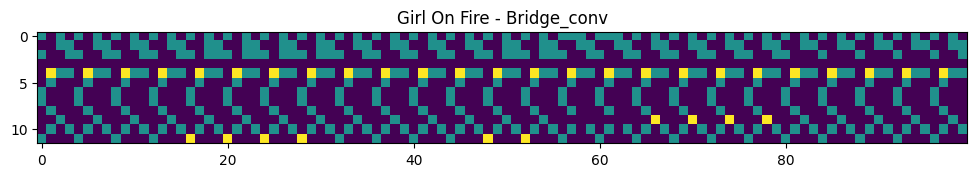

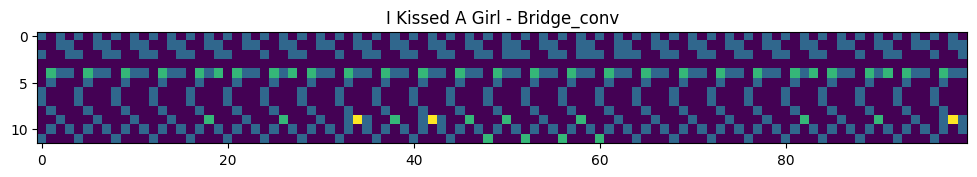

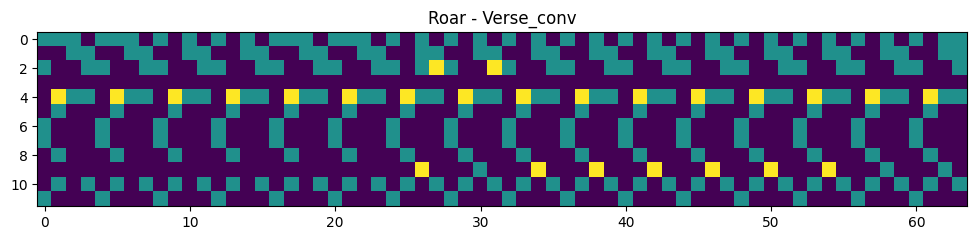

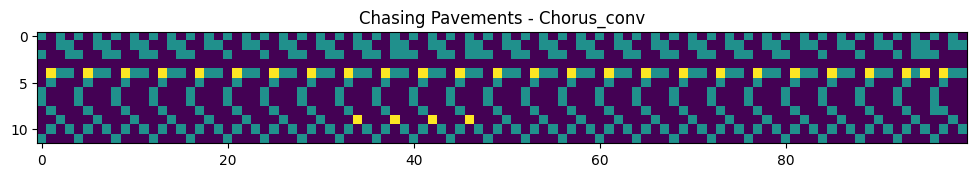

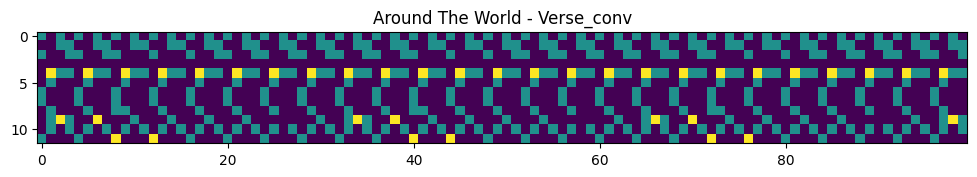

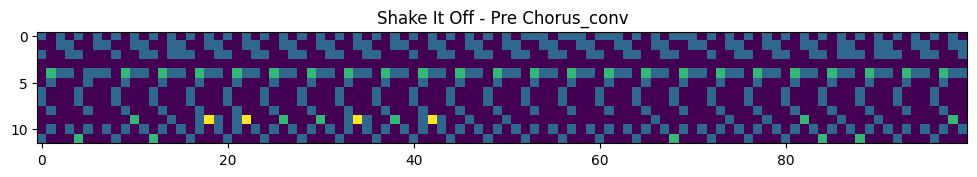

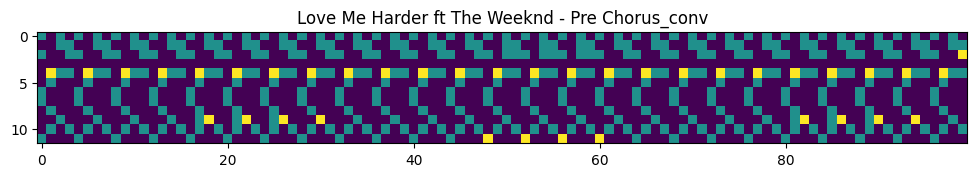

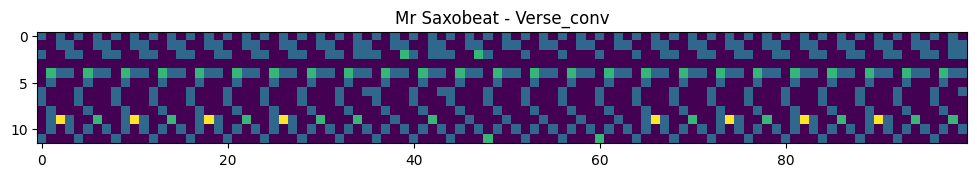

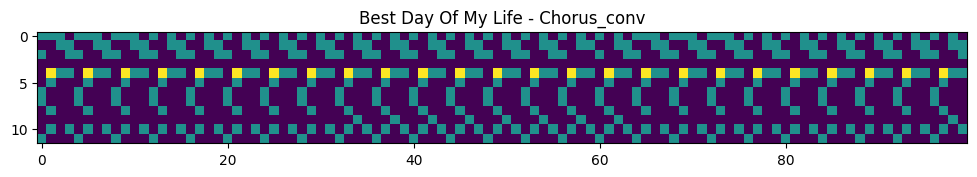

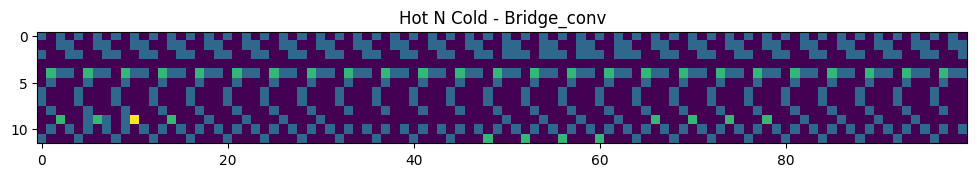

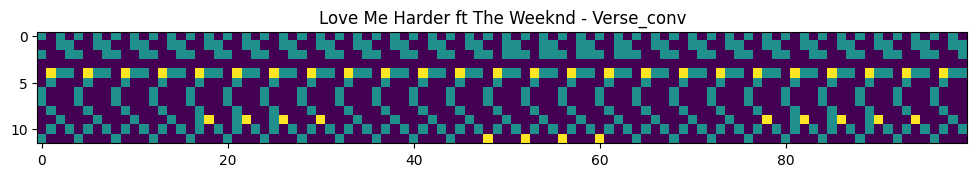

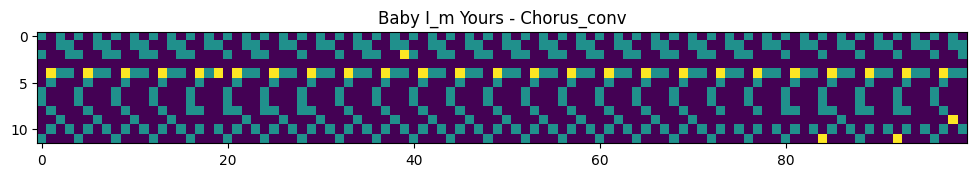

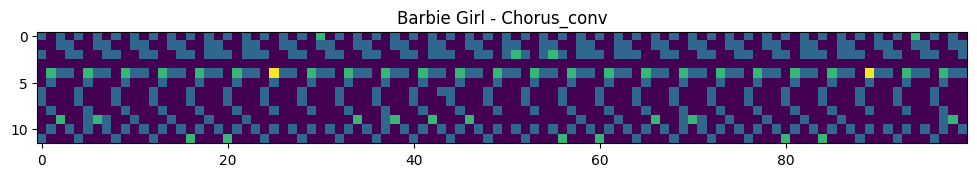

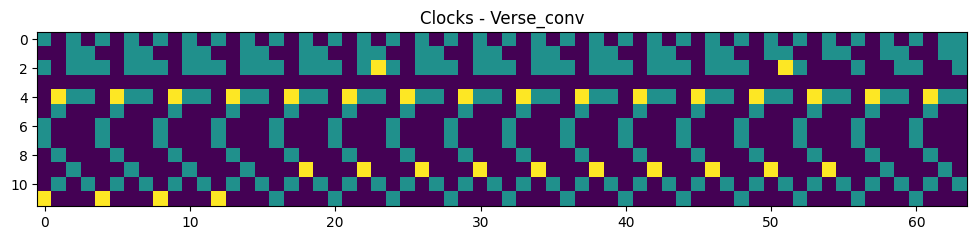

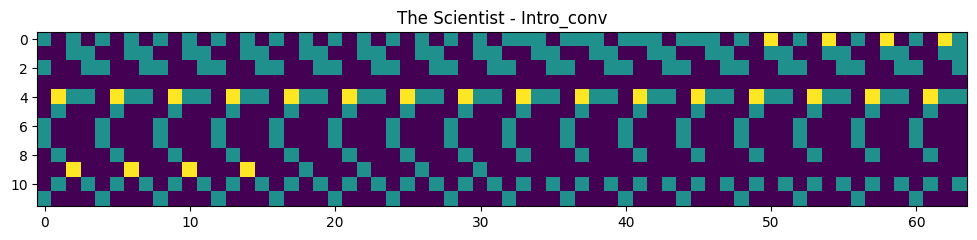

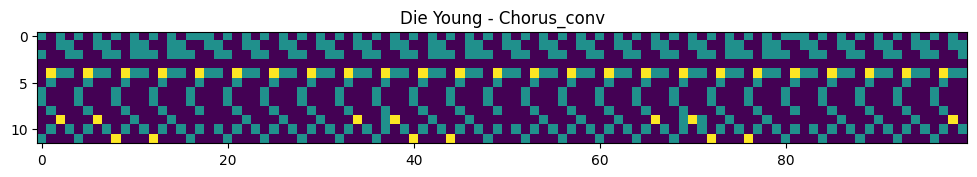

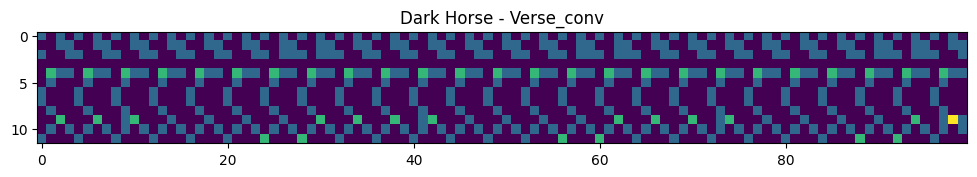

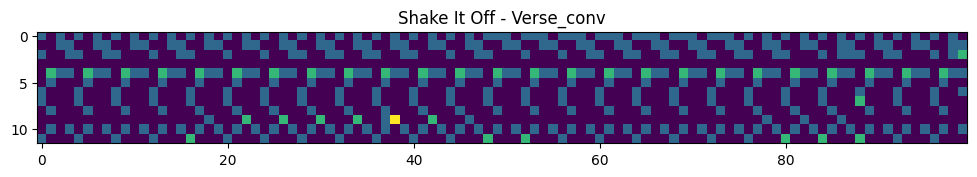

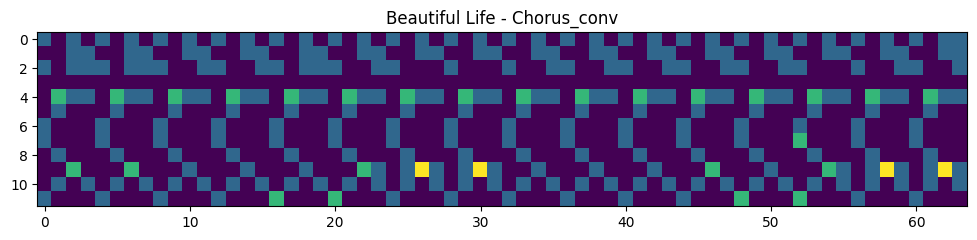

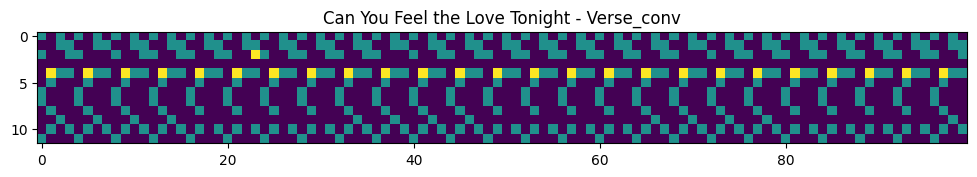

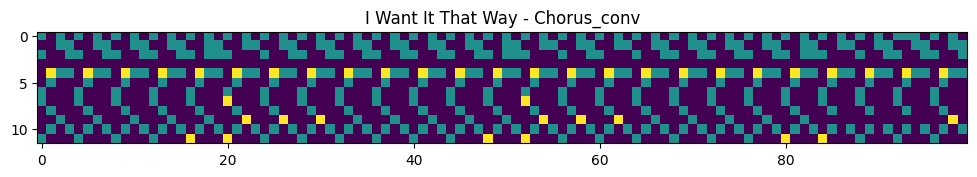

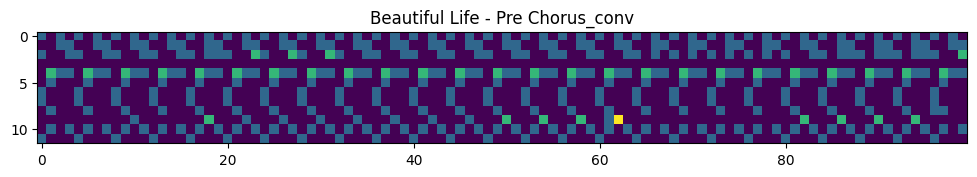

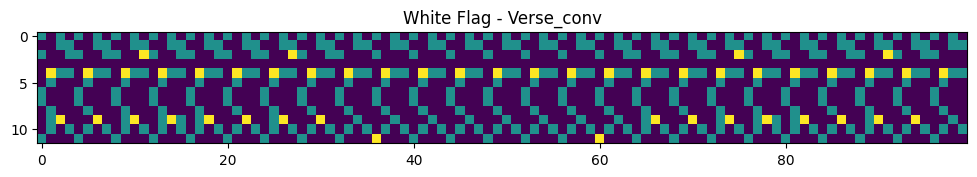

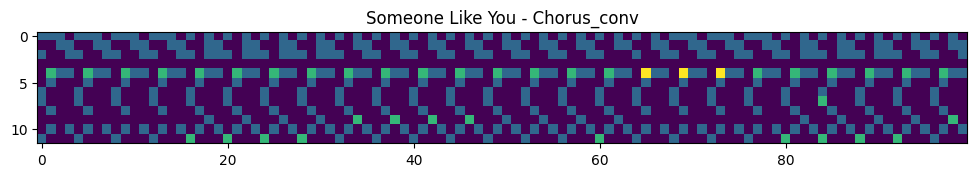

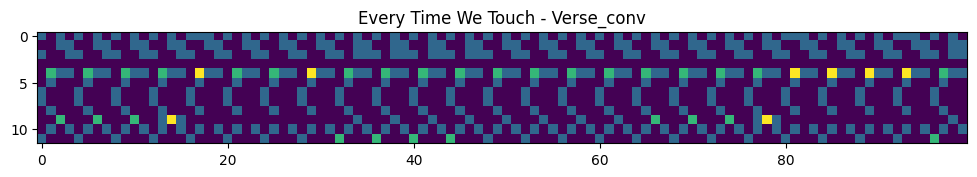

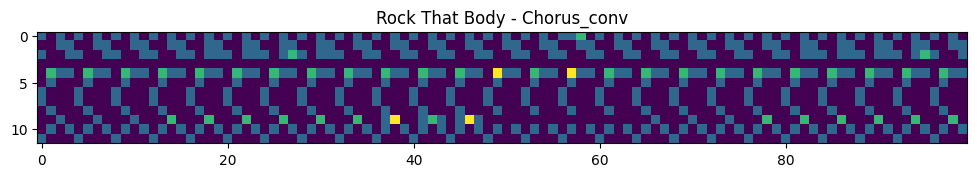

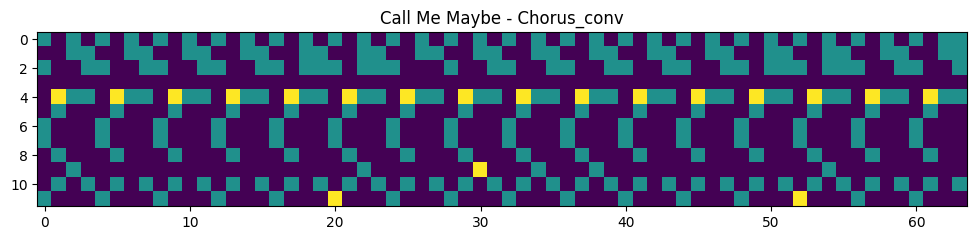

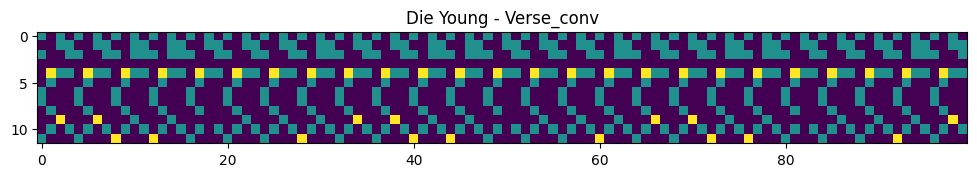

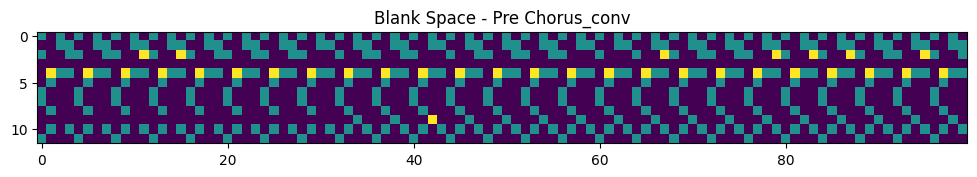

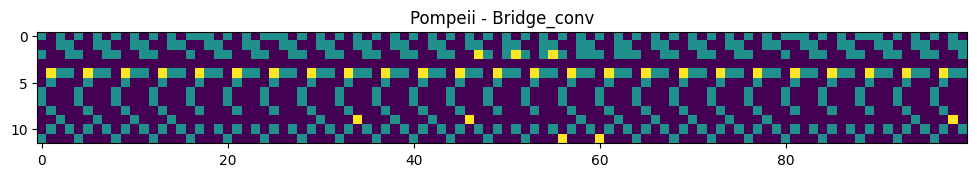

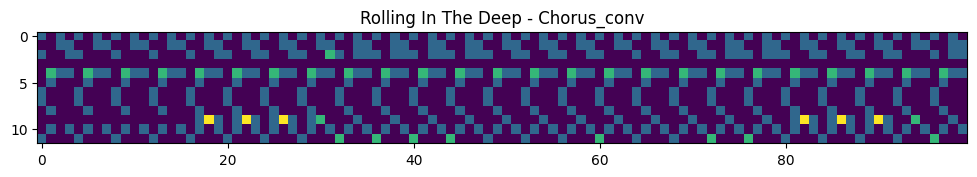

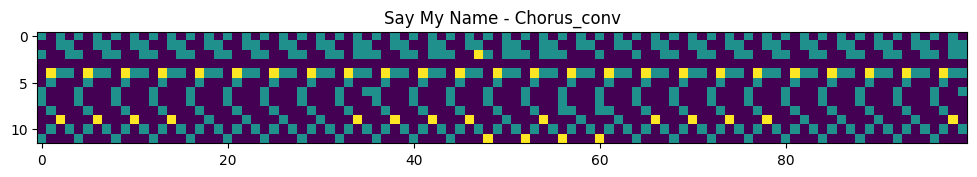

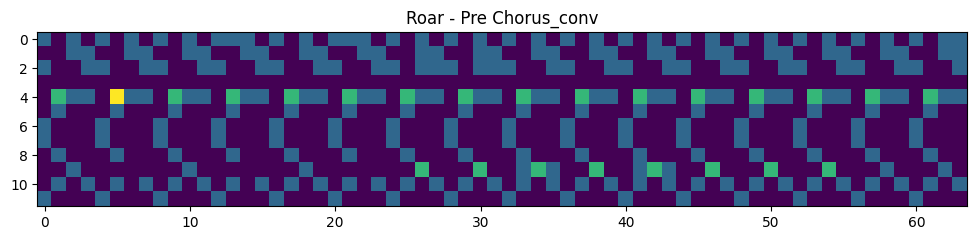

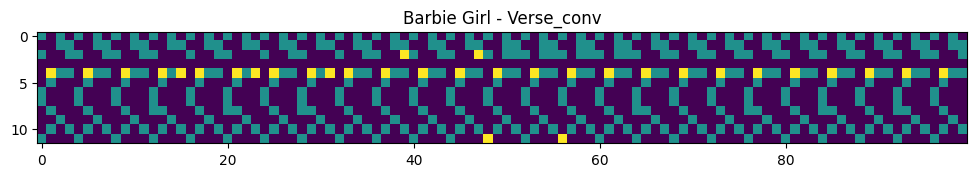

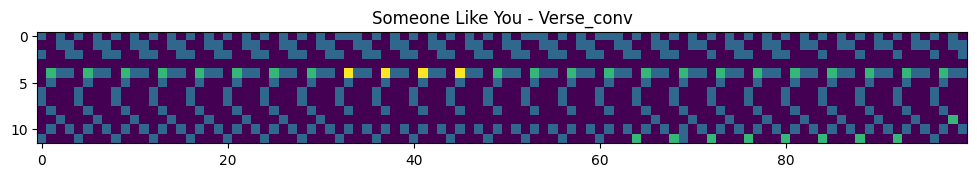

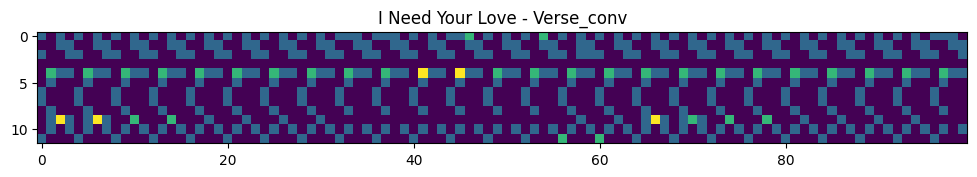

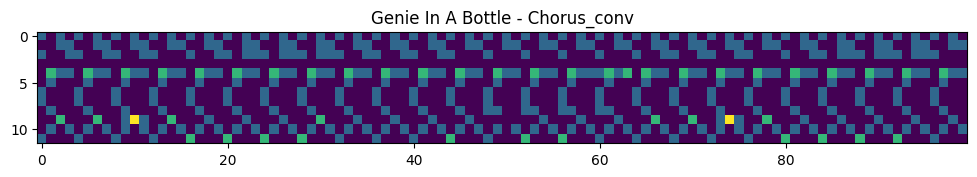

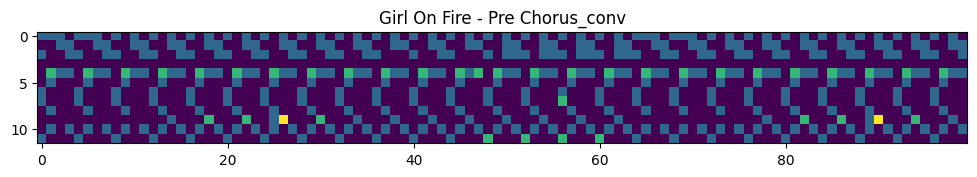

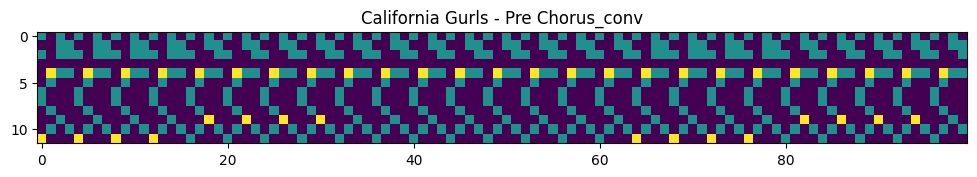

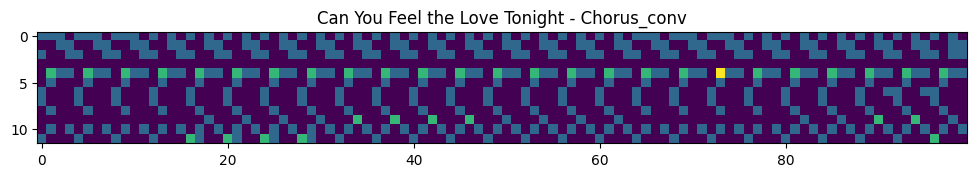

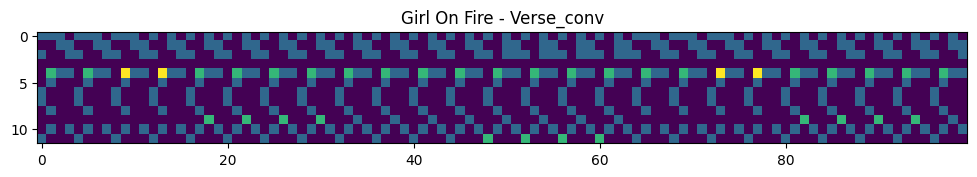

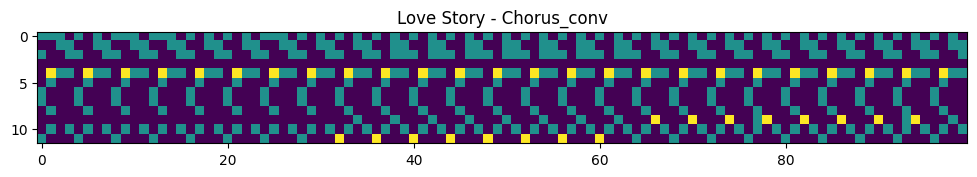

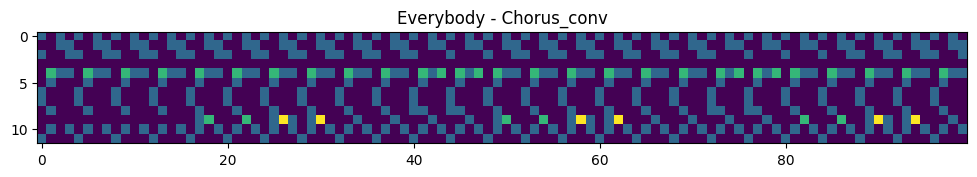

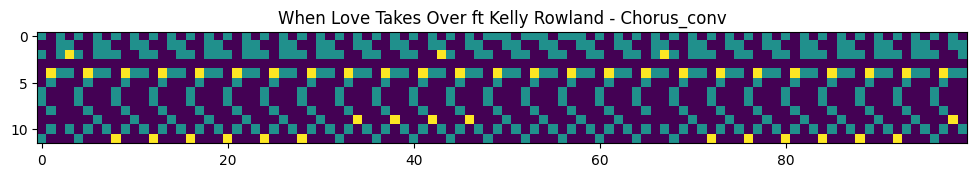

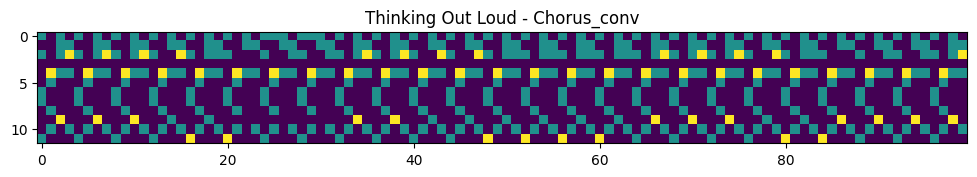

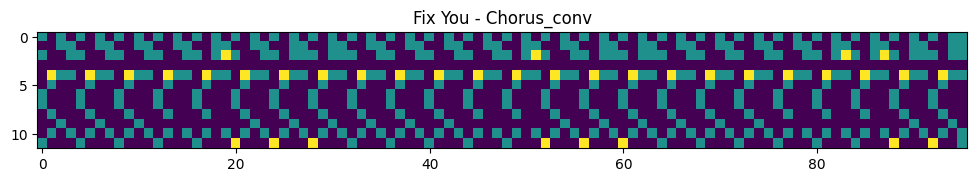

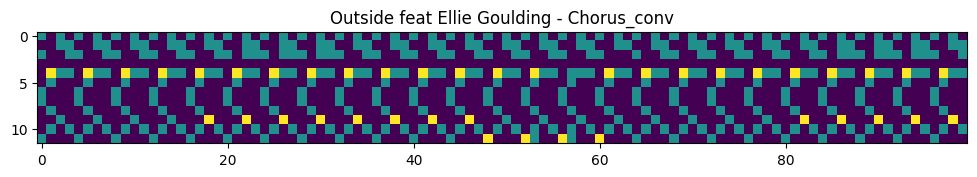

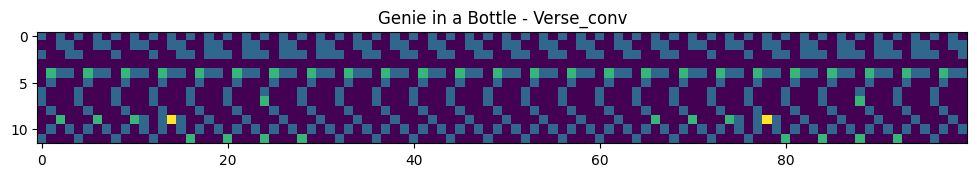

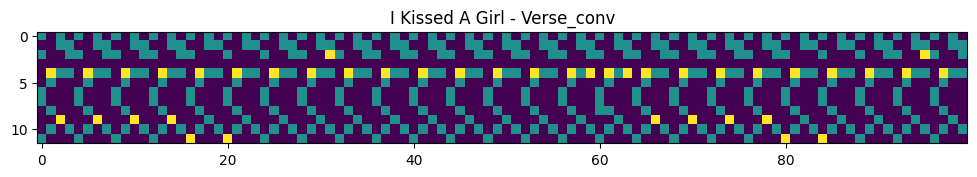

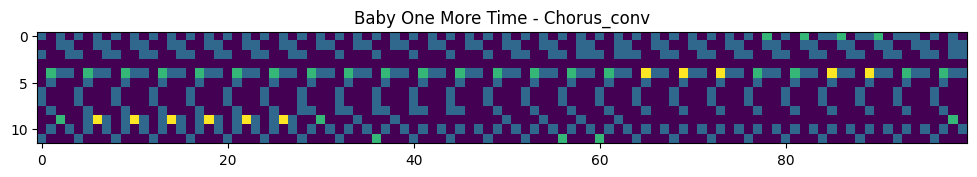

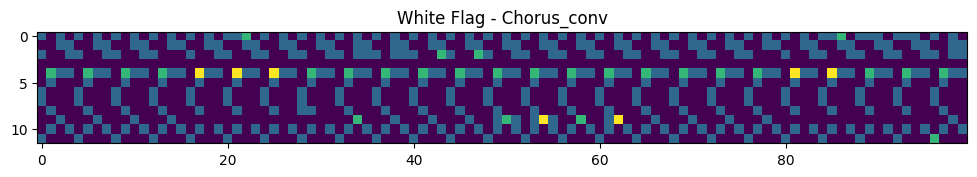

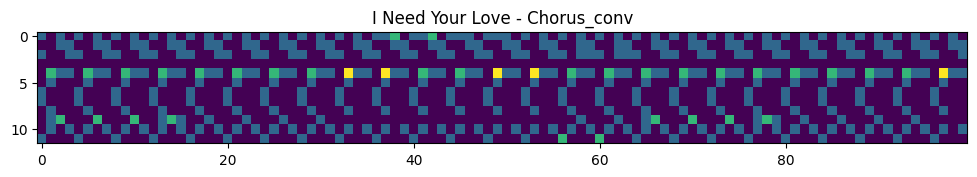

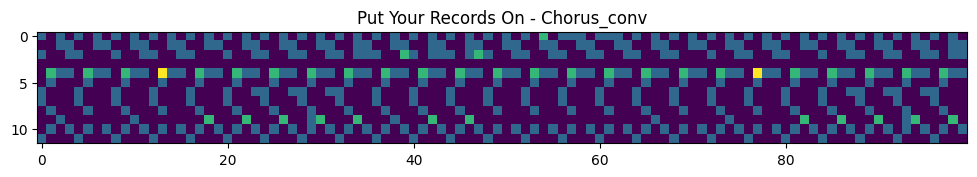

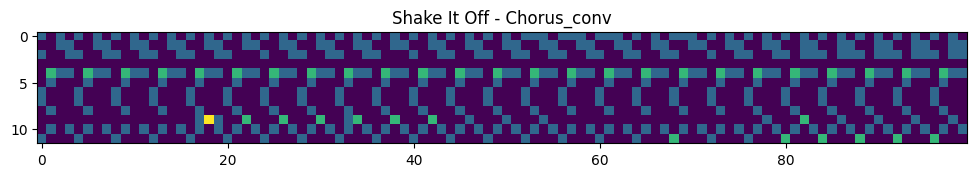

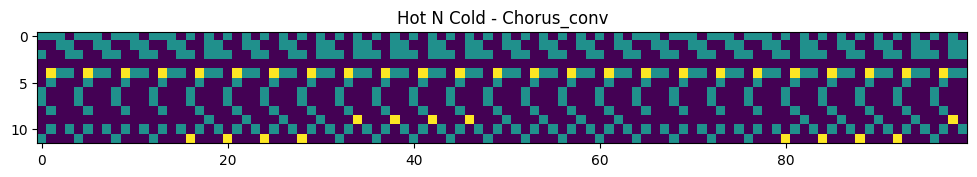

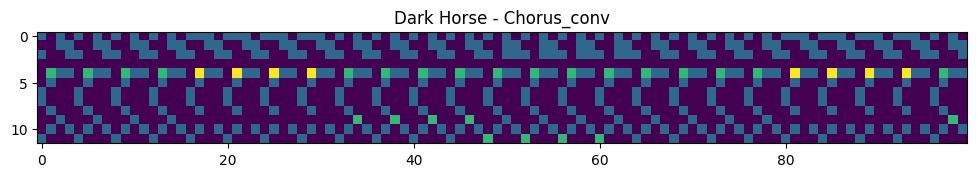

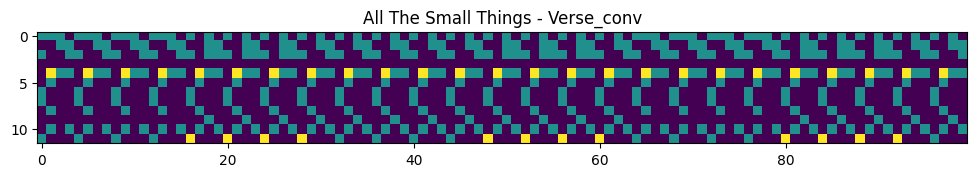

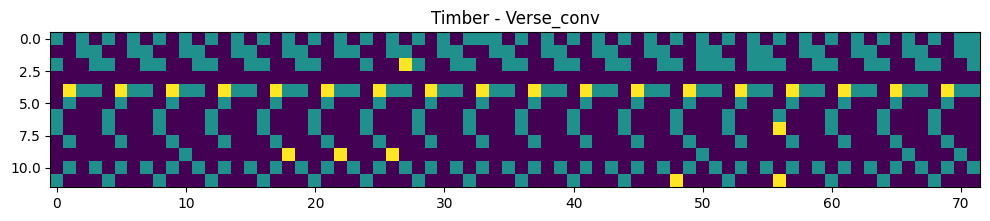

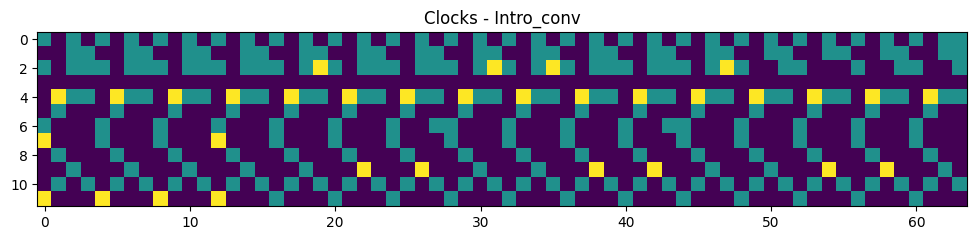

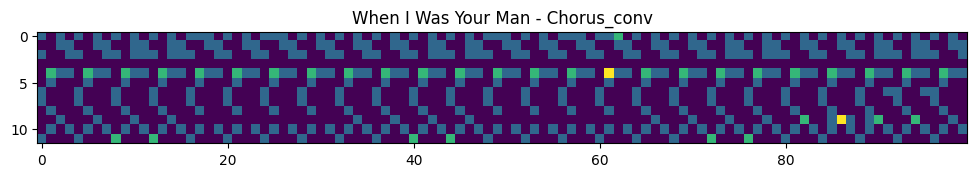

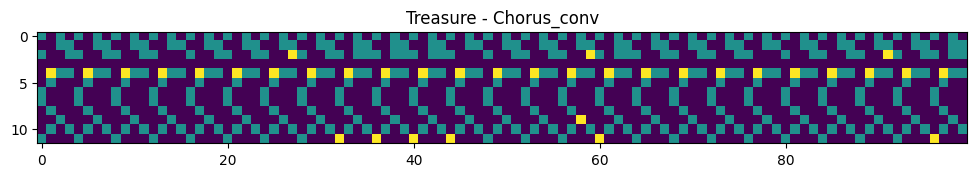

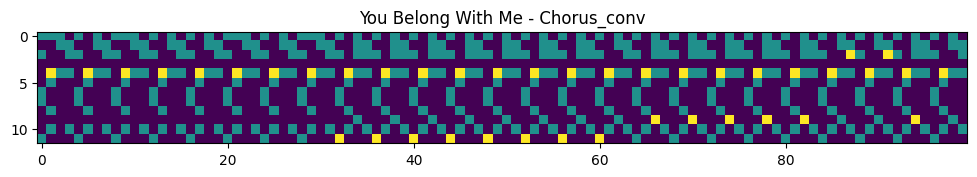

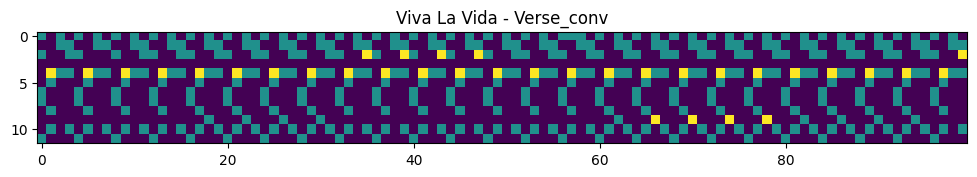

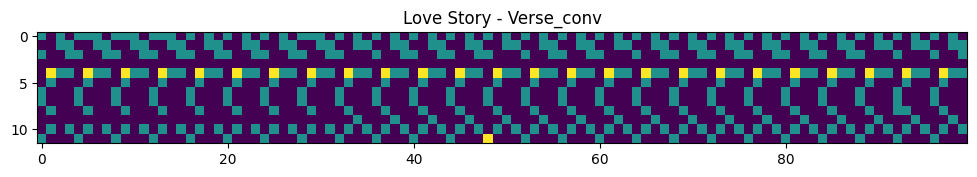

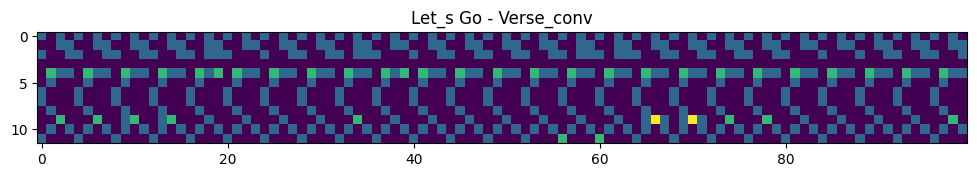

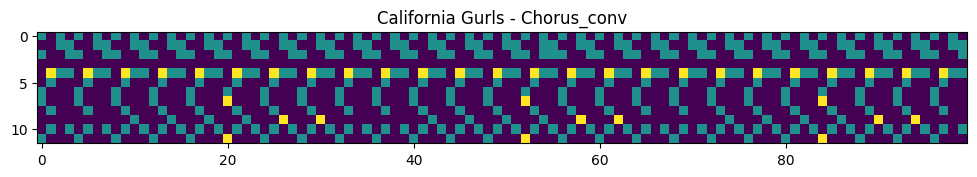

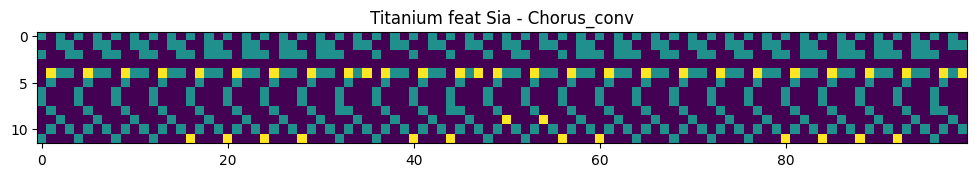

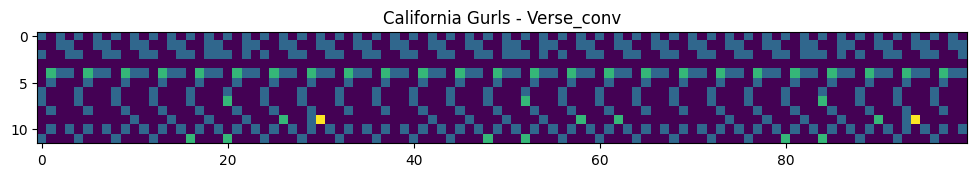

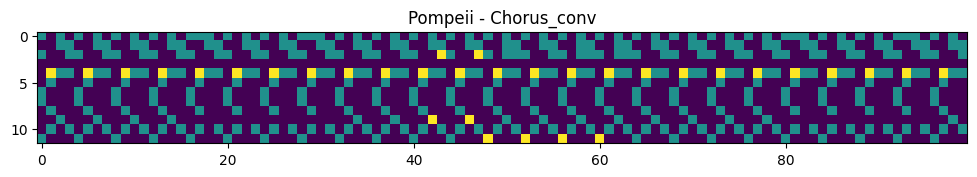

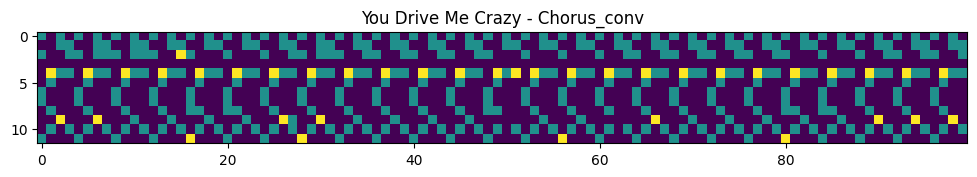

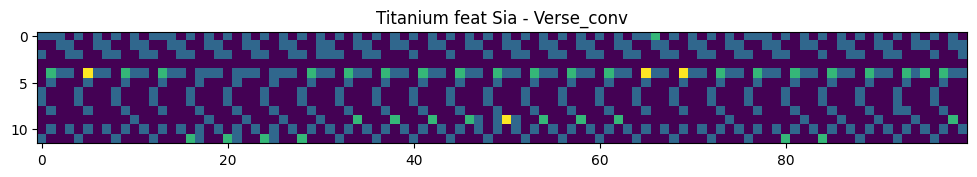

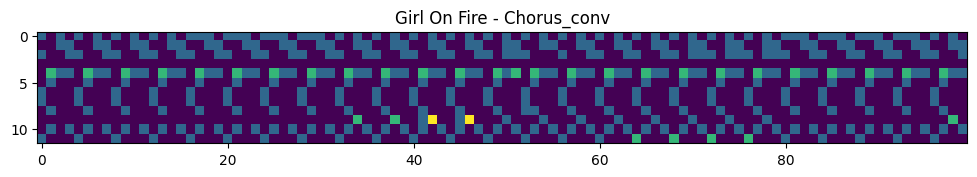

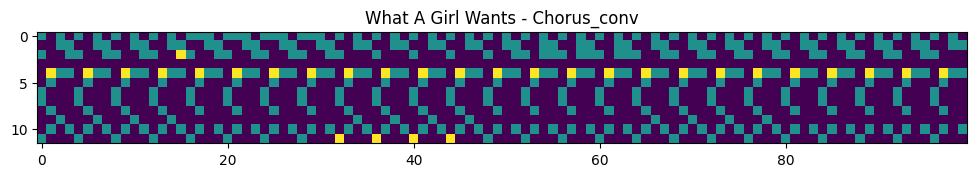

In [ ]:
plot_graphs(converted_songs, 'chroma')

 After experimenting with style transfer between classical and pop music, and analyzing the chroma and song plot visualizations, it is evident that the model struggled to perform the style transfer effectively. This challenge likely arises from suboptimal hyperparameter configurations, particularly the choice of the Lambda value. Further fine-tuning of Lambda and other hyperparameters could improve the model's performance.

## L1

In [ ]:
songs = get_songs('./Classical_Music_Midi/mozart')
songs = add_chromas(songs)
print ("{} songs processed".format(len(['song' in songs[f] for f in songs])))
print ("{} chromas processed".format(len(['chroma' in songs[f] for f in songs])))

21 songs processed
21 chromas processed


In [ ]:
sess = train_model(songs, 0.0005, "L1")
sess = train_model(songs, 8000, "L1")

In [ ]:
songs = get_songs('L1')
songs = add_chromas(songs)
plot_graphs(songs, 'song')

In [ ]:
plot_graphs(songs, 'chroma')

### Answer:

While exploring the impact of L1 distance and varying Lambda values in the GAN model, we noticed the following patterns:

1. Lambda = 8000: The generated pieces retained the harmonic progressions of the inputs, but the rhythm and note durations differed. This occurred because a higher Lambda emphasized capturing low-frequency details, such as pitch classes, over other aspects.

2. Lambda = 0.0005: The generated pieces ignored the harmonic progressions of the inputs. This was due to the model being trained with a lower weight for the L1 loss, reducing the penalty for generating outputs that deviated from the original inputs. As a result, the generated pieces had a less coherent musical texture.

Pieces generated with Lambda=8000 showed a closer resemblance to the original Bach compositions in terms of musical texture, as reflected in the chroma graphs. Conversely, those generated with Lambda=0.0005 displayed significant deviations from the originals.

##### Question 9 [20 points]

Please record a 2-5 minute video of yourself explaining questions 1 to 7.

If you are shy (or have a bad hairday) you can use filters to augment or cover your face. Please submit it as a public google drive url.

https://drive.google.com/file/d/1sqZgGIkkIJWKkax5tNLn6d2KRBwIsV2d/view?usp=sharing